# Master ML Pipeline — DBP Forecasting
### Unified & Modular Notebook (v6 Ensemble + TFT v5)

| Pipeline | Models | Framework |
|---|---|---|
| **A - Ensemble Walk-Forward** | GRU · LSTM · GBRT | TensorFlow / Keras |
| **B - TFT v5** | Temporal Fusion Transformer | PyTorch Forecasting |
| **C - Regressão Linear e SVR** |  |  |


**How to use:**
1. Edit the **Global Configuration** cell below.
2. Choose `SCALER_TYPE`, `WINDOW_SIZE`, and which `PIPELINES_TO_RUN`.
3. Run all cells (`Kernel → Restart & Run All`).
4. Compare results in the **Comparative Analysis** section at the bottom.


In [3]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║                    IMPORTAÇÕES E CONFIGURAÇÃO DE SEMENTE            ║
# ╚══════════════════════════════════════════════════════════════════════╝

import os
import time
import platform
import warnings
import contextlib

from datetime import datetime
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller


# ── Configuração global ───────────────────────────────────────────────
SEED = 42
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"


# ── Verificação de hash seed ──────────────────────────────────────────
def check_hash_seed(seed: int = SEED) -> None:
    hash_seed = os.environ.get("PYTHONHASHSEED")
    if hash_seed != str(seed):
        print(
            f"[AVISO] PYTHONHASHSEED={hash_seed!r} — esperado {seed!r}.\n"
            "  Para reprodutibilidade completa, inicie o notebook via run.sh:\n"
            "    bash run.sh"
        )
    else:
        print(f"[OK] PYTHONHASHSEED={hash_seed} — reprodutibilidade de hash garantida.")


# ── Import helpers ────────────────────────────────────────────────────
def try_import_tensorflow(seed: int = SEED):
    try:
        import tensorflow as tf
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import GRU, LSTM, Dense, Dropout
        from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
        from tensorflow.keras.optimizers import Adam
        from tensorflow.keras.regularizers import l2

        tf.random.set_seed(seed)

        try:
            tf.config.experimental.enable_op_determinism()
            print("[OK] Determinismo de operações TF habilitado")
        except Exception:
            pass

        print(f"[OK] TensorFlow {tf.__version__}")
        return {
            "available": True,
            "tf": tf,
            "Sequential": Sequential,
            "GRU": GRU,
            "LSTM": LSTM,
            "Dense": Dense,
            "Dropout": Dropout,
            "EarlyStopping": EarlyStopping,
            "ReduceLROnPlateau": ReduceLROnPlateau,
            "Adam": Adam,
            "l2": l2,
        }
    except ImportError:
        print("[AVISO] TensorFlow não encontrado — Pipeline A desabilitado.")
        return {"available": False}


def try_import_torch(seed: int = SEED):
    try:
        import torch

        try:
            import lightning.pytorch as pl
            from lightning.pytorch.callbacks import EarlyStopping as PLEarlyStopping
            from lightning.pytorch.callbacks import LearningRateMonitor
        except ImportError:
            import pytorch_lightning as pl
            from pytorch_lightning.callbacks import EarlyStopping as PLEarlyStopping
            from pytorch_lightning.callbacks import LearningRateMonitor

        from pytorch_forecasting import (
            TimeSeriesDataSet,
            TemporalFusionTransformer,
            QuantileLoss,
        )
        from pytorch_forecasting.data import GroupNormalizer

        pl.seed_everything(seed)
        print(f"[OK] PyTorch {torch.__version__}")

        return {
            "available": True,
            "torch": torch,
            "pl": pl,
            "PLEarlyStopping": PLEarlyStopping,
            "LearningRateMonitor": LearningRateMonitor,
            "TimeSeriesDataSet": TimeSeriesDataSet,
            "TemporalFusionTransformer": TemporalFusionTransformer,
            "QuantileLoss": QuantileLoss,
            "GroupNormalizer": GroupNormalizer,
        }
    except ImportError:
        print("[AVISO] PyTorch / pytorch-forecasting não encontrado — Pipeline B desabilitado.")
        return {"available": False}


def try_import_optuna():
    try:
        import optuna
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        print(f"[OK] Optuna {optuna.__version__}")
        return {"available": True, "optuna": optuna}
    except ImportError:
        print("[INFO] Optuna não encontrado — TFT usará hiperparâmetros padrão.")
        return {"available": False, "optuna": None}


def try_import_fracdiff():
    try:
        from fracdiff.functional import fdiff as fracdiff_fn
        print("[OK] fracdiff carregado")
        return {"available": True, "fdiff": fracdiff_fn}
    except ImportError:
        print("[INFO] fracdiff não encontrado — usando implementação numpy.")
        return {"available": False, "fdiff": None}


# ── Seeds base ────────────────────────────────────────────────────────
np.random.seed(SEED)
sns.set_style("whitegrid")

check_hash_seed()

_tf_mod = try_import_tensorflow(SEED)
_torch_mod = try_import_torch(SEED)
_optuna_mod = try_import_optuna()
_fracdiff_mod = try_import_fracdiff()

TF_AVAILABLE = _tf_mod["available"]
TORCH_AVAILABLE = _torch_mod["available"]
OPTUNA_AVAILABLE = _optuna_mod["available"]
FRACDIFF_AVAILABLE = _fracdiff_mod["available"]

# Expor nomes esperados no restante do notebook
if TF_AVAILABLE:
    tf = _tf_mod["tf"]
    Sequential = _tf_mod["Sequential"]
    GRU = _tf_mod["GRU"]
    LSTM = _tf_mod["LSTM"]
    Dense = _tf_mod["Dense"]
    Dropout = _tf_mod["Dropout"]
    EarlyStopping = _tf_mod["EarlyStopping"]
    ReduceLROnPlateau = _tf_mod["ReduceLROnPlateau"]
    Adam = _tf_mod["Adam"]
    l2 = _tf_mod["l2"]

if TORCH_AVAILABLE:
    torch = _torch_mod["torch"]
    pl = _torch_mod["pl"]
    PLEarlyStopping = _torch_mod["PLEarlyStopping"]
    LearningRateMonitor = _torch_mod["LearningRateMonitor"]
    TimeSeriesDataSet = _torch_mod["TimeSeriesDataSet"]
    TemporalFusionTransformer = _torch_mod["TemporalFusionTransformer"]
    QuantileLoss = _torch_mod["QuantileLoss"]
    GroupNormalizer = _torch_mod["GroupNormalizer"]

optuna = _optuna_mod["optuna"]
_fracdiff_fn = _fracdiff_mod["fdiff"]


# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CRONÔMETRO DE PIPELINES                                            ║
# ╚══════════════════════════════════════════════════════════════════════╝

_EXECUTION_TIMES = {}


@contextlib.contextmanager
def _pipeline_timer(label: str):
    t0 = time.perf_counter()
    try:
        yield
    finally:
        elapsed = time.perf_counter() - t0
        _EXECUTION_TIMES[label] = elapsed
        print(f"  ⏱  {label}: {elapsed:.1f}s ({elapsed / 60:.2f} min)")


# ╔══════════════════════════════════════════════════════════════════════╗
# ║  INFORMAÇÕES DE HARDWARE                                            ║
# ╚══════════════════════════════════════════════════════════════════════╝

def get_ram_gb():
    try:
        import psutil
        return round(psutil.virtual_memory().total / 1e9, 1)
    except ImportError:
        return "N/D"


def get_gpu_info():
    if not TORCH_AVAILABLE:
        return "Não detectada"

    try:
        if torch.cuda.is_available():
            return torch.cuda.get_device_name(0)
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return "Apple MPS"
    except Exception:
        pass

    return "Não detectada"


_HW_INFO = {
    "sistema": platform.system(),
    "processador": platform.processor() or platform.machine(),
    "ram_gb": get_ram_gb(),
    "python": platform.python_version(),
    "gpu": get_gpu_info(),
}

[AVISO] PYTHONHASHSEED=None — esperado 42.
  Para reprodutibilidade completa, inicie o notebook via run.sh:
    bash run.sh
[OK] Determinismo de operações TF habilitado
[OK] TensorFlow 2.20.0


Seed set to 42


[OK] PyTorch 2.10.0+cpu
[OK] Optuna 4.7.0
[INFO] fracdiff não encontrado — usando implementação numpy.


## Etapa 1

### Normalização e Transformações da Série

Nesta etapa, definimos como os dados serão preparados antes de alimentar os modelos.

- **Scaler (`SCALER_TYPE`)**: controla a forma de normalização dos dados.
  - `MinMaxScaler`: reescala os valores para um intervalo fixo (geralmente entre 0 e 1).
  - `StandardScaler`: padroniza os dados com média 0 e desvio padrão 1.
  - `RobustScaler`: usa mediana e intervalo interquartil, sendo mais robusto a outliers.

- **Transformações (`TRANSFORMATIONS`)**: conjunto de operações aplicadas à série temporal para extrair padrões e melhorar a modelagem.
  - `sazonal_lag12`: adiciona defasagens sazonais (ex: 12 meses), capturando padrões anuais.
  - `log_retorno`: transforma a série em retornos logarítmicos, estabilizando variância.
  - `fracdiff`: diferenciação fracionária, que reduz tendência mantendo memória de longo prazo.

Essas escolhas fazem parte da abordagem *data-centric*, focando em enriquecer os dados antes da modelagem.

In [1]:
# ── NORMALIZADOR ──────────────────────────────────────────────────────
# Opções: "MinMaxScaler" | "StandardScaler" | "RobustScaler"
SCALER_TYPE = "MinMaxScaler"
# ── TRANSFORMAÇÕES (Pipeline A) ───────────────────────────────────────
TRANSFORMATIONS = ["sazonal_lag12", "log_retorno", "fracdiff"]

### Configuração Global

In [34]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║               ★  CONFIGURAÇÃO GLOBAL  ★                            ║
# ║  Edite apenas esta célula para reconfigurar todo o pipeline.       ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ── CAMINHO DOS DADOS ─────────────────────────────────────────────────

DATA_PATH = "./data/Base_DBP.xlsx"

# ── SELEÇÃO DE PIPELINES ──────────────────────────────────────────────
PIPELINES_TO_RUN = [
    "ensemble_gru_lstm_gbrt",
    "tft",
]

# ── DIFERENCIAÇÃO FRACIONÁRIA ─────────────────────────────────────────
FRAC_DIFF_D = 0.4

# ── JANELA TEMPORAL (look-back para GRU / LSTM / GBRT) ───────────────
WINDOW_SIZE = 12

# ── DIVISÃO TEMPORAL FIXA  (Pipelines A, B, C) ───────────────────────
# | Período          | Papel                              | Meses |
# |------------------|------------------------------------|-------|
# | 2004-01→2015-12  | Treino                             |  144  |
# | 2016-01→2016-12  | Validação (parada antecipada)      |   12  |
# | 2017-01→2019-12  | Teste (seleção de hiperparâmetros) |   36  |
# | 2020-01→2024-12  | OOT — resultado principal          |   60  |
TRAIN_END = "2015-12"
VAL_END   = "2016-12"
TEST_END  = "2019-12"

In [35]:
# ── GRU ARCHITECTURE ─────────────────────────────────────────────────
GRU_CONFIG = dict(
    units_1=32,
    units_2=16,
    dropout=0.35,
    weight_decay=1e-4,
    lr=0.001,
    clipnorm=1.0,
)

# ── LSTM ARCHITECTURE ────────────────────────────────────────────────
LSTM_CONFIG = dict(
    units_1=48,
    units_2=24,
    dropout=0.30,
    weight_decay=1e-4,
    lr=0.001,
    clipnorm=1.0,
)

# ── GBRT (GradientBoosting) ───────────────────────────────────────────
GBRT_CONFIG = dict(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=5,
    loss="huber",
    random_state=42,
)

# ── TRAINING (shared) ────────────────────────────────────────────────
# Removed: train_ratio, val_ratio  → superseded by TRAIN_END / VAL_END.
TRAIN_CONFIG = dict(
    batch_size=16,
    epochs_max=150,
    patience=15,
)

# ── OOT REFIT SCHEDULE (Pipeline A) ──────────────────────────────────
# Pipeline A refits models every N months during the OOT projection,
# using all real data available up to that point (variant a only).
OOT_REFIT_INTERVAL = 12

# ── TFT HYPERPARAMETERS (Pipeline B) ─────────────────────────────────
# Removed: n_cv_folds  → replaced by fixed date-based splits.
TFT_CONFIG = dict(
    hidden_size=24,
    attention_head_size=2,
    dropout=0.2,
    learning_rate=0.003,    # set None to enable LR Finder
    max_epochs=100,
    max_encoder_length=24,
    min_encoder_length=6,
    max_prediction_length=6,
    batch_size=32,
    use_optuna=True,
    optuna_trials=20,
    use_augmentation=True,
)


---
## Etapa 2

### Infrastructure & Utilities
> **Scaler Factory · Data Loading · Transformations · Model Builders · Walk-Forward & Forecast Engines**


In [36]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  SCALER FACTORY  — single point of truth for all pipelines         ║
# ╚══════════════════════════════════════════════════════════════════════╝

def make_scaler():
    """Return a fresh scaler instance based on global SCALER_TYPE."""
    if SCALER_TYPE == "StandardScaler":
        return StandardScaler()
    elif SCALER_TYPE == "MinMaxScaler":
        return MinMaxScaler(feature_range=(0, 1))
    elif SCALER_TYPE == "RobustScaler":
        return RobustScaler()
    else:
        raise ValueError(f"Unknown SCALER_TYPE: {SCALER_TYPE!r}. "
                         "Choose 'MinMaxScaler', 'StandardScaler', or 'RobustScaler'.")


# ── Shared Metrics ────────────────────────────────────────────────────
def compute_metrics(y_real, y_pred):
    """Return a dict of RMSE, MAE, MAPE%, R², Bias%, Stability%."""
    y_real = np.array(y_real, dtype=np.float64).flatten()
    y_pred = np.array(y_pred, dtype=np.float64).flatten()
    mask = ~(np.isnan(y_real) | np.isnan(y_pred) |
             np.isinf(y_real) | np.isinf(y_pred))
    y_real, y_pred = y_real[mask], y_pred[mask]
    if len(y_real) < 2:
        return {k: np.nan for k in
                ["RMSE", "MAE", "MAPE_%", "R2", "Bias_%", "Stability_%"]}
    return {
        "RMSE":        np.sqrt(mean_squared_error(y_real, y_pred)),
        "MAE":         mean_absolute_error(y_real, y_pred),
        "MAPE_%":      mean_absolute_percentage_error(y_real, y_pred) * 100,
        "R2":          r2_score(y_real, y_pred),
        "Bias_%":      np.mean((y_pred - y_real) / (y_real + 1e-10)) * 100,
        "Stability_%": np.std(np.abs((y_real - y_pred) / (y_real + 1e-10)) * 100),
    }


print(f"[OK] Scaler factory ready — using {SCALER_TYPE}")

[OK] Scaler factory ready — using MinMaxScaler


In [37]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CARREGAMENTO DE DADOS                                              ║
# ╚══════════════════════════════════════════════════════════════════════╝

def load_data(path: str) -> pd.DataFrame:
    """
    Carrega o arquivo Excel da série temporal da receita previdenciária.

    Parâmetros
    ----------
    path : caminho para o arquivo .xlsx (relativo ao notebook).

    Retorna
    -------
    DataFrame ordenado por data com colunas 'data' e 'values'.
    """
    try:
        df = pd.read_excel(path, usecols=[0, 1])
    except FileNotFoundError:
        # Caminho de contingência: arquivo no diretório raiz
        df = pd.read_excel("Base_DBP__1_.xlsx", usecols=[0, 1])
    df.columns = ["data", "values"]
    df = df.dropna(subset=["values"]).reset_index(drop=True)
    df["data"] = pd.to_datetime(df["data"])
    df = df.sort_values("data").reset_index(drop=True)
    return df


df = load_data(DATA_PATH)
print(f"[DADOS] {len(df)} observações  |  "
      f"{df['data'].min():%b/%Y} → {df['data'].max():%b/%Y}")
print(f"[DADOS] Intervalo de valores: R$ {df['values'].min():,.0f} — "
      f"R$ {df['values'].max():,.0f}")
df.tail(3)


[DADOS] 253 observações  |  Aug/2003 → Aug/2024
[DADOS] Intervalo de valores: R$ 8,630 — R$ 110,107


,data,values
250,2024-06-01,94632.5
251,2024-07-01,73375.9
252,2024-08-01,72622.9


In [38]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  TIME-SERIES TRANSFORMATIONS  (Pipeline A)                          ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ── Fractional differencing helpers ──────────────────────────────────
def _fracdiff_weights(d, window):
    """Binomial series weights for (1-L)^d, truncated at `window` lags."""
    w = np.ones(window)
    for k in range(1, window):
        w[k] = -w[k - 1] * (d - k + 1) / k
    return w


# ── Forward transforms: (values) → (series, offset) ──────────────────
def create_series_seasonal(values):
    v = np.array(values, dtype=np.float64)
    return v[12:] / v[:-12] - 1, 12


def create_series_logret(values):
    v = np.array(values, dtype=np.float64)
    return np.diff(np.log(v)), 1


def create_series_fracdiff(values):
    """Fractional differencing with d=FRAC_DIFF_D.
    Preserves long memory while achieving stationarity — unlike simple
    differencing (d=1) or log-returns which discard all long-range dependence."""
    v = np.array(values, dtype=np.float64)
    d = FRAC_DIFF_D
    window = min(20, len(v))
    if FRACDIFF_AVAILABLE and _fracdiff_fn is not None:
        # Use the fracdiff package (pip install fracdiff)
        result = _fracdiff_fn(v, d=d, window=window)
        valid = ~np.isnan(result)
        return result[valid], int(np.sum(~valid))
    else:
        # Pure-numpy fallback — exact same math
        w = _fracdiff_weights(d, window)
        out = np.array([
            np.dot(w[:min(i + 1, window)],
                   v[max(0, i - window + 1): i + 1][::-1])
            for i in range(window - 1, len(v))
        ])
        return out, window - 1


# ── Inverse transforms: (pred, ref) → x_t ────────────────────────────
def reconstruct_seasonal(pred, ref):
    return ref * (1 + pred)


def reconstruct_logret(pred, ref):
    return ref * np.exp(pred)


def reconstruct_fracdiff(pred, ref_series):
    """Invert fractional differencing given the recent raw history.
    ref_series: array of the last ≤20 original observations (x[t-1], x[t-2], …).
    Uses exact inversion: x[t] = pred - Σ_{k≥1} w_k · x[t-k]
    where w_k are the fractional-diff weights (w_0=1 belongs to x[t])."""
    d = FRAC_DIFF_D
    if not hasattr(ref_series, "__len__"):
        # Scalar fallback: first-order approximation only
        return pred + d * float(ref_series)
    ref = np.array(ref_series, dtype=np.float64)
    window = min(20, len(ref))
    w = _fracdiff_weights(d, window)
    # w[k] for k≥1 belong to x[t-k] (already known); subtract their contribution
    correction = sum(w[k] * ref[-k] for k in range(1, window))
    return pred - correction


_TRANSFORM_MAP = {
    "sazonal_lag12": (create_series_seasonal,  reconstruct_seasonal),
    "log_retorno":   (create_series_logret,    reconstruct_logret),
    "fracdiff":      (create_series_fracdiff,  reconstruct_fracdiff),
}
_LABEL_MAP = {
    "sazonal_lag12": "Seasonal Lag-12",
    "log_retorno":   "Log-Return",
    "fracdiff":      f"Frac-Diff (d={FRAC_DIFF_D})",
}


def create_windows(data_array, window):
    """Slide a look-back window over data_array → (X, y) arrays."""
    X, y = [], []
    for i in range(window, len(data_array)):
        X.append(data_array[i - window: i, 0])
        y.append(data_array[i, 0])
    return np.array(X), np.array(y)


print("[OK] Transformation helpers loaded.")


[OK] Transformation helpers loaded.


In [39]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  NEURAL NETWORK MODEL BUILDERS  (Pipeline A)                        ║
# ║  Architecture driven by GRU_CONFIG / LSTM_CONFIG from config cell. ║
# ╚══════════════════════════════════════════════════════════════════════╝

def build_gru(window: int) -> "Sequential":
    cfg = GRU_CONFIG
    model = Sequential([
        GRU(cfg["units_1"], return_sequences=True,
            kernel_regularizer=l2(cfg["weight_decay"]),
            recurrent_regularizer=l2(cfg["weight_decay"]),
            input_shape=(window, 1)),
        Dropout(cfg["dropout"]),
        GRU(cfg["units_2"], return_sequences=False,
            kernel_regularizer=l2(cfg["weight_decay"]),
            recurrent_regularizer=l2(cfg["weight_decay"])),
        Dropout(cfg["dropout"]),
        Dense(8, activation="relu", kernel_regularizer=l2(cfg["weight_decay"])),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=cfg["lr"],
                                 clipnorm=cfg["clipnorm"]),
                  loss="huber")
    return model


def build_lstm(window: int) -> "Sequential":
    cfg = LSTM_CONFIG
    model = Sequential([
        LSTM(cfg["units_1"], return_sequences=True,
             kernel_regularizer=l2(cfg["weight_decay"]),
             recurrent_regularizer=l2(cfg["weight_decay"]),
             input_shape=(window, 1)),
        Dropout(cfg["dropout"]),
        LSTM(cfg["units_2"], return_sequences=False,
             kernel_regularizer=l2(cfg["weight_decay"]),
             recurrent_regularizer=l2(cfg["weight_decay"])),
        Dropout(cfg["dropout"]),
        Dense(16, activation="relu", kernel_regularizer=l2(cfg["weight_decay"])),
        Dense(8,  activation="relu", kernel_regularizer=l2(cfg["weight_decay"])),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=cfg["lr"],
                                 clipnorm=cfg["clipnorm"]),
                  loss="huber")
    return model


def train_network(model, X_tr, y_tr, X_val, y_val):
    tc = TRAIN_CONFIG
    cbs = [
        EarlyStopping(monitor="val_loss", patience=tc["patience"],
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=tc["patience"] // 3, min_lr=1e-6, verbose=0),
    ]
    model.fit(X_tr, y_tr,
              validation_data=(X_val, y_val),
              epochs=tc["epochs_max"],
              batch_size=tc["batch_size"],
              callbacks=cbs, verbose=0, shuffle=False)
    return model


def train_gbrt(X_2d, y):
    model = GradientBoostingRegressor(**GBRT_CONFIG)
    model.fit(X_2d, y)
    return model


print(f"[OK] Model builders loaded — GRU {GRU_CONFIG['units_1']}/{GRU_CONFIG['units_2']} "
      f"| LSTM {LSTM_CONFIG['units_1']}/{LSTM_CONFIG['units_2']}")


[OK] Model builders loaded — GRU 32/16 | LSTM 48/24


In [40]:
# [SUBSTITUIR Cell 9]
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  WALK-FORWARD ENGINE  (Pipeline A) — Fixed Temporal Splits          ║
# ║                                                                      ║
# ║  Treino:   TRAIN_END (2015-12)  → initial fit                       ║
# ║  Val:      VAL_END  (2016-12)  → early stopping                    ║
# ║  Teste:    TEST_END (2019-12)  → walk-forward, dado real            ║
# ║  OOT-1s:   2020→fim            → 1-step, real retroalimentado       ║
# ║  OOT-ms:   2020→fim            → multi-step puro, sem dado real     ║
# ╚══════════════════════════════════════════════════════════════════════╝

def _last_idx_of(df: "pd.DataFrame", date_str: str) -> int:
    """Return last df-integer-index whose data matches YYYY-MM."""
    yr, mo = int(date_str[:4]), int(date_str[5:])
    mask = (df["data"].dt.year == yr) & (df["data"].dt.month == mo)
    idxs = np.where(mask.values)[0]
    if not len(idxs):
        raise ValueError(f"Date {date_str} not found in DataFrame.")
    return int(idxs[-1])


def walk_forward_fixed(df: "pd.DataFrame", mode: str) -> dict:
    """
    Fixed-split walk-forward for one transformation mode.

    Returns
    -------
    dict with keys:
      df_test          — DataFrame (data, real, pred_GRU/LSTM/GBRT/Ensemble)
      df_oot           — same columns + *_ms variants (OOT period)
      test_metrics     — {model_name: metrics_dict}
      oot_1s_metrics   — {model_name: metrics_dict}  (1-step real feedback)
      oot_ms_metrics   — {model_name: metrics_dict}  (multi-step pure)
      gbrt_importances — feature importances from final GBRT
      results          — legacy structure for cell 15/16 compatibility
    """
    if not TF_AVAILABLE:
        return {}

    values = df["data"].values  # datetime array (unused below, kept for dates)
    vals   = df["values"].values.astype(np.float64)
    window = WINDOW_SIZE
    create_series, reconstruct_fn = _TRANSFORM_MAP[mode]

    # ── Date boundaries ───────────────────────────────────────────────
    i_val  = _last_idx_of(df, VAL_END)   # last index of 2016-12
    i_test = _last_idx_of(df, TEST_END)  # last index of 2019-12
    i_end  = len(df) - 1

    print(f"\n  [{_LABEL_MAP[mode]}]  "
          f"val_end={df['data'].iloc[i_val]:%Y-%m}  "
          f"test_end={df['data'].iloc[i_test]:%Y-%m}  "
          f"oot_end={df['data'].iloc[i_end]:%Y-%m}  "
          f"window={window}  scaler={SCALER_TYPE}")

    # The val portion of the transformed series ≈ 12 transformed samples.
    # (TRAIN_END → VAL_END is exactly 12 calendar months.)
    N_VAL_TR = 12

    # ── Helper: fit all three models on raw_values ────────────────────
    # Last N_VAL_TR transformed samples = validation (for early stopping).
    # Scaler is fit on train portion only to avoid data leakage.
    def _fit(raw_values):
        series, _off = create_series(raw_values)
        if len(series) < window + N_VAL_TR + 2:
            return None, None, None, None, None

        n_tr = max(len(series) - N_VAL_TR, window + 2)
        sc = make_scaler()
        sc.fit(series[:n_tr].reshape(-1, 1))
        scaled = sc.transform(series.reshape(-1, 1))

        X_seq, y_seq = create_windows(scaled, window)
        n_jt = max(n_tr - window, 1)
        X_tr = X_seq[:n_jt].reshape(-1, window, 1)
        y_tr = y_seq[:n_jt]
        X_vl = X_seq[n_jt:].reshape(-1, window, 1)
        y_vl = y_seq[n_jt:]
        if len(X_vl) < 1:
            X_vl, y_vl = X_tr[-2:], y_tr[-2:]
            X_tr, y_tr = X_tr[:-2], y_tr[:-2]
        if len(X_tr) < 2:
            return None, None, None, None, None

        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED)
        gru  = train_network(build_gru(window),  X_tr, y_tr, X_vl, y_vl)
        lstm = train_network(build_lstm(window), X_tr, y_tr, X_vl, y_vl)
        gbrt = train_gbrt(X_seq[:n_jt], y_tr.flatten())
        imp  = gbrt.feature_importances_.copy()
        return gru, lstm, gbrt, sc, imp

    # ── Helper: 1-step prediction given history + fitted models ───────
    def _predict(raw_hist, gru, lstm, gbrt, sc):
        series, _ = create_series(raw_hist)
        if len(series) < window:
            return None, None, None, None

        # Refit scaler on the series, excluding its most recent N_VAL_TR
        # values, so it never sees data beyond the current training boundary.
        n_sc = max(len(series) - N_VAL_TR, window)
        sc_local = make_scaler()
        sc_local.fit(series[:n_sc].reshape(-1, 1))
        scaled = sc_local.transform(series.reshape(-1, 1))

        ult_3d = scaled[-window:].reshape(1, window, 1)
        ult_2d = scaled[-window:].flatten().reshape(1, -1)

        def inv(x):
            return sc_local.inverse_transform([[x]])[0, 0]

        p_g = inv(gru.predict(ult_3d, verbose=0)[0, 0])
        p_l = inv(lstm.predict(ult_3d, verbose=0)[0, 0])
        p_b = inv(gbrt.predict(ult_2d)[0])

        # Reference value(s) for inverse transformation
        if mode == "sazonal_lag12":
            ref = raw_hist[-12]
        elif mode == "fracdiff":
            ref = raw_hist[-min(20, len(raw_hist)):]
        else:
            ref = raw_hist[-1]

        v_g = reconstruct_fn(p_g, ref)
        v_l = reconstruct_fn(p_l, ref)
        v_b = reconstruct_fn(p_b, ref)
        v_e = (v_g + v_l + v_b) / 3.0
        return v_g, v_l, v_b, v_e

    # ══════════════════════════════════════════════════════════════════
    # 1.  INITIAL FIT  —  train=2004-2015, val=2016
    # ══════════════════════════════════════════════════════════════════
    fit0 = _fit(vals[:i_val + 1])
    if fit0[0] is None:
        print("  [ERROR] Initial fit failed — insufficient data.")
        return {}
    mg0, ml0, mb0, sc0, imp0 = fit0
    print(f"  [OK] Initial fit on {i_val + 1} months "
          f"(through {df['data'].iloc[i_val]:%Y-%m})")

    # ══════════════════════════════════════════════════════════════════
    # 2.  TEST walk-forward  2017-01 → 2019-12  (real data, no refit)
    # ══════════════════════════════════════════════════════════════════
    test_rows = []
    for t in range(i_val + 1, i_test + 1):
        v_g, v_l, v_b, v_e = _predict(vals[:t], mg0, ml0, mb0, sc0)
        if v_g is None:
            continue
        test_rows.append({
            "data":          df["data"].iloc[t],
            "real":          vals[t],
            "pred_GRU":      v_g,
            "pred_LSTM":     v_l,
            "pred_GBRT":     v_b,
            "pred_Ensemble": v_e,
        })

    df_test = pd.DataFrame(test_rows)
    test_metrics = {
        col.replace("pred_", ""): compute_metrics(
            df_test["real"].values, df_test[col].values)
        for col in ["pred_GRU", "pred_LSTM", "pred_GBRT", "pred_Ensemble"]
    }
    m_te = test_metrics["Ensemble"]
    print(f"  Test (2017-2019):  Ens  R²={m_te['R2']:.4f}  "
          f"MAPE={m_te['MAPE_%']:.2f}%  RMSE=R${m_te['RMSE']:,.0f}")

    # ══════════════════════════════════════════════════════════════════
    # 3.  OOT — Variant (a):  1-step, dado REAL retroalimentado
    #     A cada mês t usa APENAS dados reais disponíveis até t-1.
    #     Refita modelos + scaler a cada OOT_REFIT_INTERVAL meses,
    #     incorporando todos os dados reais acumulados.
    # ══════════════════════════════════════════════════════════════════
    mg_a, ml_a, mb_a, sc_a, imp_a = mg0, ml0, mb0, sc0, imp0
    oot_1s_rows = []

    for step, t in enumerate(range(i_test + 1, i_end + 1)):
        # Refit at boundary (step 0 = first OOT month: no refit yet)
        if step > 0 and step % OOT_REFIT_INTERVAL == 0:
            res_r = _fit(vals[:t])
            if res_r[0] is not None:
                mg_a, ml_a, mb_a, sc_a, imp_a = res_r
                print(f"  ↺ OOT-1s refit at {df['data'].iloc[t]:%Y-%m}  "
                      f"(step {step})")

        v_g, v_l, v_b, v_e = _predict(vals[:t], mg_a, ml_a, mb_a, sc_a)
        if v_g is None:
            continue
        oot_1s_rows.append({
            "data":          df["data"].iloc[t],
            "real":          vals[t],
            "pred_GRU":      v_g,
            "pred_LSTM":     v_l,
            "pred_GBRT":     v_b,
            "pred_Ensemble": v_e,
        })

    df_oot_1s = pd.DataFrame(oot_1s_rows)
    oot_1s_metrics = {}
    if len(df_oot_1s) > 0:
        oot_1s_metrics = {
            col.replace("pred_", ""): compute_metrics(
                df_oot_1s["real"].values, df_oot_1s[col].values)
            for col in ["pred_GRU", "pred_LSTM", "pred_GBRT", "pred_Ensemble"]
        }
        m_1s = oot_1s_metrics["Ensemble"]
        print(f"  OOT 1-step (2020-2024):  Ens  R²={m_1s['R2']:.4f}  "
              f"MAPE={m_1s['MAPE_%']:.2f}%")

    # ══════════════════════════════════════════════════════════════════
    # 4.  OOT — Variant (b):  multi-step puro
    #     Treina uma vez em 2004-2019 (sem usar dado real pós-2019).
    #     Alimenta a previsão t-1 como observação de t (acumulação de erro).
    # ══════════════════════════════════════════════════════════════════
    fit_ms = _fit(vals[:i_test + 1])
    if fit_ms[0] is None:
        print("  [WARN] Multi-step fit failed — falling back to initial models.")
        mg_b, ml_b, mb_b, sc_b, imp_b = mg0, ml0, mb0, sc0, imp0
    else:
        mg_b, ml_b, mb_b, sc_b, imp_b = fit_ms
        print(f"  [OK] Multi-step fit on {i_test + 1} months "
              f"(through {df['data'].iloc[i_test]:%Y-%m})")

    ms_hist  = list(vals[:i_test + 1])  # starts with real history through 2019-12
    oot_ms_rows = []

    for step, t in enumerate(range(i_test + 1, i_end + 1)):
        arr = np.array(ms_hist, dtype=np.float64)
        v_g, v_l, v_b, v_e = _predict(arr, mg_b, ml_b, mb_b, sc_b)

        if v_g is None:
            ms_hist.append(vals[t])   # fallback: use real value to keep series alive
            continue

        oot_ms_rows.append({
            "data":             df["data"].iloc[t],
            "real":             vals[t],
            "pred_GRU_ms":      v_g,
            "pred_LSTM_ms":     v_l,
            "pred_GBRT_ms":     v_b,
            "pred_Ensemble_ms": v_e,
        })
        ms_hist.append(v_e)   # feed ensemble prediction as next "observation"

    df_oot_ms = pd.DataFrame(oot_ms_rows)
    oot_ms_metrics = {}
    if len(df_oot_ms) > 0:
        oot_ms_metrics = {
            col.replace("pred_", ""): compute_metrics(
                df_oot_ms["real"].values, df_oot_ms[col].values)
            for col in ["pred_GRU_ms", "pred_LSTM_ms", "pred_GBRT_ms",
                        "pred_Ensemble_ms"]
        }
        m_ms = oot_ms_metrics.get("Ensemble_ms", {})
        print(f"  OOT multi-step: Ens  R²={m_ms.get('R2', float('nan')):.4f}  "
              f"MAPE={m_ms.get('MAPE_%', float('nan')):.2f}%")

    # ── Merge OOT DataFrames (1-step + multi-step) ────────────────────
    if len(df_oot_1s) > 0 and len(df_oot_ms) > 0:
        ms_cols = ["data"] + [c for c in df_oot_ms.columns if c.endswith("_ms")]
        df_oot = df_oot_1s.merge(df_oot_ms[ms_cols], on="data", how="outer")
    elif len(df_oot_1s) > 0:
        df_oot = df_oot_1s.copy()
    elif len(df_oot_ms) > 0:
        df_oot = df_oot_ms.copy()
    else:
        df_oot = pd.DataFrame()

    # ── Legacy "results" dict (backward compat: cells 15 & 16) ────────
    # Reconstructs the old {model: {pred, real, indices}} structure
    # from df_test so cells 15 and 16 continue to work unchanged.
    legacy = {}
    if len(df_test) > 0:
        for col, name in [("pred_GRU", "GRU"), ("pred_LSTM", "LSTM"),
                          ("pred_Ensemble", "Ensemble")]:
            idx_arr = df_test.index.to_numpy()
            # Map back to original df integer indices
            orig_indices = np.array([
                df.index[df["data"] == d][0]
                for d in df_test["data"]
            ], dtype=int)
            legacy[name] = {
                "pred":    df_test[col].values,
                "real":    df_test["real"].values,
                "indices": orig_indices,
            }
        legacy["gbrt_importances"] = imp_a

    # Final GBRT importances: from the last OOT-1s refit (or ms fit)
    final_imp = imp_a if imp_a is not None else imp_b

    return dict(
        df_test=df_test,
        df_oot=df_oot,
        test_metrics=test_metrics,
        oot_1s_metrics=oot_1s_metrics,
        oot_ms_metrics=oot_ms_metrics,
        gbrt_importances=final_imp,
        results=legacy,       # backward compat
    )


print("[OK] walk_forward_fixed() ready — fixed splits "
      f"(train→{TRAIN_END}, val→{VAL_END}, test→{TEST_END}).")


[OK] walk_forward_fixed() ready — fixed splits (train→2015-12, val→2016-12, test→2019-12).


In [41]:
# [SUBSTITUIR Cell 10]
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  FUTURE FORECAST ENGINE — REMOVIDO                                   ║
# ║                                                                      ║
# ║  forecast_future() foi substituída pela projeção iterativa OOT      ║
# ║  implementada em walk_forward_fixed() (Cell 9):                     ║
# ║    • Variant (a): 1-step com dado real retroalimentado              ║
# ║    • Variant (b): multi-step puro (sem dado real OOT)               ║
# ║                                                                      ║
# ║  FORECAST_CFG também foi removida do Cell 3.                         ║
# ╚══════════════════════════════════════════════════════════════════════╝

print("[OK] Cell 10 — forecast_future() removed; OOT projection "
      "now handled inside walk_forward_fixed() (Cell 9).")


[OK] Cell 10 — forecast_future() removed; OOT projection now handled inside walk_forward_fixed() (Cell 9).


In [42]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  FEATURE ENGINEERING  (Pipeline B — TFT)                            ║
# ╚══════════════════════════════════════════════════════════════════════╝

TFT_SCALE_FEATS = [
    "lag_1", "lag_2", "lag_3", "lag_6", "lag_12",
    "mm_3", "mm_6", "mm_12", "zscore", "vol_12", "seasonal_idx", "ret_1",
]

def build_tft_features(df_in: pd.DataFrame, cutoff_date: str = "2015-12") -> pd.DataFrame:
    """
    Build all TFT features from raw DataFrame.

    WHY cutoff_date IS REQUIRED — preventing data leakage:
    The original implementation computed seasonal_idx via
        ratio.groupby(month).transform("mean")
    over the ENTIRE DataFrame, including validation and test rows.
    This leaks future seasonal patterns into the training features:
    the model sees aggregate information from future periods before
    it has been allowed to observe those periods, inflating CV scores
    and producing over-optimistic out-of-sample estimates.

    The fix: compute seasonal means ONLY from rows up to cutoff_date
    (the last training month), then apply those fixed indices to the
    full DataFrame. Months absent from the training window fall back
    to the overall training-period mean so no NaN is introduced.
    """
    df = df_in.copy()
    df["log_values"]  = np.log1p(df["values"])
    df["month"]       = df["data"].dt.month
    df["year"]        = df["data"].dt.year

    for lag in [1, 2, 3, 6, 12]:
        df[f"lag_{lag}"] = df["log_values"].shift(lag)
    for w in [3, 6, 12]:
        df[f"mm_{w}"] = df["log_values"].shift(1).rolling(w).mean()

    exp_mean = df["log_values"].shift(1).expanding().mean()
    exp_std  = df["log_values"].shift(1).expanding().std()
    df["zscore"] = (df["log_values"].shift(1) - exp_mean) / (exp_std + 1e-8)
    df["vol_12"] = df["log_values"].diff(1).shift(1).rolling(12).std()

    # ── Seasonal index (leakage-free) ──────────────────────────────────
    # Step 1: ratio = value / centered 12-month trend (computed for all rows)
    trend_12 = df["values"].rolling(12, center=True).mean()
    ratio = df["values"] / trend_12

    # Step 2: isolate rows within the training window
    cutoff_yr, cutoff_mo = int(cutoff_date[:4]), int(cutoff_date[5:])
    train_mask = (
        (df["data"].dt.year < cutoff_yr) |
        ((df["data"].dt.year == cutoff_yr) & (df["data"].dt.month <= cutoff_mo))
    )
    assert train_mask.any(), (
        f"build_tft_features: no rows found at or before cutoff_date={cutoff_date!r}. "
        "Ensure cutoff_date is within the DataFrame date range."
    )

    # Step 3: compute per-month mean ratio ONLY from training rows
    train_ratio = ratio[train_mask]
    seasonal_map = train_ratio.groupby(df.loc[train_mask, "month"]).mean()
    overall_fallback = float(train_ratio.mean())  # for months absent from training window

    # Step 4: apply fixed seasonal index to the entire DataFrame (train + val + test)
    df["seasonal_idx"] = df["month"].map(seasonal_map).fillna(overall_fallback)
    # ── end seasonal index ─────────────────────────────────────────────

    df["ret_1"] = df["log_values"].diff(1)

    for k in range(1, 3):
        df[f"sin_{k}"] = np.sin(2 * np.pi * k * df["month"] / 12)
        df[f"cos_{k}"] = np.cos(2 * np.pi * k * df["month"] / 12)

    df["time_idx_raw"]  = np.arange(len(df))
    df["trend_norm"]    = df["time_idx_raw"] / df["time_idx_raw"].max()
    df["quarter"]       = df["data"].dt.quarter
    df["end_of_year"]   = df["month"].isin([11, 12]).astype(int)
    df["start_of_year"] = df["month"].isin([1, 2]).astype(int)

    df = df.dropna().reset_index(drop=True)
    df["time_idx"] = np.arange(len(df))
    return df


def apply_tft_scaling(df: pd.DataFrame, cutoff_idx: int) -> tuple:
    """
    Fit SCALER_TYPE on training portion of each feature.
    Returns (scaled_df, scalers_dict).
    Compatible with all three scaler choices.
    """
    scalers = {}
    for feat in TFT_SCALE_FEATS:
        sc = make_scaler()
        train_vals = df.loc[:cutoff_idx - 1, feat].values.reshape(-1, 1)
        sc.fit(train_vals)
        df[feat] = sc.transform(df[feat].values.reshape(-1, 1)).flatten()
        scalers[feat] = sc
    return df, scalers


def create_tft_groups(df: pd.DataFrame, n_groups: int = 3) -> pd.DataFrame:
    """Data augmentation: create overlapping sub-series as parallel groups."""
    dfs = []
    for g in range(n_groups):
        df_g = df.copy()
        df_g["group"] = str(g)
        if g > 0:
            noise_scale = 0.01 * g
            for feat in TFT_SCALE_FEATS:
                df_g[feat] += np.random.normal(0, noise_scale, len(df_g))
        dfs.append(df_g)
    result = pd.concat(dfs, ignore_index=True)
    result["time_idx"] = result.groupby("group").cumcount()
    return result


print("[OK] TFT feature engineering ready.")


[OK] TFT feature engineering ready.


In [43]:
# [SUBSTITUIR Cell 12]
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  TFT TRAINING CORE  (Pipeline B)  — Fixed Temporal Splits           ║
# ╚══════════════════════════════════════════════════════════════════════╝

TFT_KNOWN_REALS = [
    "trend_norm", "sin_1", "cos_1", "sin_2", "cos_2", "seasonal_idx",
]
TFT_KNOWN_CATS = ["month", "quarter", "end_of_year", "start_of_year"]
TFT_UNKNOWN_REALS = [
    "log_values",
    "lag_1", "lag_2", "lag_3", "lag_6", "lag_12",
    "mm_3", "mm_6", "mm_12", "zscore", "vol_12", "ret_1",
]


def _compute_tft_metrics(actual_orig, pred_log):
    """Convert log predictions → R$ and compute metrics."""
    pred_prices = np.expm1(pred_log.flatten())
    n = min(len(actual_orig), len(pred_prices))
    return compute_metrics(actual_orig[:n], pred_prices[:n]), pred_prices[:n]


def _date_to_time_idx(df_feat: "pd.DataFrame", date_str: str) -> int:
    """
    Return the `time_idx` value in df_feat matching YYYY-MM.
    df_feat must have columns 'data' (datetime) and 'time_idx' (int).
    """
    yr, mo = int(date_str[:4]), int(date_str[5:])
    mask = (df_feat["data"].dt.year == yr) & (df_feat["data"].dt.month == mo)
    rows = df_feat[mask]
    if len(rows) == 0:
        # Fall back to the closest available index
        target = pd.Timestamp(f"{date_str}-01")
        idx = (df_feat["data"] - target).abs().idxmin()
        return int(df_feat.loc[idx, "time_idx"])
    return int(rows["time_idx"].iloc[-1])


def train_tft_fold(
    df_raw,
    train_end_date: str,
    val_end_date: str,
    hidden_size: int = 24,
    attention_head_size: int = 2,
    dropout: float = 0.2,
    learning_rate=None,
    max_epochs: int = 100,
    verbose: bool = True,
):
    """
    Train one TFT fold with explicit date-based train / val boundaries.

    Parameters
    ----------
    df_raw          : raw DataFrame (data, values)
    train_end_date  : 'YYYY-MM'  last month of TRAINING data
    val_end_date    : 'YYYY-MM'  last month of VALIDATION data
                      (used for early stopping and evaluation)
    Returns
    -------
    (metrics_dict, best_tft_model, training_ds, raw_preds, pred_np, actuals_log)
    """
    tcfg     = TFT_CONFIG
    MAX_ENC  = tcfg["max_encoder_length"]
    MIN_ENC  = tcfg["min_encoder_length"]
    MAX_PRED = tcfg["max_prediction_length"]
    BS       = tcfg["batch_size"]

    df = build_tft_features(df_raw.copy(), cutoff_date=train_end_date)
    for col in TFT_KNOWN_CATS:
        df[col] = df[col].astype(str)
    df["group"] = "0"

    # Convert date strings to time_idx boundaries
    train_cutoff = _date_to_time_idx(df, train_end_date)
    val_cutoff   = _date_to_time_idx(df, val_end_date)

    # Scaler is fit on train portion only
    df, _ = apply_tft_scaling(df, train_cutoff)

    if tcfg.get("use_augmentation"):
        df = create_tft_groups(df, n_groups=3)
    else:
        df["time_idx"] = np.arange(len(df))
    df["group"] = df["group"].astype(str)

    # Training dataset: data up to train_cutoff
    training_ds = TimeSeriesDataSet(
        df[lambda x: x.time_idx <= train_cutoff],
        time_idx="time_idx",
        target="log_values",
        group_ids=["group"],
        min_encoder_length=MIN_ENC,
        max_encoder_length=MAX_ENC,
        min_prediction_length=1,
        max_prediction_length=MAX_PRED,
        static_categoricals=["group"],
        time_varying_known_categoricals=TFT_KNOWN_CATS,
        time_varying_known_reals=TFT_KNOWN_REALS,
        time_varying_unknown_reals=TFT_UNKNOWN_REALS,
        target_normalizer=GroupNormalizer(
            groups=["group"],
            transformation=None,
            center=True,
        ),
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
    )

    # Validation dataset: use data up to val_cutoff so the model sees
    # train+val context and predicts the last MAX_PRED steps of val.
    df_val_window = df[df.time_idx <= val_cutoff]
    validation_ds = TimeSeriesDataSet.from_dataset(
        training_ds, df_val_window,
        predict=True, stop_randomization=True,
    )

    train_dl = training_ds.to_dataloader(train=True,  batch_size=BS, num_workers=0)
    val_dl   = validation_ds.to_dataloader(train=False, batch_size=BS, num_workers=0)

    def _make_trainer(epochs, prog_bar):
        return pl.Trainer(
            max_epochs=epochs,
            accelerator="auto",
            gradient_clip_val=0.1,
            callbacks=[
                PLEarlyStopping(monitor="val_loss", patience=15,
                                verbose=False, mode="min"),
                LearningRateMonitor(logging_interval="epoch"),
            ],
            enable_model_summary=False,
            enable_progress_bar=prog_bar,
            log_every_n_steps=10,
        )

    # LR Finder (optional)
    if learning_rate is None:
        try:
            tmp = TemporalFusionTransformer.from_dataset(
                training_ds, learning_rate=0.01,
                hidden_size=hidden_size,
                attention_head_size=attention_head_size,
                dropout=dropout,
                hidden_continuous_size=hidden_size // 2,
                output_size=7, loss=QuantileLoss(),
                reduce_on_plateau_patience=8, optimizer="adam",
            )
            res_lr = _make_trainer(max_epochs, verbose).tuner.lr_find(
                tmp, train_dataloaders=train_dl,
                val_dataloaders=val_dl, num_training=100,
            )
            learning_rate = res_lr.suggestion()
            if verbose:
                print(f"    LR Finder → {learning_rate:.6f}")
        except Exception:
            learning_rate = 0.003

    tft = TemporalFusionTransformer.from_dataset(
        training_ds,
        learning_rate=learning_rate,
        hidden_size=hidden_size,
        attention_head_size=attention_head_size,
        dropout=dropout,
        hidden_continuous_size=max(8, hidden_size // 2),
        output_size=7, loss=QuantileLoss(),
        reduce_on_plateau_patience=8, optimizer="adam",
    )

    trainer = _make_trainer(max_epochs, verbose)
    trainer.fit(tft, train_dataloaders=train_dl, val_dataloaders=val_dl)
    best_tft = TemporalFusionTransformer.load_from_checkpoint(
        trainer.checkpoint_callback.best_model_path
    )

    # Evaluate on the validation period
    raw_preds   = best_tft.predict(val_dl, mode="raw", return_x=True)
    actuals_log = torch.cat([y[0] for x, y in iter(val_dl)]).cpu().numpy()
    pred_np     = raw_preds.output["prediction"].cpu().numpy()
    pred_log    = pred_np[:, :, pred_np.shape[-1] // 2]

    # Align with original R$ values (val period: last MAX_PRED months of val)
    val_start   = val_cutoff - MAX_PRED + 1
    n_val_pts   = min(MAX_PRED, len(df_raw) - val_start)
    actual_orig = df_raw["values"].iloc[val_start: val_start + n_val_pts].values
    metrics, _  = _compute_tft_metrics(actual_orig, pred_log)

    return metrics, best_tft, training_ds, raw_preds, pred_np, actuals_log


# ── Rolling OOT forecast helper ───────────────────────────────────────

def tft_rolling_forecast_oot(
    best_tft,
    training_ds,
    df_raw_full: "pd.DataFrame",
    oot_start_date: str,
    max_pred: int,
) -> "pd.DataFrame":
    """
    Generate month-by-month TFT forecasts for the OOT period.

    Uses rolling windows of size max_pred. Between windows, the predicted
    log_values are used as inputs for subsequent windows (true multi-step).
    Real data is never used for OOT steps — mirrors the multi-step pure
    forecast philosophy of Pipeline A variant (b).

    Returns DataFrame: data, real, pred_TFT
    """
    tcfg     = TFT_CONFIG
    MAX_ENC  = tcfg["max_encoder_length"]
    BS       = tcfg["batch_size"]

    # Build OOT date range
    oot_start = pd.Timestamp(f"{oot_start_date}-01")
    oot_dates = df_raw_full[df_raw_full["data"] >= oot_start]["data"].values
    if len(oot_dates) == 0:
        return pd.DataFrame()

    # Extended raw series: will be updated with predictions
    df_extended = df_raw_full.copy()
    predicted_log_vals = {}   # date → predicted log_value

    all_pred_rows = []
    chunk_start_idx = 0

    while chunk_start_idx < len(oot_dates):
        chunk_dates = oot_dates[chunk_start_idx: chunk_start_idx + max_pred]

        # Fill df_extended with known predictions for OOT months before chunk
        for d, lv in predicted_log_vals.items():
            mask = df_extended["data"] == d
            if mask.any():
                df_extended.loc[mask, "values"] = np.expm1(lv)

        # Rebuild features on extended data
        # Derive seasonal cutoff as the month before OOT starts (all pre-OOT data)
        _si_cutoff = (
            pd.Timestamp(f"{oot_start_date}-01") - pd.DateOffset(months=1)
        ).strftime("%Y-%m")
        df_feat = build_tft_features(df_extended.copy(), cutoff_date=_si_cutoff)
        for col in TFT_KNOWN_CATS:
            df_feat[col] = df_feat[col].astype(str)
        df_feat["group"] = "0"

        # Find the time_idx just before the chunk
        chunk_t0_date = pd.Timestamp(chunk_dates[0])
        mask_before = df_feat["data"] < chunk_t0_date
        if not mask_before.any():
            break
        cutoff_idx = int(df_feat.loc[mask_before, "time_idx"].iloc[-1])

        # Prediction dataset: use data up to (cutoff + max_pred) so we have
        # the encoder context + a dummy prediction horizon
        df_pred_win = df_feat[df_feat.time_idx <= cutoff_idx + max_pred]
        try:
            pred_ds = TimeSeriesDataSet.from_dataset(
                training_ds, df_pred_win,
                predict=True, stop_randomization=True,
            )
            pred_dl = pred_ds.to_dataloader(train=False, batch_size=BS, num_workers=0)
            raw_out      = best_tft.predict(pred_dl, mode="raw", return_x=True)
            pred_np_c    = raw_out.output["prediction"].cpu().numpy()  # [windows, max_pred, 7]
            mid          = pred_np_c.shape[-1] // 2
            pred_log     = pred_np_c[:, :, mid].flatten()
            # All 7 quantile log-predictions (default QuantileLoss: 0.02/0.10/0.25/0.50/0.75/0.90/0.98)
            _n_q         = pred_np_c.shape[-1]
            pred_q_log   = [pred_np_c[:, :, qi].flatten() for qi in range(_n_q)]
        except Exception as exc:
            print(f"  [WARN] TFT chunk prediction failed: {exc}")
            chunk_start_idx += max_pred
            continue

        # Align predictions with real dates + save quantile columns
        _TFT_Q_COLS = ["tft_q02", "tft_q10", "tft_q25", "tft_q50",
                        "tft_q75", "tft_q90", "tft_q98"]
        for i, d in enumerate(chunk_dates):
            if i >= len(pred_log):
                break
            pred_lv = float(pred_log[i])
            predicted_log_vals[d] = pred_lv
            real_row = df_raw_full[df_raw_full["data"] == d]
            real_val = float(real_row["values"].iloc[0]) if len(real_row) > 0 else np.nan
            row = {"data": d, "real": real_val, "pred_TFT": float(np.expm1(pred_lv))}
            for qi_idx, qcol in enumerate(_TFT_Q_COLS):
                q_val = pred_q_log[qi_idx][i] if i < len(pred_q_log[qi_idx]) else np.nan
                row[qcol] = float(np.expm1(q_val)) if np.isfinite(q_val) else np.nan
            all_pred_rows.append(row)

        chunk_start_idx += max_pred

    return pd.DataFrame(all_pred_rows)


print("[OK] TFT training core (fixed splits) + rolling OOT forecast ready.")


[OK] TFT training core (fixed splits) + rolling OOT forecast ready.


---
##  Etapa 3


###  Pipeline A — Ensemble Walk-Forward (GRU + LSTM + GBRT)

In [44]:
# [SUBSTITUIR Cell 14]
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  PIPELINE A — run_ensemble_pipeline()                               ║
# ╚══════════════════════════════════════════════════════════════════════╝

def run_ensemble_pipeline(df: pd.DataFrame) -> dict:
    """
    Runs walk_forward_fixed() for every transformation in TRANSFORMATIONS.

    Returns
    -------
    dict with:
      mode_results      — {mode: walk_forward_fixed return value}
      metrics           — {mode_model: test metrics}  (Cell 27 compat)
      oot_metrics       — {mode_model: OOT-1s metrics}
      ranking           — list sorted by test R²
      best_mode         — transform with best Ensemble test R²
      df_oot            — OOT DataFrame of best_mode (both variants)
      gbrt_importances  — {mode: array}  (Cell 15 compat)
      results           — {mode: legacy dict}  (Cell 16 compat)
    """
    if not TF_AVAILABLE:
        print("[SKIP] TensorFlow not available — skipping Pipeline A.")
        return {}

    print(f"\n{'█'*70}")
    print(f"  PIPELINE A — Walk-Forward  (fixed splits)")
    print(f"  Scaler: {SCALER_TYPE}  |  Window: {WINDOW_SIZE}")
    print(f"  Train→{TRAIN_END}  |  Val→{VAL_END}  |  Test→{TEST_END}")
    print(f"  Transforms: {TRANSFORMATIONS}")
    print(f"{'█'*70}")

    mode_results          = {}
    all_test_metrics      = {}
    all_oot_1s_metrics    = {}
    gbrt_importances_map  = {}
    legacy_results        = {}

    for mode in TRANSFORMATIONS:
        print(f"\n{'━'*60}")
        print(f"  TRANSFORM: {_LABEL_MAP[mode]}")
        print(f"{'━'*60}")

        res = walk_forward_fixed(df, mode)
        if not res:
            continue

        mode_results[mode]         = res
        gbrt_importances_map[mode] = res.get("gbrt_importances")
        legacy_results[mode]       = res.get("results", {})

        # Aggregate test metrics with mode prefix
        for name, m in res["test_metrics"].items():
            all_test_metrics[f"{mode}_{name}"] = m

        # Aggregate OOT-1s metrics with mode prefix
        for name, m in res["oot_1s_metrics"].items():
            all_oot_1s_metrics[f"{mode}_{name}"] = m

    if not mode_results:
        print("[WARN] All transforms failed.")
        return {}

    # ── Test-period summary table ──────────────────────────────────────
    print(f"\n{'█'*70}")
    print(f"  PIPELINE A — TEST METRICS (2017-2019)  scaler={SCALER_TYPE}")
    print(f"{'█'*70}")
    for mode in TRANSFORMATIONS:
        if mode not in mode_results:
            continue
        print(f"\n  {_LABEL_MAP[mode]}")
        print(f"  {'Model':<12} {'RMSE':>14} {'MAE':>14} {'MAPE%':>8} {'R²':>8}")
        print(f"  {'─'*12} {'─'*14} {'─'*14} {'─'*8} {'─'*8}")
        for name in ("GRU", "LSTM", "Ensemble"):
            m = all_test_metrics.get(f"{mode}_{name}", {})
            if not m:
                continue
            print(f"  {name:<12} "
                  f"R${m['RMSE']:>12,.0f} "
                  f"R${m['MAE']:>12,.0f} "
                  f"{m['MAPE_%']:>7.2f}% "
                  f"{m['R2']:>8.4f}")

    # ── Ranking by test Ensemble R² ───────────────────────────────────
    ranking = sorted(
        [(k, v) for k, v in all_test_metrics.items() if k.endswith("_Ensemble")],
        key=lambda x: x[1]["R2"],
        reverse=True,
    )
    print(f"\n  ── RANKING BY TEST R² (Ensemble) ──")
    for i, (k, m) in enumerate(ranking):
        print(f"  {i+1}. {k:<35} R²={m['R2']:.4f}  MAPE={m['MAPE_%']:.2f}%")

    best_mode = ranking[0][0].rsplit("_", 1)[0] if ranking else TRANSFORMATIONS[0]
    print(f"\n  Best transform: {_LABEL_MAP[best_mode]}")

    # ── OOT summary (1-step) ──────────────────────────────────────────
    if all_oot_1s_metrics:
        print(f"\n{'█'*70}")
        print(f"  PIPELINE A — OOT METRICS (2020-2024, 1-step real feedback)")
        print(f"{'█'*70}")
        for mode in TRANSFORMATIONS:
            if mode not in mode_results:
                continue
            print(f"\n  {_LABEL_MAP[mode]}")
            print(f"  {'Model':<12} {'RMSE':>14} {'MAE':>14} {'MAPE%':>8} "
                  f"{'R²':>8} {'Bias%':>8}")
            print(f"  {'─'*12} {'─'*14} {'─'*14} {'─'*8} {'─'*8} {'─'*8}")
            for name in ("GRU", "LSTM", "Ensemble"):
                m = all_oot_1s_metrics.get(f"{mode}_{name}", {})
                if not m:
                    continue
                print(f"  {name:<12} "
                      f"R${m['RMSE']:>12,.0f} "
                      f"R${m['MAE']:>12,.0f} "
                      f"{m['MAPE_%']:>7.2f}% "
                      f"{m['R2']:>8.4f} "
                      f"{m['Bias_%']:>7.2f}%")

    # ── Final output DataFrame (OOT best_mode) ────────────────────────
    df_oot_best = mode_results[best_mode].get("df_oot", pd.DataFrame())
    if len(df_oot_best) > 0:
        print(f"\n  OOT DataFrame  [{best_mode}]  shape={df_oot_best.shape}")
        print(f"  Cols: {list(df_oot_best.columns)}")

    return dict(
        mode_results=mode_results,
        # Cell 27 compat: "metrics" = test metrics; add oot_metrics separately
        metrics=all_test_metrics,
        oot_metrics=all_oot_1s_metrics,
        ranking=ranking,
        best_mode=best_mode,
        df_oot=df_oot_best,
        gbrt_importances=gbrt_importances_map,  # Cell 15 compat
        results=legacy_results,                  # Cell 16 compat
    )


# ── RUN ───────────────────────────────────────────────────────────────
pipeline_a_results = {}
if "ensemble_gru_lstm_gbrt" in PIPELINES_TO_RUN:
    with _pipeline_timer("Pipeline A — Ensemble"):
        pipeline_a_results = run_ensemble_pipeline(df)
else:
    print("[SKIP] Pipeline A not in PIPELINES_TO_RUN.")



██████████████████████████████████████████████████████████████████████
  PIPELINE A — Walk-Forward  (fixed splits)
  Scaler: MinMaxScaler  |  Window: 12
  Train→2015-12  |  Val→2016-12  |  Test→2019-12
  Transforms: ['sazonal_lag12', 'log_retorno', 'fracdiff']
██████████████████████████████████████████████████████████████████████

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TRANSFORM: Seasonal Lag-12
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  [Seasonal Lag-12]  val_end=2016-12  test_end=2019-12  oot_end=2024-08  window=12  scaler=MinMaxScaler
  [OK] Initial fit on 161 months (through 2016-12)
  Test (2017-2019):  Ens  R²=0.8388  MAPE=4.96%  RMSE=R$2,723
  ↺ OOT-1s refit at 2021-01  (step 12)
  ↺ OOT-1s refit at 2022-01  (step 24)
  ↺ OOT-1s refit at 2023-01  (step 36)
  ↺ OOT-1s refit at 2024-01  (step 48)
  OOT 1-step (2020-2024):  Ens  R²=0.3837  MAPE=11.58%
  [OK] Multi-step fit on 197 months (through 2019-12)
  OOT multi-step: Ens  R²=-0.130

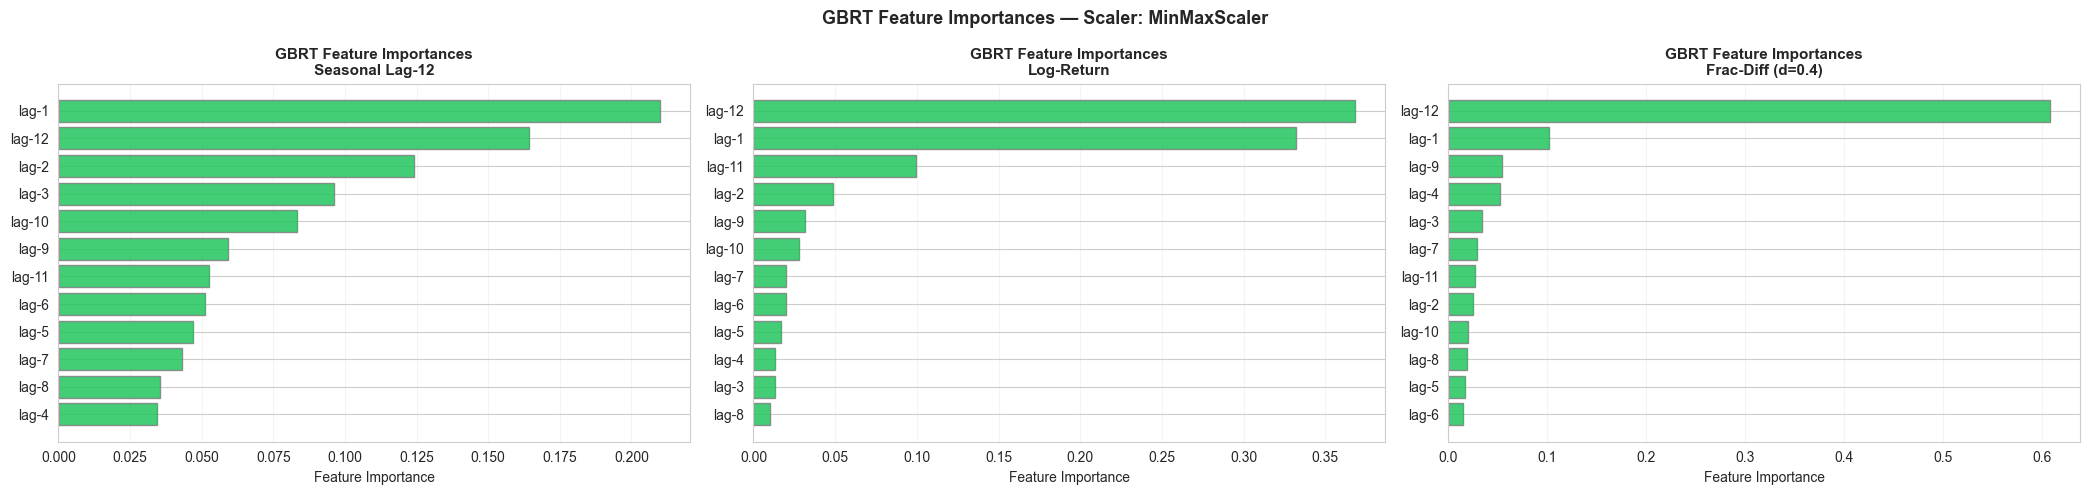

[SAVED] pA_gbrt_importance_MinMaxScaler.png


In [45]:
# ── GBRT Feature Importance ───────────────────────────────────────────────
# Shows which lag positions (window features) are most informative.
# Importances come from the last refit of each walk-forward run.

if pipeline_a_results and pipeline_a_results.get("gbrt_importances"):
    imps = pipeline_a_results["gbrt_importances"]
    valid_modes = [m for m in TRANSFORMATIONS if imps.get(m) is not None]
    if not valid_modes:
        print("[INFO] No GBRT importances available (no refit occurred).")
    else:
        fig, axes = plt.subplots(1, len(valid_modes),
                                 figsize=(7 * len(valid_modes), 5))
        if len(valid_modes) == 1:
            axes = [axes]
        for ax, mode in zip(axes, valid_modes):
            imp = imps[mode]
            # Label lag positions: lag-14 is the most distant, lag-1 the most recent
            lag_labels = [f"lag-{WINDOW_SIZE - i}" for i in range(WINDOW_SIZE)]
            sorted_idx = np.argsort(imp)
            ax.barh(
                [lag_labels[i] for i in sorted_idx],
                imp[sorted_idx],
                color="#22c55e", edgecolor="gray", alpha=0.85,
            )
            ax.set_title(f"GBRT Feature Importances\n{_LABEL_MAP[mode]}",
                         fontsize=11, fontweight="bold")
            ax.set_xlabel("Feature Importance")
            ax.grid(True, alpha=0.2, axis="x")
        plt.suptitle(f"GBRT Feature Importances — Scaler: {SCALER_TYPE}",
                     fontsize=13, fontweight="bold")
        plt.tight_layout()
        fname_imp = f"pA_gbrt_importance_{SCALER_TYPE}.png"
        plt.savefig(fname_imp, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"[SAVED] {fname_imp}")
else:
    print("[INFO] Run Pipeline A first to see GBRT feature importances.")


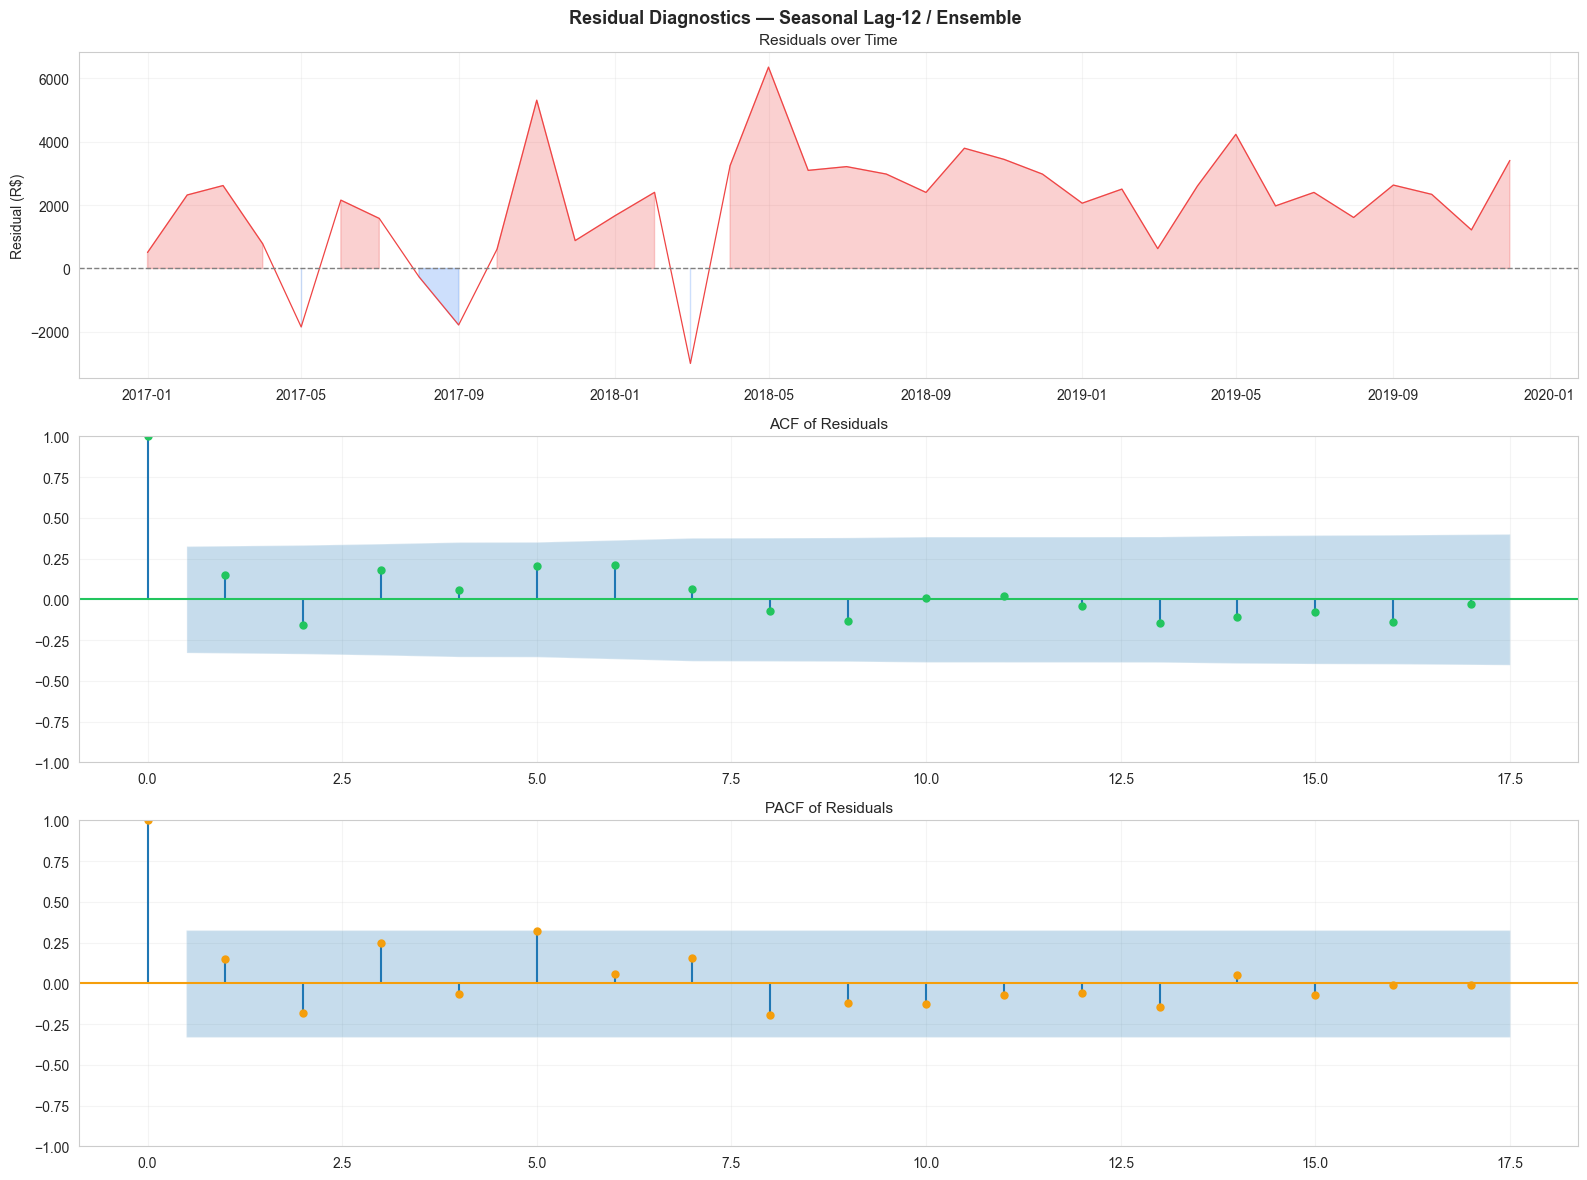

[SAVED] pA_residuals_MinMaxScaler.png

══════════════════════════════════════════════════════════════
  RESIDUAL DIAGNOSTICS SUMMARY
  Model: Ensemble  |  Transform: Seasonal Lag-12
══════════════════════════════════════════════════════════════

  Ljung-Box Test  (H0: residuals are white noise)
    Lags     Statistic     p-value    White noise?
  ──────  ────────────  ──────────  ──────────────
       6        7.1220      0.3097             YES
      12        8.5710      0.7391             YES
      18       12.4506      0.8231             YES
      24       17.0682      0.8457             YES

  ADF Test on Transformed Series  (H0: unit root present)
     Statistic     p-value   Lags used   Stationary?
  ────────────  ──────────  ──────────  ────────────
       -2.9739      0.0374          15           YES
  Critical values: 1%=-3.460  5%=-2.874  10%=-2.574
══════════════════════════════════════════════════════════════


In [46]:
# ── Residual Diagnostics — best model: Ensemble / Seasonal Lag-12 ────────
# Verifies whether residuals behave as white noise and whether the input
# transformed series is stationary before modelling.

BEST_MODE  = "sazonal_lag12"
BEST_MODEL = "Ensemble"

if pipeline_a_results and BEST_MODE in pipeline_a_results.get("results", {}):
    res_best  = pipeline_a_results["results"][BEST_MODE][BEST_MODEL]
    residuals = res_best["pred"] - res_best["real"]
    test_dates = df["data"].iloc[res_best["indices"]].values

    # ── 1. Residuals over time + ACF + PACF ──────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    fig.suptitle(
        f"Residual Diagnostics — {_LABEL_MAP[BEST_MODE]} / {BEST_MODEL}",
        fontsize=13, fontweight="bold")

    axes[0].plot(test_dates, residuals, color="#ef4444", lw=0.9)
    axes[0].axhline(0, color="gray", ls="--", lw=1)
    axes[0].fill_between(test_dates, residuals, 0,
                         where=(residuals > 0), alpha=0.25, color="#ef4444")
    axes[0].fill_between(test_dates, residuals, 0,
                         where=(residuals < 0), alpha=0.25, color="#3b82f6")
    axes[0].set_title("Residuals over Time", fontsize=11)
    axes[0].set_ylabel("Residual (R$)")
    axes[0].grid(True, alpha=0.2)

    max_lags = min(24, len(residuals) // 2 - 1)
    plot_acf(residuals, lags=max_lags, ax=axes[1], color="#22c55e", alpha=0.05)
    axes[1].set_title("ACF of Residuals", fontsize=11)
    axes[1].grid(True, alpha=0.2)

    plot_pacf(residuals, lags=max_lags, ax=axes[2], color="#f59e0b", alpha=0.05)
    axes[2].set_title("PACF of Residuals", fontsize=11)
    axes[2].grid(True, alpha=0.2)

    plt.tight_layout()
    fname_res = f"pA_residuals_{SCALER_TYPE}.png"
    plt.savefig(fname_res, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {fname_res}")

    # ── 2. Ljung-Box test (H0: residuals are white noise) ─────────────
    lb = acorr_ljungbox(residuals, lags=[6, 12, 18, 24], return_df=True)

    # ── 3. ADF test on transformed series (H0: unit root / non-stationary) ──
    values_raw = df["values"].values.astype(np.float64)
    transformed_series, _ = create_series_seasonal(values_raw)
    adf_stat, adf_p, adf_lags_used, adf_nobs, adf_crit, _ = adfuller(
        transformed_series, autolag="AIC")

    # ── 4. Summary table ──────────────────────────────────────────────
    print(f"\n{'═'*62}")
    print(f"  RESIDUAL DIAGNOSTICS SUMMARY")
    print(f"  Model: {BEST_MODEL}  |  Transform: {_LABEL_MAP[BEST_MODE]}")
    print(f"{'═'*62}")

    print(f"\n  Ljung-Box Test  (H0: residuals are white noise)")
    print(f"  {'Lags':>6}  {'Statistic':>12}  {'p-value':>10}  {'White noise?':>14}")
    print(f"  {'─'*6}  {'─'*12}  {'─'*10}  {'─'*14}")
    for _, row in lb.iterrows():
        wn = "YES" if row["lb_pvalue"] > 0.05 else "NO"
        print(f"  {int(row.name):>6}  {row['lb_stat']:>12.4f}  "
              f"{row['lb_pvalue']:>10.4f}  {wn:>14}")

    print(f"\n  ADF Test on Transformed Series  (H0: unit root present)")
    print(f"  {'Statistic':>12}  {'p-value':>10}  {'Lags used':>10}  {'Stationary?':>12}")
    print(f"  {'─'*12}  {'─'*10}  {'─'*10}  {'─'*12}")
    stat_yn = "YES" if adf_p < 0.05 else "NO"
    print(f"  {adf_stat:>12.4f}  {adf_p:>10.4f}  {adf_lags_used:>10}  {stat_yn:>12}")
    print(f"  Critical values: 1%={adf_crit['1%']:.3f}  "
          f"5%={adf_crit['5%']:.3f}  10%={adf_crit['10%']:.3f}")
    print(f"{'═'*62}")

else:
    print("[INFO] Run Pipeline A first to see residual diagnostics.")


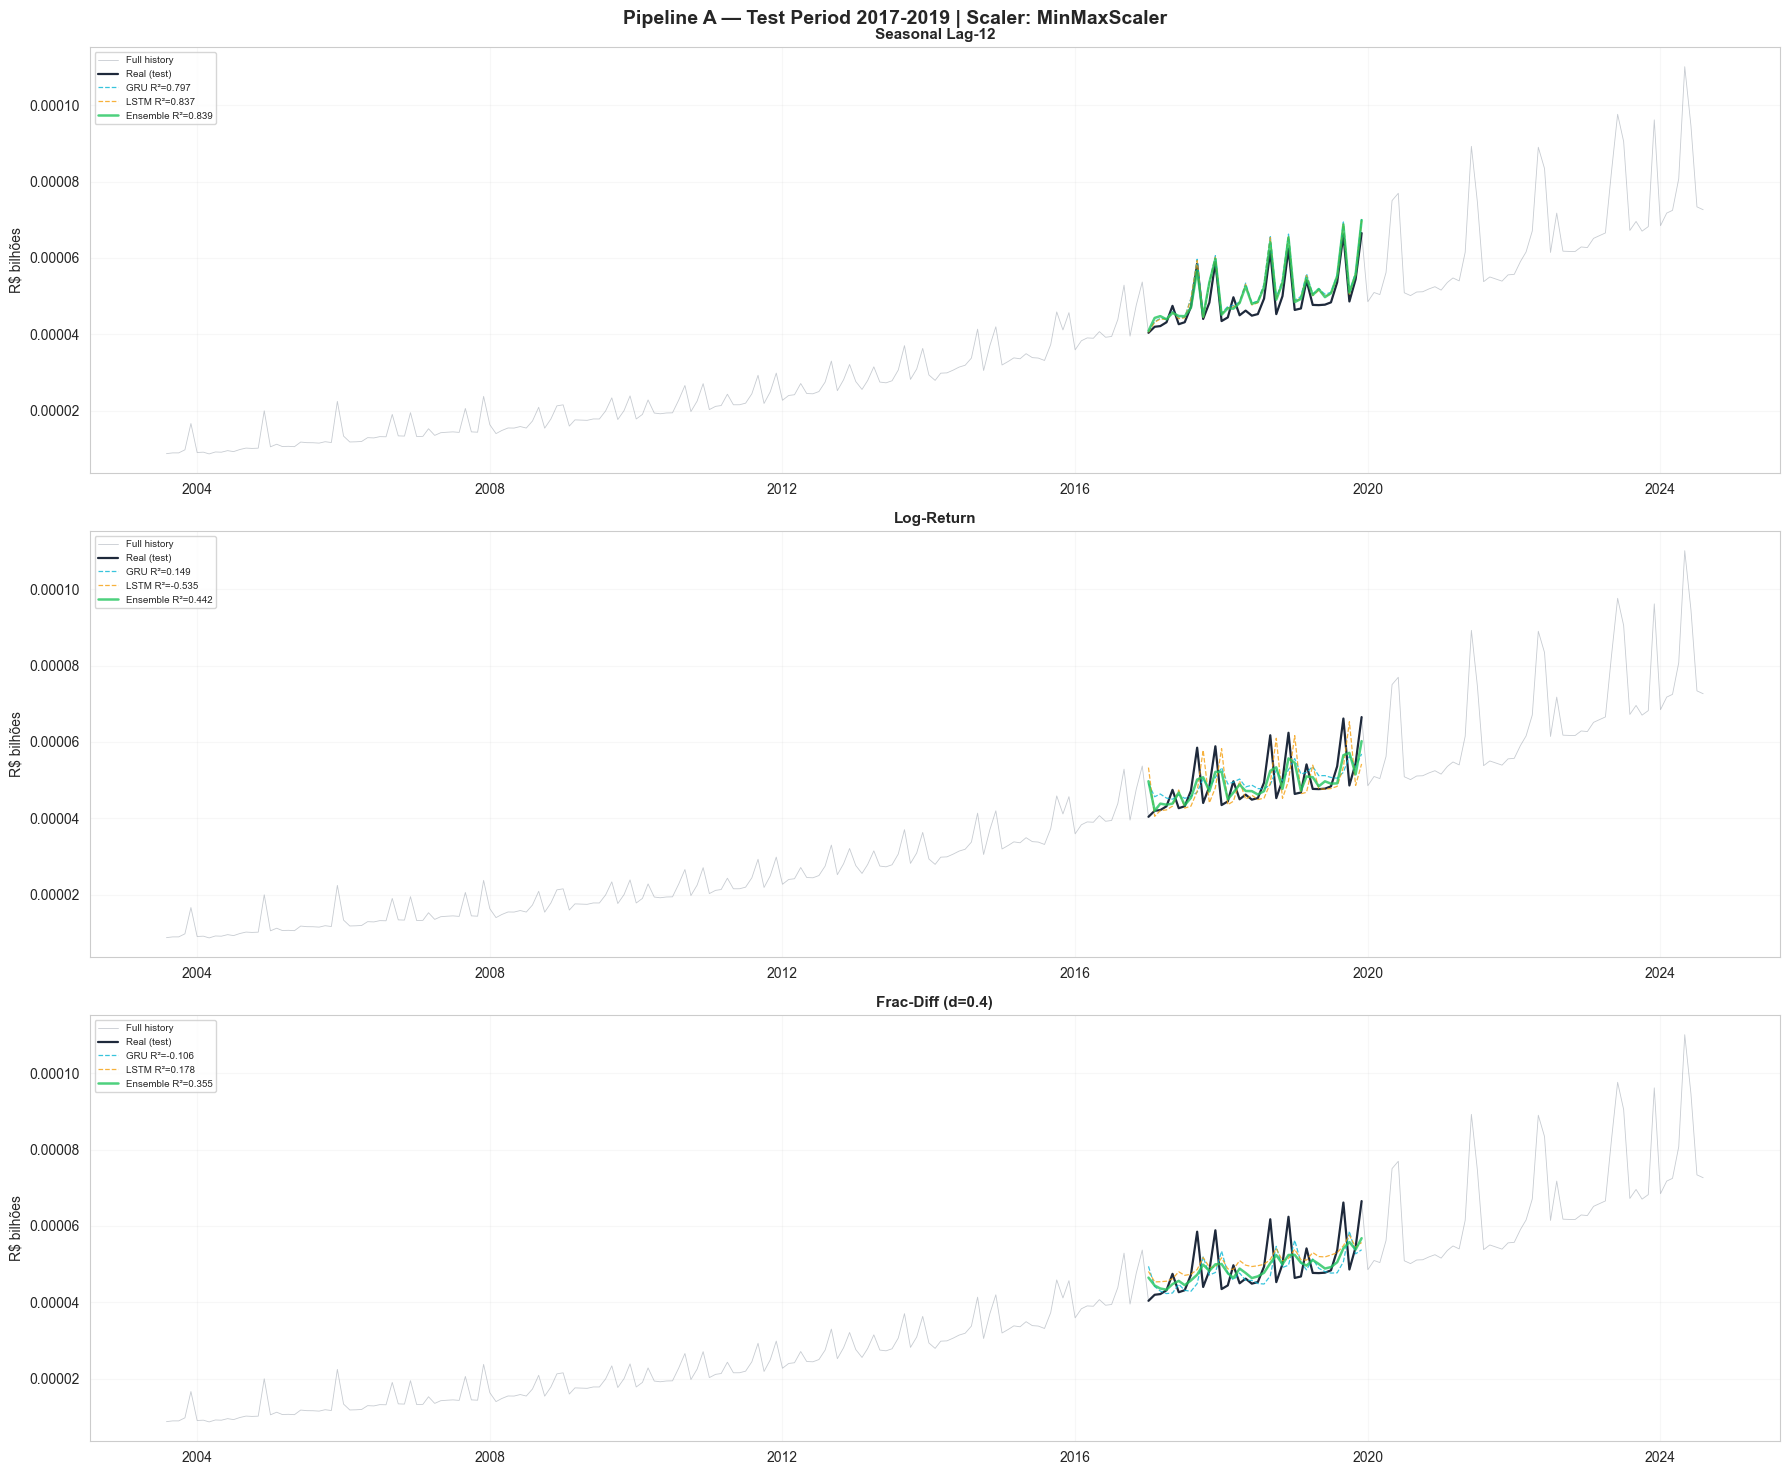

[SAVED] pA_test_MinMaxScaler.png


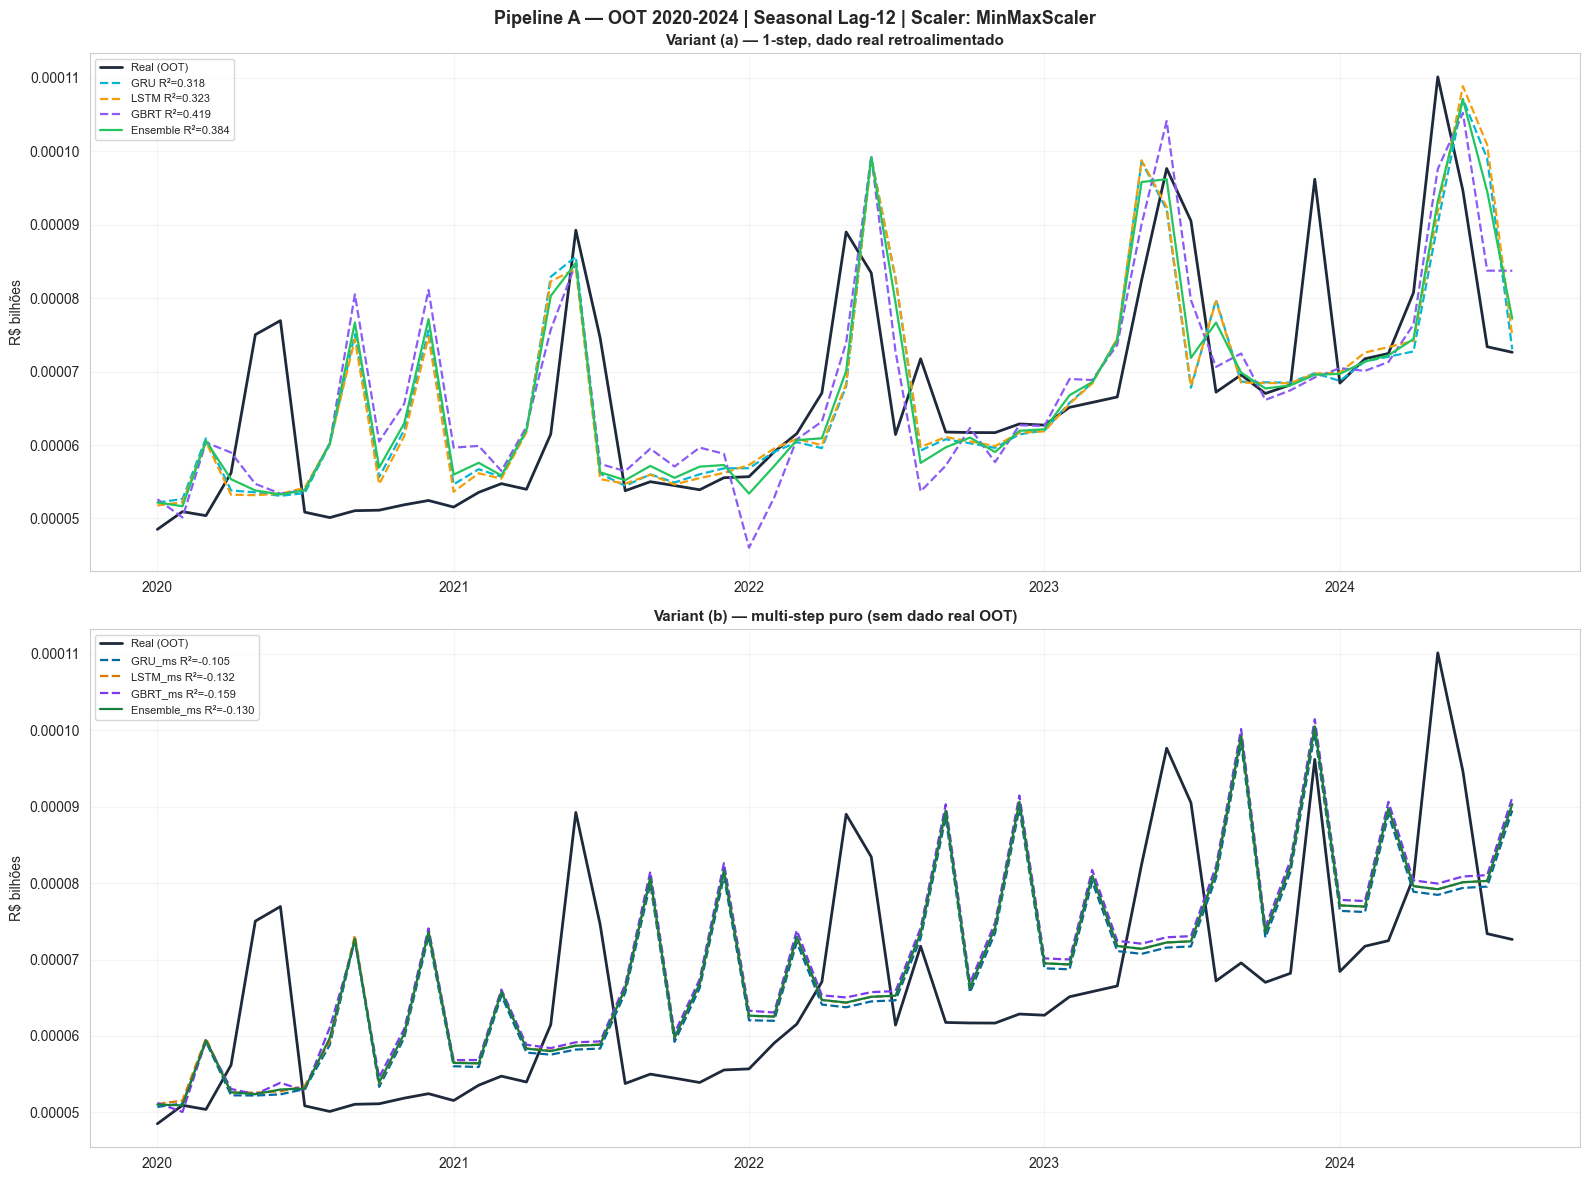

[SAVED] pA_oot_MinMaxScaler.png


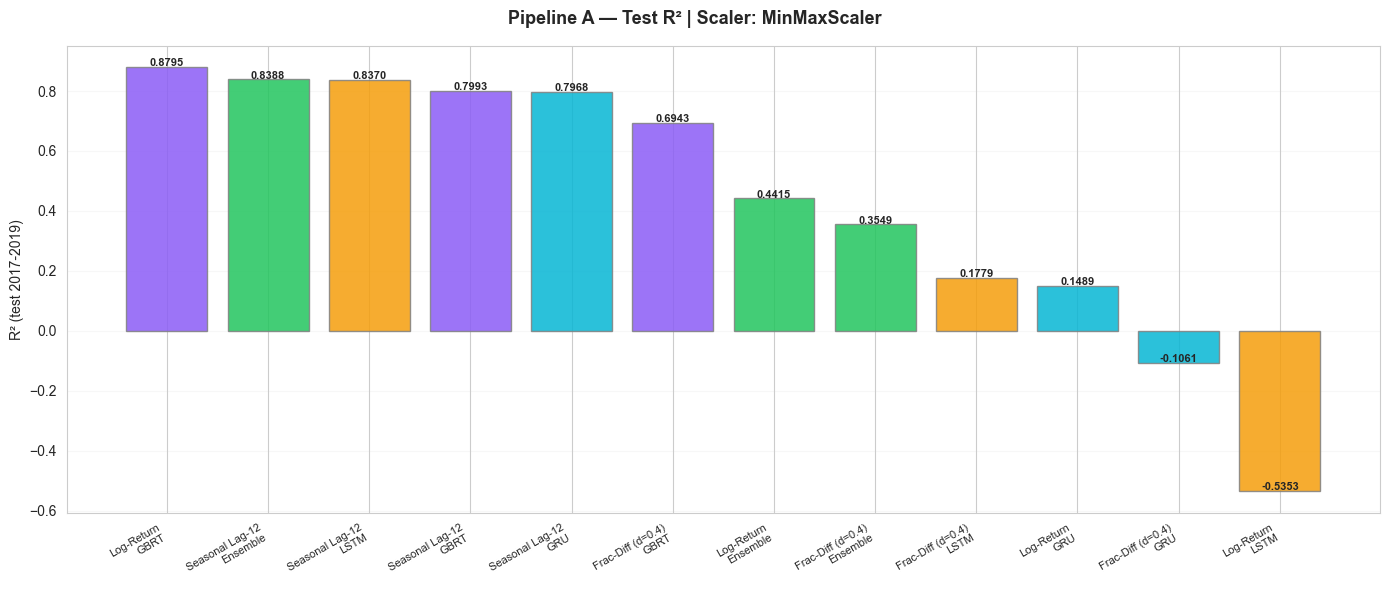

[SAVED] pA_test_r2_MinMaxScaler.png


In [47]:
# [SUBSTITUIR Cell 17]
# ── Pipeline A — Visualizations ──────────────────────────────────────

def plot_pipeline_a(df: pd.DataFrame, results: dict, scaler_label: str):
    """
    Visualize Pipeline A results using the new fixed-split structure.
    Plots: test walk-forward series, OOT comparison (both variants),
    and R² bar chart across modes.
    """
    if not results or not results.get("mode_results"):
        return

    mode_res  = results["mode_results"]
    test_mets = results["metrics"]
    oot_mets  = results.get("oot_metrics", {})
    best_mode = results.get("best_mode", TRANSFORMATIONS[0])
    CORES = {"GRU": "#06b6d4", "LSTM": "#f59e0b", "Ensemble": "#22c55e"}
    CORES_MS = {"GRU": "#0369a1", "LSTM": "#d97706", "Ensemble": "#15803d"}

    # ── 1. Test walk-forward per transform ───────────────────────────
    valid_modes = [m for m in TRANSFORMATIONS if m in mode_res
                   and len(mode_res[m].get("df_test", pd.DataFrame())) > 0]
    if not valid_modes:
        print("[INFO] No test results to plot.")
        return

    n_modes = len(valid_modes)
    fig, axes = plt.subplots(n_modes, 1, figsize=(18, 5 * n_modes))
    if n_modes == 1:
        axes = [axes]
    fig.suptitle(f"Pipeline A — Test Period 2017-2019 | Scaler: {scaler_label}",
                 fontsize=14, fontweight="bold")

    for ax, mode in zip(axes, valid_modes):
        df_t = mode_res[mode]["df_test"]
        ax.plot(df["data"], df["values"] / 1e9, color="#475569",
                lw=0.6, alpha=0.3, label="Full history")
        ax.plot(df_t["data"], df_t["real"] / 1e9, color="#1e293b",
                lw=1.6, label="Real (test)")
        for name in ("GRU", "LSTM", "Ensemble"):
            col = f"pred_{name}"
            if col not in df_t.columns:
                continue
            m  = test_mets.get(f"{mode}_{name}", {})
            ls = "-" if name == "Ensemble" else "--"
            lw = 1.8 if name == "Ensemble" else 0.9
            ax.plot(df_t["data"], df_t[col] / 1e9, color=CORES[name],
                    lw=lw, linestyle=ls, alpha=0.8,
                    label=f"{name} R²={m.get('R2', float('nan')):.3f}")
        ax.set_title(_LABEL_MAP[mode], fontsize=11, fontweight="bold")
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.15)
        ax.set_ylabel("R$ bilhões")

    plt.tight_layout()
    fname = f"pA_test_{scaler_label}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {fname}")

    # ── 2. OOT comparison (1-step vs multi-step) — best_mode only ────
    df_oot = mode_res.get(best_mode, {}).get("df_oot", pd.DataFrame())
    if len(df_oot) > 0:
        oot_pred_cols_1s = [c for c in df_oot.columns
                            if c.startswith("pred_") and not c.endswith("_ms")]
        oot_pred_cols_ms = [c for c in df_oot.columns if c.endswith("_ms")]

        fig2, axes2 = plt.subplots(2, 1, figsize=(16, 12))
        fig2.suptitle(
            f"Pipeline A — OOT 2020-2024 | {_LABEL_MAP[best_mode]} | "
            f"Scaler: {scaler_label}",
            fontsize=13, fontweight="bold",
        )

        # Top: variant (a) — 1-step real feedback
        ax_a = axes2[0]
        if "real" in df_oot.columns:
            ax_a.plot(df_oot["data"], df_oot["real"] / 1e9,
                      color="#1e293b", lw=2.0, label="Real (OOT)")
        for col in oot_pred_cols_1s:
            name = col.replace("pred_", "")
            m = oot_mets.get(f"{best_mode}_{name}", {})
            ls = "-" if name == "Ensemble" else "--"
            ax_a.plot(df_oot["data"], df_oot[col] / 1e9,
                      color=CORES.get(name, "#8b5cf6"), lw=1.6, linestyle=ls,
                      label=f"{name} R²={m.get('R2', float('nan')):.3f}")
        ax_a.set_title("Variant (a) — 1-step, dado real retroalimentado",
                       fontsize=11, fontweight="bold")
        ax_a.set_ylabel("R$ bilhões")
        ax_a.legend(fontsize=8, loc="upper left")
        ax_a.grid(True, alpha=0.2)

        # Bottom: variant (b) — multi-step pure
        ax_b = axes2[1]
        if "real" in df_oot.columns:
            ax_b.plot(df_oot["data"], df_oot["real"] / 1e9,
                      color="#1e293b", lw=2.0, label="Real (OOT)")
        for col in oot_pred_cols_ms:
            name_ms = col.replace("pred_", "").replace("_ms", "")
            ms_m = results["mode_results"][best_mode]["oot_ms_metrics"]
            m = ms_m.get(col.replace("pred_", ""), {})
            ls = "-" if "Ensemble" in col else "--"
            ax_b.plot(df_oot["data"], df_oot[col] / 1e9,
                      color=CORES_MS.get(name_ms, "#7c3aed"),
                      lw=1.6, linestyle=ls,
                      label=f"{col.replace('pred_','')} R²={m.get('R2', float('nan')):.3f}")
        ax_b.set_title("Variant (b) — multi-step puro (sem dado real OOT)",
                       fontsize=11, fontweight="bold")
        ax_b.set_ylabel("R$ bilhões")
        ax_b.legend(fontsize=8, loc="upper left")
        ax_b.grid(True, alpha=0.2)

        plt.tight_layout()
        fname_oot = f"pA_oot_{scaler_label}.png"
        plt.savefig(fname_oot, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"[SAVED] {fname_oot}")

    # ── 3. R² bar chart (test metrics) ───────────────────────────────
    fig3, ax3 = plt.subplots(figsize=(14, 6))
    fig3.suptitle(f"Pipeline A — Test R² | Scaler: {scaler_label}",
                  fontsize=13, fontweight="bold")
    combos = sorted(
        [(k, v["R2"], _LABEL_MAP.get(k.rsplit("_", 1)[0], k))
         for k, v in test_mets.items()],
        key=lambda x: x[1], reverse=True,
    )
    xlabels = [f"{c[2]}\n{c[0].rsplit('_', 1)[-1]}" for c in combos]
    r2_vals = [c[1] for c in combos]
    bar_cols = [CORES.get(c[0].rsplit("_", 1)[-1], "#8b5cf6") for c in combos]
    bars = ax3.bar(range(len(combos)), r2_vals, color=bar_cols,
                   edgecolor="gray", alpha=0.85)
    ax3.set_xticks(range(len(combos)))
    ax3.set_xticklabels(xlabels, fontsize=8, rotation=30, ha="right")
    ax3.set_ylabel("R² (test 2017-2019)")
    ax3.grid(True, alpha=0.15, axis="y")
    for bar, val in zip(bars, r2_vals):
        ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f"{val:.4f}", ha="center", fontsize=8, fontweight="bold")
    plt.tight_layout()
    fname_r2 = f"pA_test_r2_{scaler_label}.png"
    plt.savefig(fname_r2, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {fname_r2}")


if pipeline_a_results:
    plot_pipeline_a(df, pipeline_a_results, SCALER_TYPE)


### Pipeline B — Temporal Fusion Transformer (TFT v5)


In [48]:
# [SUBSTITUIR Cell 19]
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  PIPELINE B — run_tft_pipeline()  — Fixed Splits + Ablation         ║
# ╚══════════════════════════════════════════════════════════════════════╝

def run_tft_pipeline(df_raw: pd.DataFrame) -> dict:
    """
    Fixed-split TFT pipeline with augmentation ablation.

    Runs two variants back-to-back with the same HP:
      - "with_aug"    : use_augmentation=True  (TFT_aug)
      - "without_aug" : use_augmentation=False (TFT_clean)

    Optuna (if enabled) runs once with the current TFT_CONFIG setting so
    HP selection is not biased toward either variant.

    Returns
    -------
    dict with keys "with_aug" and "without_aug", each sub-dict contains:
      final_metrics, df_oot, best_hp, best_tft, raw_preds, pred_np,
      actuals_log, test_metrics
    """
    if not TORCH_AVAILABLE:
        print("[SKIP] PyTorch not available — skipping Pipeline B.")
        return {}

    print(f"\n{'█'*70}")
    print(f"  PIPELINE B — TFT (fixed splits) — Augmentation Ablation")
    print(f"  Scaler: {SCALER_TYPE}")
    print(f"  Train→{TRAIN_END}  |  Val→{VAL_END}  |  Test→{TEST_END}")
    print(f"{'█'*70}")

    tcfg     = TFT_CONFIG
    MAX_PRED = tcfg["max_prediction_length"]

    # ── Default hyperparameters ───────────────────────────────────────
    best_hp = dict(
        hidden_size=tcfg["hidden_size"],
        attention_head_size=tcfg["attention_head_size"],
        dropout=tcfg["dropout"],
        learning_rate=tcfg["learning_rate"] or 0.003,
    )

    # ── Optuna: run once with current use_augmentation setting ────────
    if tcfg.get("use_optuna") and OPTUNA_AVAILABLE:
        print(f"\n  Optuna search ({tcfg['optuna_trials']} trials)  "
              f"eval metric: MAPE on last {MAX_PRED}m of {VAL_END}...")

        def objective(trial):
            hp = dict(
                hidden_size=trial.suggest_categorical(
                    "hidden_size", [16, 24, 32, 48]),
                attention_head_size=trial.suggest_categorical(
                    "heads", [1, 2, 4]),
                dropout=trial.suggest_float("dropout", 0.1, 0.4, step=0.05),
                learning_rate=trial.suggest_float("lr", 1e-4, 0.01, log=True),
            )
            try:
                m, *_ = train_tft_fold(
                    df_raw=df_raw,
                    train_end_date=TRAIN_END,
                    val_end_date=VAL_END,
                    hidden_size=hp["hidden_size"],
                    attention_head_size=hp["attention_head_size"],
                    dropout=hp["dropout"],
                    learning_rate=hp["learning_rate"],
                    max_epochs=60,
                    verbose=False,
                )
                return m["MAPE_%"]
            except Exception:
                return 100.0

        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=tcfg["optuna_trials"],
                       show_progress_bar=True)
        best_hp.update({
            "hidden_size":         study.best_params["hidden_size"],
            "attention_head_size": study.best_params["heads"],
            "dropout":             study.best_params["dropout"],
            "learning_rate":       study.best_params["lr"],
        })
        print(f"  Best val MAPE={study.best_value:.2f}%  params={best_hp}")

    # ── Ablation loop: [True, False] for use_augmentation ────────────
    ablation_variants = [
        ("with_aug",    True,  "TFT_aug   (use_augmentation=True)"),
        ("without_aug", False, "TFT_clean (use_augmentation=False)"),
    ]
    ablation_results = {}
    _orig_aug = tcfg.get("use_augmentation")

    for variant_key, aug_flag, aug_label in ablation_variants:
        print(f"\n{'─'*70}")
        print(f"  Variant: {aug_label}")
        print(f"{'─'*70}")

        # Temporarily override augmentation flag for this run
        tcfg["use_augmentation"] = aug_flag

        try:
            # ── Validate HP on the test period (2017-2019) ───────────
            print(f"\n  Validating HP on test period "
                  f"(train+val→{VAL_END}, score near {TEST_END})...")
            try:
                test_metrics, *_ = train_tft_fold(
                    df_raw=df_raw,
                    train_end_date=VAL_END,
                    val_end_date=TEST_END,
                    hidden_size=best_hp["hidden_size"],
                    attention_head_size=best_hp["attention_head_size"],
                    dropout=best_hp["dropout"],
                    learning_rate=best_hp["learning_rate"],
                    max_epochs=tcfg["max_epochs"],
                    verbose=False,
                )
                print(f"  Test (proxy {TEST_END}): "
                      f"R²={test_metrics['R2']:.4f}  "
                      f"MAPE={test_metrics['MAPE_%']:.2f}%  "
                      f"RMSE=R${test_metrics['RMSE']:,.0f}")
            except Exception as exc:
                print(f"  [WARN] Test validation failed: {exc}")
                test_metrics = {}

            # ── Final model: train on 2004-2019 ──────────────────────
            print(f"\n  Training FINAL model on 2004→{TEST_END} ...")
            final_metrics, best_tft, training_ds, raw_preds, pred_np, actuals_log = \
                train_tft_fold(
                    df_raw=df_raw,
                    train_end_date=TEST_END,
                    val_end_date=TEST_END,
                    hidden_size=best_hp["hidden_size"],
                    attention_head_size=best_hp["attention_head_size"],
                    dropout=best_hp["dropout"],
                    learning_rate=best_hp["learning_rate"],
                    max_epochs=tcfg["max_epochs"],
                    verbose=True,
                )
            print(f"\n  FINAL fit: R²={final_metrics['R2']:.4f}  "
                  f"MAPE={final_metrics['MAPE_%']:.2f}%  "
                  f"RMSE=R${final_metrics['RMSE']:,.0f}")

            # ── OOT rolling forecast: 2020-2024 ──────────────────────
            oot_start_str = "2020-01"
            oot_has_data  = (df_raw["data"] >= f"{oot_start_str}-01").any()
            df_oot      = pd.DataFrame()
            oot_metrics = {}

            if oot_has_data:
                print(f"\n  Rolling OOT forecast 2020-2024 "
                      f"(chunks of {MAX_PRED} months)...")
                try:
                    df_oot = tft_rolling_forecast_oot(
                        best_tft=best_tft,
                        training_ds=training_ds,
                        df_raw_full=df_raw,
                        oot_start_date=oot_start_str,
                        max_pred=MAX_PRED,
                    )
                    if len(df_oot) > 0:
                        oot_metrics = compute_metrics(
                            df_oot["real"].values, df_oot["pred_TFT"].values)
                        print(f"  OOT (2020-2024): "
                              f"R²={oot_metrics['R2']:.4f}  "
                              f"MAPE={oot_metrics['MAPE_%']:.2f}%  "
                              f"RMSE=R${oot_metrics['RMSE']:,.0f}  "
                              f"({len(df_oot)} months)")
                except Exception as exc:
                    print(f"  [WARN] Rolling OOT forecast failed: {exc}")
            else:
                print(f"  [INFO] No data after {oot_start_str} — OOT forecast skipped.")

            ablation_results[variant_key] = dict(
                test_metrics=test_metrics,
                final_metrics=oot_metrics if oot_metrics else final_metrics,
                df_oot=df_oot,
                best_hp=best_hp.copy(),
                best_tft=best_tft,
                training_ds=training_ds,
                raw_preds=raw_preds,
                pred_np=pred_np,
                actuals_log=actuals_log,
            )

        finally:
            # Always restore original flag
            tcfg["use_augmentation"] = _orig_aug

    # ── Ablation summary ─────────────────────────────────────────────
    print(f"\n{'═'*70}")
    print("  ABLATION SUMMARY — TFT OOT 2020-2024")
    print(f"{'═'*70}")
    _lbl = {"with_aug": "TFT_aug  ", "without_aug": "TFT_clean"}
    for vk, res in ablation_results.items():
        m = res.get("final_metrics", {})
        print(f"  {_lbl.get(vk, vk)}  R²={m.get('R2', float('nan')):.4f}  "
              f"MAPE={m.get('MAPE_%', float('nan')):.2f}%  "
              f"RMSE=R${m.get('RMSE', float('nan')):,.0f}")

    # ── Recommendation: print if TFT_clean >= TFT_aug ────────────────
    with_m    = ablation_results.get("with_aug",    {}).get("final_metrics", {})
    without_m = ablation_results.get("without_aug", {}).get("final_metrics", {})
    if with_m and without_m:
        mape_aug   = with_m.get("MAPE_%",   float("inf"))
        mape_clean = without_m.get("MAPE_%", float("inf"))
        if mape_clean <= mape_aug * 1.02:   # within 2 % tolerance
            print("\n  [RECOMENDACAO] Variante SEM augmentation e equivalente ou superior.")
            print("  => Recomenda-se REMOVER create_tft_groups() do pipeline final para o")
            print("     artigo: ruido gaussiano nao agrega ganho preditivo e e metodolo-")
            print("     gicamente questionavel para series economicas temporais.")

    return ablation_results


# ── RUN ───────────────────────────────────────────────────────────────
pipeline_b_results = {}
if "tft" in PIPELINES_TO_RUN:
    with _pipeline_timer("Pipeline B — TFT (ablação)"):
        pipeline_b_results = run_tft_pipeline(df)
else:
    print("[SKIP] Pipeline B not in PIPELINES_TO_RUN.")



██████████████████████████████████████████████████████████████████████
  PIPELINE B — TFT (fixed splits) — Augmentation Ablation
  Scaler: MinMaxScaler
  Train→2015-12  |  Val→2016-12  |  Test→2019-12
██████████████████████████████████████████████████████████████████████

  Optuna search (20 trials)  eval metric: MAPE on last 6m of 2016-12...


  0%|                                                                                           | 0/20 [00:00<?, ?it/s]GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [

  Best val MAPE=6.06%  params={'hidden_size': 16, 'attention_head_size': 1, 'dropout': 0.15000000000000002, 'learning_rate': 0.0002740772976326783}

──────────────────────────────────────────────────────────────────────
  Variant: TFT_aug   (use_augmentation=True)
──────────────────────────────────────────────────────────────────────

  Validating HP on test period (train+val→2016-12, score near 2019-12)...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightn

  Test (proxy 2019-12): R²=-1.2952  MAPE=10.31%  RMSE=R$8,904

  Training FINAL model on 2004→2019-12 ...


...

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=100` reached.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightn


  FINAL fit: R²=-2.4414  MAPE=20.28%  RMSE=R$10,903

  Rolling OOT forecast 2020-2024 (chunks of 6 months)...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightn

  OOT (2020-2024): R²=-0.2447  MAPE=16.80%  RMSE=R$15,920  (56 months)

══════════════════════════════════════════════════════════════════════
  ABLATION SUMMARY — TFT OOT 2020-2024
══════════════════════════════════════════════════════════════════════
  TFT_aug    R²=0.0455  MAPE=15.80%  RMSE=R$13,941
  TFT_clean  R²=-0.2447  MAPE=16.80%  RMSE=R$15,920
  ⏱  Pipeline B — TFT (ablação): 2977.9s (49.63 min)


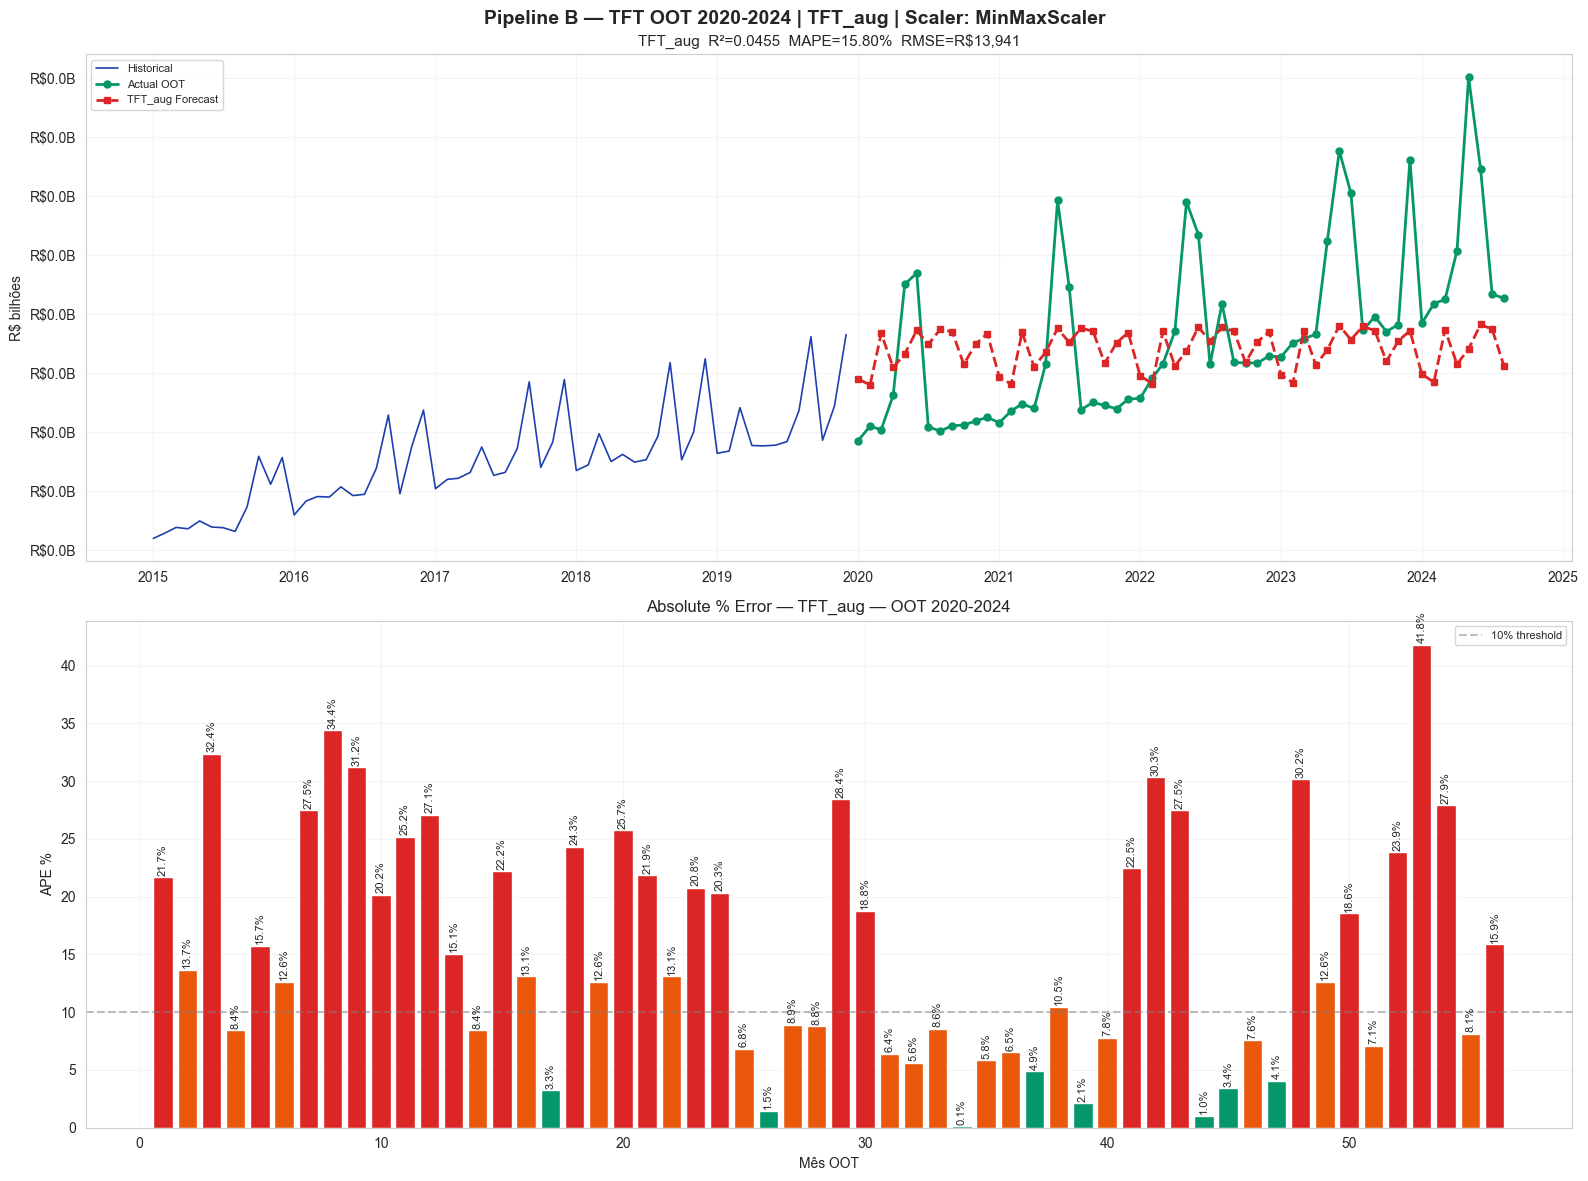

[SAVED] pB_tft_oot_with_aug_MinMaxScaler.png


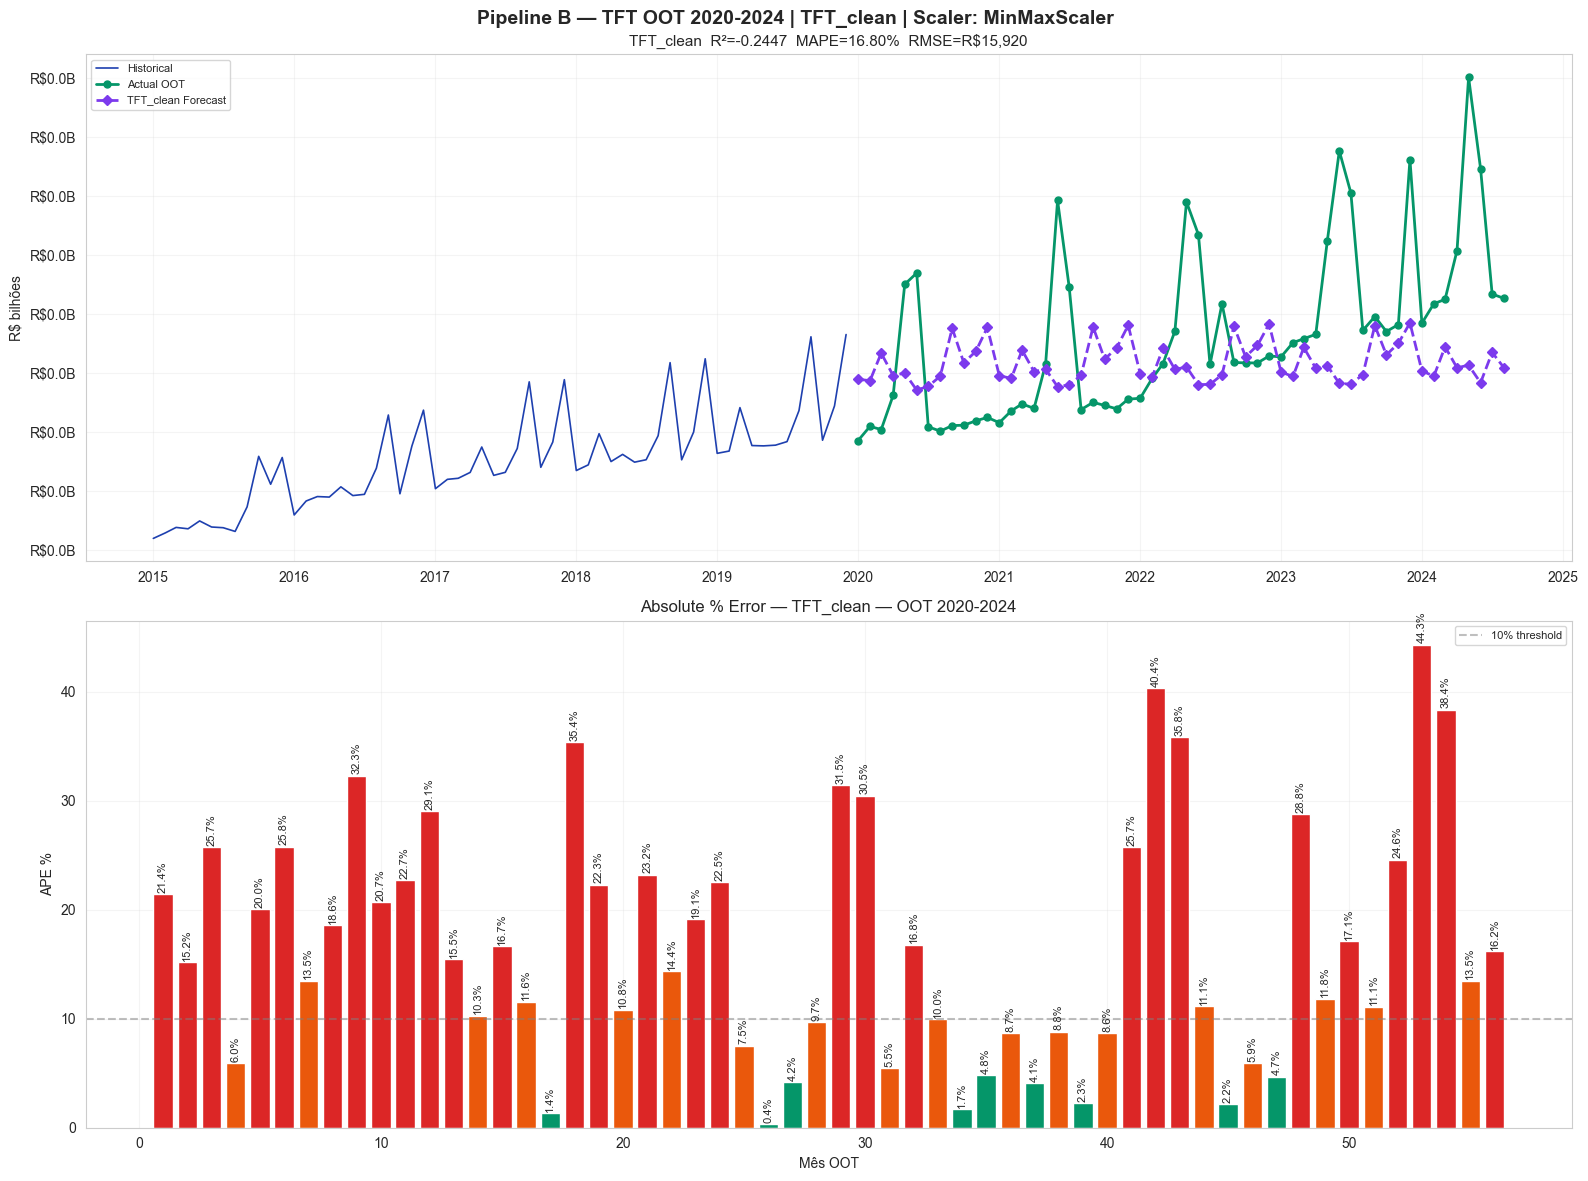

[SAVED] pB_tft_oot_without_aug_MinMaxScaler.png


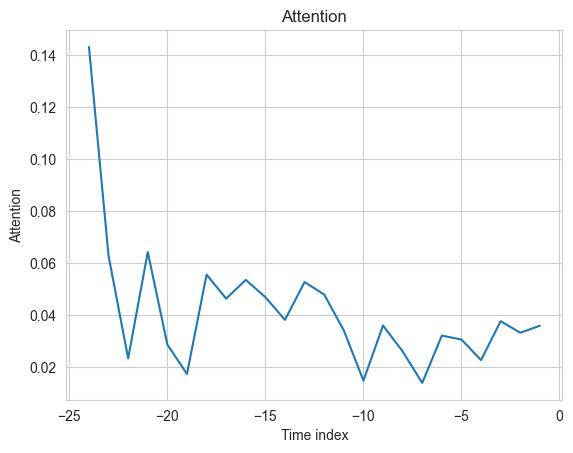

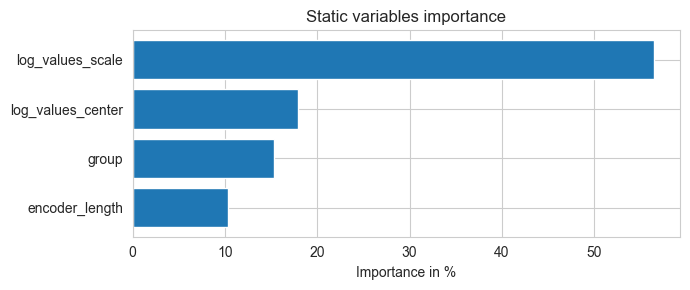

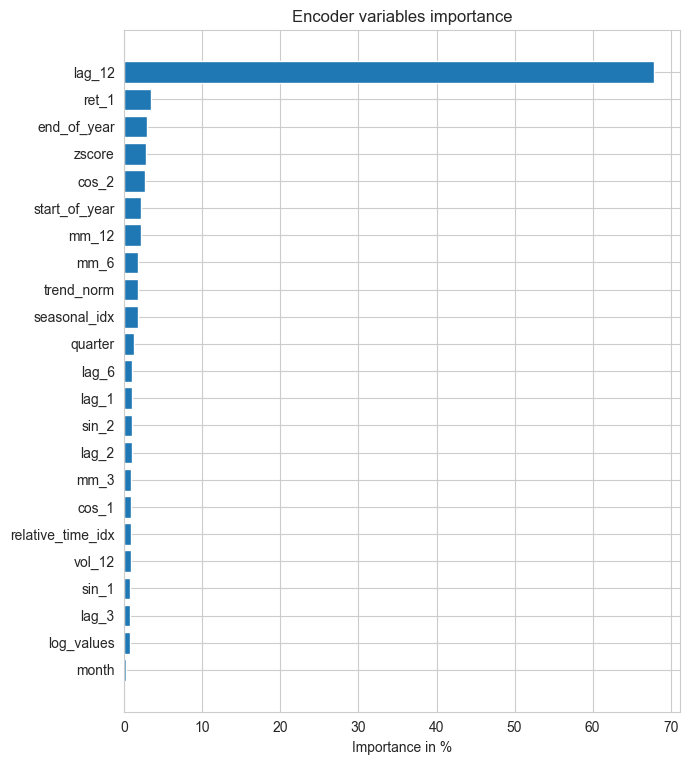

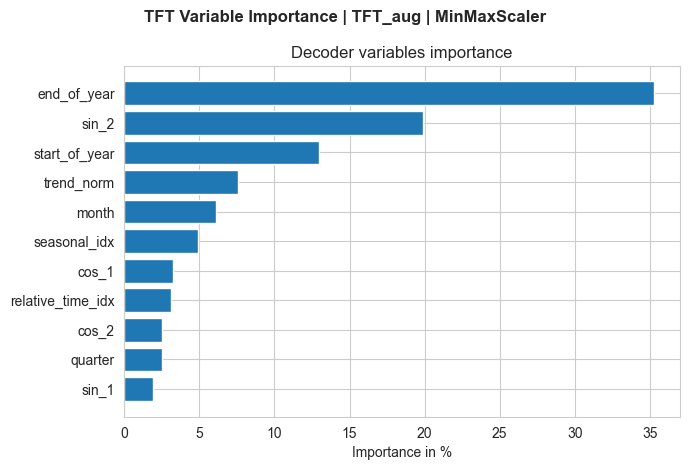

[SAVED] pB_tft_interp_MinMaxScaler.png


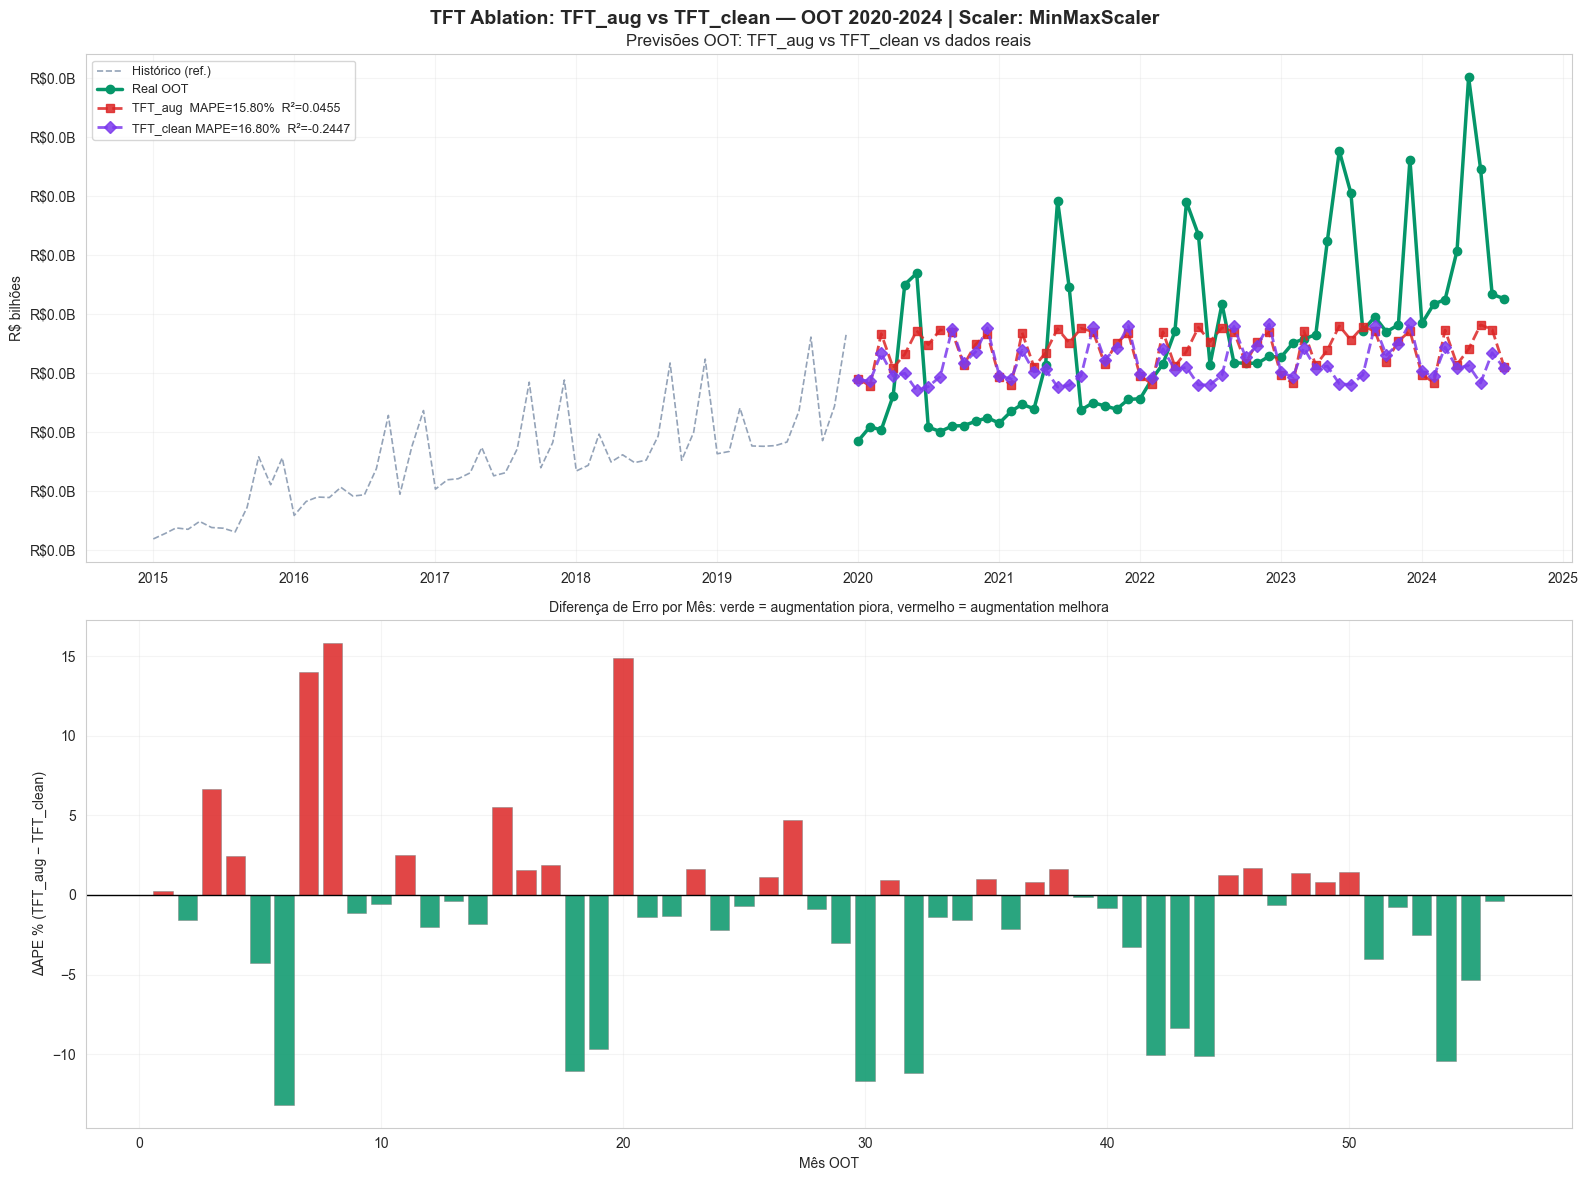

[SAVED] pB_tft_ablation_comparison_MinMaxScaler.png


In [49]:
# [SUBSTITUIR Cell 20]
# ── Pipeline B — Visualizations ──────────────────────────────────────

def plot_pipeline_b(df_raw: pd.DataFrame, results: dict, scaler_label: str):
    """
    Plot TFT OOT forecast and interpretability for each ablation variant.
    results: dict with keys 'with_aug' and 'without_aug'.
    """
    if not results:
        return

    _styles = {
        "with_aug":    {"color": "#DC2626", "label": "TFT_aug",   "marker": "s"},
        "without_aug": {"color": "#7C3AED", "label": "TFT_clean", "marker": "D"},
    }

    for variant_key, variant_res in results.items():
        style         = _styles.get(variant_key,
                                    {"color": "#DC2626", "label": variant_key, "marker": "s"})
        df_oot        = variant_res.get("df_oot", pd.DataFrame())
        final_metrics = variant_res.get("final_metrics", {})

        if len(df_oot) == 0:
            print(f"[INFO] No OOT predictions for {variant_key} — skipping plot.")
            continue

        n = len(df_oot)
        fig, axes = plt.subplots(2, 1, figsize=(16, 12))
        fig.suptitle(
            f"Pipeline B — TFT OOT 2020-2024 | {style['label']} | Scaler: {scaler_label}",
            fontsize=14, fontweight="bold",
        )

        ax = axes[0]
        oot_start = df_oot["data"].iloc[0]
        hist_mask = df_raw["data"] < oot_start
        ax.plot(df_raw.loc[hist_mask, "data"].tail(60),
                df_raw.loc[hist_mask, "values"].tail(60) / 1e9,
                color="#1E40AF", lw=1.2, label="Historical")
        ax.plot(df_oot["data"], df_oot["real"] / 1e9,
                "o-", color="#059669", lw=2, ms=5, label="Actual OOT")
        ax.plot(df_oot["data"], df_oot["pred_TFT"] / 1e9,
                f"{style['marker']}--", color=style["color"], lw=2, ms=5,
                label=f"{style['label']} Forecast")
        ax.set_title(
            f"{style['label']}  "
            f"R²={final_metrics.get('R2', float('nan')):.4f}  "
            f"MAPE={final_metrics.get('MAPE_%', float('nan')):.2f}%  "
            f"RMSE=R${final_metrics.get('RMSE', float('nan')):,.0f}",
            fontsize=11,
        )
        ax.set_ylabel("R$ bilhões")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R${x:.1f}B"))
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.2)

        ax2 = axes[1]
        errs = [
            abs(float(df_oot["pred_TFT"].iloc[i]) - float(df_oot["real"].iloc[i]))
            / max(abs(float(df_oot["real"].iloc[i])), 1) * 100
            for i in range(n)
        ]
        bar_cols = ["#059669" if e < 5 else "#EA580C" if e < 15 else "#DC2626"
                    for e in errs]
        ax2.bar(range(1, n + 1), errs, color=bar_cols)
        ax2.axhline(10, color="gray", ls="--", alpha=0.5, label="10% threshold")
        for i, e in enumerate(errs):
            ax2.text(i + 1, e + 0.3, f"{e:.1f}%", ha="center", fontsize=8,
                     rotation=90)
        ax2.set_xlabel("Mês OOT")
        ax2.set_ylabel("APE %")
        ax2.set_title(f"Absolute % Error — {style['label']} — OOT 2020-2024")
        ax2.legend(fontsize=8)
        ax2.grid(True, alpha=0.2)

        plt.tight_layout()
        fname = f"pB_tft_oot_{variant_key}_{scaler_label}.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"[SAVED] {fname}")

    # ── Interpretability (with_aug variant as baseline) ──────────────
    baseline_res = results.get("with_aug", {})
    try:
        raw_preds = baseline_res.get("raw_preds")
        best_tft  = baseline_res.get("best_tft")
        if raw_preds is not None and best_tft is not None:
            interp  = best_tft.interpret_output(raw_preds.output, reduction="sum")
            fig_i   = best_tft.plot_interpretation(interp)
            plt.suptitle(f"TFT Variable Importance | TFT_aug | {scaler_label}",
                         fontsize=12, fontweight="bold")
            plt.tight_layout()
            fname_i = f"pB_tft_interp_{scaler_label}.png"
            plt.savefig(fname_i, dpi=150, bbox_inches="tight")
            plt.show()
            print(f"[SAVED] {fname_i}")
    except Exception as e:
        print(f"[WARN] Interpretability plot failed: {e}")


def plot_tft_ablation_comparison(df_raw: pd.DataFrame, results: dict,
                                  scaler_label: str):
    """
    Overlay TFT_aug and TFT_clean OOT forecasts (2020-2024) against real data.

    Panel 1: Both predictions vs. actual on the same axes.
    Panel 2: Bar chart of ΔAPE% (TFT_aug − TFT_clean).
             Green bar  = augmentation hurts (aug has higher error).
             Red bar    = augmentation helps (aug has lower error).
    """
    if not results:
        return

    df_aug   = results.get("with_aug",    {}).get("df_oot", pd.DataFrame())
    df_clean = results.get("without_aug", {}).get("df_oot", pd.DataFrame())
    m_aug    = results.get("with_aug",    {}).get("final_metrics", {})
    m_clean  = results.get("without_aug", {}).get("final_metrics", {})

    if len(df_aug) == 0 or len(df_clean) == 0:
        print("[INFO] Incomplete OOT data — ablation comparison plot skipped.")
        return

    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    fig.suptitle(
        f"TFT Ablation: TFT_aug vs TFT_clean — OOT 2020-2024 | Scaler: {scaler_label}",
        fontsize=14, fontweight="bold",
    )

    # ── Panel 1: both forecasts vs. actual ───────────────────────────
    ax = axes[0]
    oot_start = df_aug["data"].iloc[0]
    hist_mask = df_raw["data"] < oot_start
    ax.plot(df_raw.loc[hist_mask, "data"].tail(60),
            df_raw.loc[hist_mask, "values"].tail(60) / 1e9,
            color="#94A3B8", lw=1.2, ls="--", label="Histórico (ref.)")
    ax.plot(df_aug["data"], df_aug["real"] / 1e9,
            "o-", color="#059669", lw=2.5, ms=6, label="Real OOT")
    ax.plot(df_aug["data"], df_aug["pred_TFT"] / 1e9,
            "s--", color="#DC2626", lw=2, ms=6, alpha=0.85,
            label=(f"TFT_aug  "
                   f"MAPE={m_aug.get('MAPE_%', float('nan')):.2f}%  "
                   f"R²={m_aug.get('R2', float('nan')):.4f}"))
    ax.plot(df_clean["data"], df_clean["pred_TFT"] / 1e9,
            "D--", color="#7C3AED", lw=2, ms=6, alpha=0.85,
            label=(f"TFT_clean "
                   f"MAPE={m_clean.get('MAPE_%', float('nan')):.2f}%  "
                   f"R²={m_clean.get('R2', float('nan')):.4f}"))
    ax.set_ylabel("R$ bilhões")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R${x:.1f}B"))
    ax.set_title("Previsões OOT: TFT_aug vs TFT_clean vs dados reais", fontsize=12)
    ax.legend(fontsize=9, loc="best")
    ax.grid(True, alpha=0.2)

    # ── Panel 2: ΔAPE% (TFT_aug − TFT_clean) ────────────────────────
    ax2 = axes[1]
    n = min(len(df_aug), len(df_clean))
    ape_aug = [
        abs(float(df_aug["pred_TFT"].iloc[i]) - float(df_aug["real"].iloc[i]))
        / max(abs(float(df_aug["real"].iloc[i])), 1) * 100
        for i in range(n)
    ]
    ape_clean = [
        abs(float(df_clean["pred_TFT"].iloc[i]) - float(df_clean["real"].iloc[i]))
        / max(abs(float(df_clean["real"].iloc[i])), 1) * 100
        for i in range(n)
    ]
    delta_ape = [ape_aug[i] - ape_clean[i] for i in range(n)]

    # Positive delta → aug worse than clean → red bar
    # Negative delta → aug better than clean → green bar
    bar_colors = ["#059669" if d < 0 else "#DC2626" for d in delta_ape]
    ax2.bar(range(1, n + 1), delta_ape, color=bar_colors, alpha=0.85,
            edgecolor="gray", linewidth=0.4)
    ax2.axhline(0, color="black", lw=1.0)
    ax2.set_xlabel("Mês OOT")
    ax2.set_ylabel("ΔAPE % (TFT_aug − TFT_clean)")
    ax2.set_title(
        "Diferença de Erro por Mês: verde = augmentation piora, vermelho = augmentation melhora",
        fontsize=10,
    )
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    fname = f"pB_tft_ablation_comparison_{scaler_label}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {fname}")


if pipeline_b_results:
    plot_pipeline_b(df, pipeline_b_results, SCALER_TYPE)
    plot_tft_ablation_comparison(df, pipeline_b_results, SCALER_TYPE)


### Pipeline C — Baselines 

In [50]:
import subprocess, sys as _sys

# ── pmdarima ─────────────────────────────────────────────────────────
try:
    import pmdarima as pm
    PMDARIMA_AVAILABLE = True
    print(f"[OK] pmdarima {pm.__version__}")
except ImportError:
    print("[INFO] pmdarima não encontrado — instalando...")
    subprocess.check_call(
        [_sys.executable, "-m", "pip", "install", "pmdarima", "-q"],
        stdout=subprocess.DEVNULL,
    )
    try:
        import pmdarima as pm
        PMDARIMA_AVAILABLE = True
        print(f"[OK] pmdarima {pm.__version__} instalado com sucesso")
    except ImportError:
        PMDARIMA_AVAILABLE = False
        print("[ERROR] Falha ao instalar pmdarima — SARIMA desabilitado")

# ── statsmodels Holt-Winters ──────────────────────────────────────────
try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing as HoltWinters
    ETS_AVAILABLE = True
    print("[OK] statsmodels.tsa.holtwinters disponível")
except ImportError:
    ETS_AVAILABLE = False
    print("[WARN] statsmodels não encontrado — instale com: pip install statsmodels")


[OK] pmdarima 2.1.1
[OK] statsmodels.tsa.holtwinters disponível


In [51]:
# === Nova Célula: C-2 — run_pipeline_c() ===
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  PIPELINE C — Baselines Econométricos (SARIMA + ETS)               ║
# ║  Splits temporais fixos (não dependem de TRAIN_CONFIG).             ║
# ╚══════════════════════════════════════════════════════════════════════╝

def run_pipeline_c(df: pd.DataFrame) -> dict:
    """
    Ajusta SARIMA e ETS em treino+validação (2004-01 a 2016-12),
    projeta 2017-01 a 2024-12 e retorna métricas por split temporal.

    Estrutura do retorno é compatível com pipeline_a_results /
    pipeline_b_results para integração no Cell 22 (Comparative Analysis).
    """
    print(f"\n{'█'*70}")
    print(f"  PIPELINE C — Baselines Econométricos")
    print(f"  SARIMA: pmdarima.auto_arima  |  ETS: Holt-Winters Multiplicativo")
    print(f"{'█'*70}")

    # ── Filtrar período base (a partir de 2004-01) ────────────────────
    df_c = df[df["data"] >= "2004-01-01"].copy().reset_index(drop=True)
    df_c["data"] = pd.to_datetime(df_c["data"])

    # ── Máscaras temporais ────────────────────────────────────────────
    VAL_END   = "2016-12-31"   # fim de treino+val → data de corte do fit
    TEST_END  = "2019-12-31"   # fim do período de teste
    OOT_START = "2020-01-01"   # início da comparação out-of-time
    OOT_END   = "2024-12-31"   # fim do horizonte

    mask_trainval = df_c["data"] <= VAL_END
    mask_test     = (df_c["data"] > VAL_END) & (df_c["data"] <= TEST_END)
    mask_oot      = (df_c["data"] >= OOT_START) & (df_c["data"] <= OOT_END)

    series_trainval = df_c.loc[mask_trainval, "values"].values.astype("float64")
    series_test     = df_c.loc[mask_test,     "values"].values.astype("float64")
    series_oot      = df_c.loc[mask_oot,      "values"].values.astype("float64")
    dates_trainval  = df_c.loc[mask_trainval,  "data"].reset_index(drop=True)
    dates_test      = df_c.loc[mask_test,      "data"].reset_index(drop=True)
    dates_oot       = df_c.loc[mask_oot,       "data"].reset_index(drop=True)

    n_test = len(series_test)   # ~36 meses: 2017-01 a 2019-12
    n_oot  = len(series_oot)    # ~60 meses: 2020-01 a 2024-12
    n_fc   = n_test + n_oot     # ~96 meses projetados a partir de 2017-01

    print(f"\n  Treino+Val : {dates_trainval.iloc[0]:%Y-%m} → {dates_trainval.iloc[-1]:%Y-%m}"
          f"  ({len(series_trainval)} obs)")
    print(f"  Teste       : {dates_test.iloc[0]:%Y-%m} → {dates_test.iloc[-1]:%Y-%m}"
          f"  ({n_test} obs)")
    print(f"  OOT         : {dates_oot.iloc[0]:%Y-%m} → {dates_oot.iloc[-1]:%Y-%m}"
          f"  ({n_oot} obs)")
    print(f"  Horizonte de projeção: {n_fc} meses a partir de 2017-01")

    results = {}

    # ══════════════════════════════════════════════════════════════════
    # 1. SARIMA — pmdarima.auto_arima
    # ══════════════════════════════════════════════════════════════════
    if PMDARIMA_AVAILABLE:
        print(f"\n  {'─'*60}")
        print(f"  SARIMA — auto_arima(seasonal=True, m=12, stepwise=True)")
        print(f"  {'─'*60}")
        try:
            sarima_model = pm.auto_arima(
                series_trainval,
                seasonal=True,
                m=12,
                stepwise=True,
                suppress_warnings=True,
                error_action="ignore",
                information_criterion="aic",
            )
            order_s  = sarima_model.order
            sorder_s = sarima_model.seasonal_order
            aic_s    = sarima_model.aic()
            print(f"  [OK] Ordem selecionada: ARIMA{order_s}x{sorder_s}  AIC={aic_s:.2f}")

            # Projetar n_fc meses à frente com IC 95%
            fc_sarima, fc_conf = sarima_model.predict(
                n_periods=n_fc, return_conf_int=True, alpha=0.05
            )
            pred_sarima_test = fc_sarima[:n_test]
            pred_sarima_oot  = fc_sarima[n_test:]
            conf_int_oot     = fc_conf[n_test:]

            m_sarima_test = compute_metrics(series_test, pred_sarima_test)
            m_sarima_oot  = compute_metrics(series_oot,  pred_sarima_oot)

            print(f"  Teste  (2017-2019): RMSE=R${m_sarima_test['RMSE']:,.0f}  "
                  f"MAPE={m_sarima_test['MAPE_%']:.2f}%  R²={m_sarima_test['R2']:.4f}")
            print(f"  OOT    (2020-2024): RMSE=R${m_sarima_oot['RMSE']:,.0f}  "
                  f"MAPE={m_sarima_oot['MAPE_%']:.2f}%  R²={m_sarima_oot['R2']:.4f}")

            results["SARIMA"] = {
                "model":          sarima_model,
                "order":          order_s,
                "seasonal_order": sorder_s,
                "aic":            aic_s,
                "pred_test":      pred_sarima_test,
                "pred_oot":       pred_sarima_oot,
                "conf_int_oot":   conf_int_oot,
                "real_test":      series_test,
                "real_oot":       series_oot,
                "dates_test":     dates_test,
                "dates_oot":      dates_oot,
                "metrics_test":   m_sarima_test,
                "metrics_oot":    m_sarima_oot,
            }
            print(f"  [OK] SARIMA concluído.")
        except Exception as exc:
            print(f"  [ERROR] SARIMA falhou: {type(exc).__name__}: {exc}")
    else:
        print("  [SKIP] SARIMA desabilitado (pmdarima indisponível).")

    # ══════════════════════════════════════════════════════════════════
    # 2. ETS — Holt-Winters com tendência aditiva + sazonalidade multiplicativa
    # ══════════════════════════════════════════════════════════════════
    if ETS_AVAILABLE:
        print(f"\n  {'─'*60}")
        print(f"  ETS — ExponentialSmoothing(trend='add', seasonal='mul', periods=12)")
        print(f"  {'─'*60}")
        try:
            ets_model = HoltWinters(
                series_trainval,
                trend="add",
                seasonal="mul",
                seasonal_periods=12,
                initialization_method="estimated",
            ).fit(optimized=True, use_brute=True)

            aic_e = ets_model.aic
            bic_e = ets_model.bic
            print(f"  [OK] AIC={aic_e:.2f}  BIC={bic_e:.2f}")

            # Projetar n_fc meses à frente
            fc_ets_raw    = ets_model.forecast(steps=n_fc)
            pred_ets_test = np.asarray(fc_ets_raw[:n_test])
            pred_ets_oot  = np.asarray(fc_ets_raw[n_test:])

            m_ets_test = compute_metrics(series_test, pred_ets_test)
            m_ets_oot  = compute_metrics(series_oot,  pred_ets_oot)

            print(f"  Teste  (2017-2019): RMSE=R${m_ets_test['RMSE']:,.0f}  "
                  f"MAPE={m_ets_test['MAPE_%']:.2f}%  R²={m_ets_test['R2']:.4f}")
            print(f"  OOT    (2020-2024): RMSE=R${m_ets_oot['RMSE']:,.0f}  "
                  f"MAPE={m_ets_oot['MAPE_%']:.2f}%  R²={m_ets_oot['R2']:.4f}")

            results["ETS"] = {
                "model":        ets_model,
                "aic":          aic_e,
                "bic":          bic_e,
                "pred_test":    pred_ets_test,
                "pred_oot":     pred_ets_oot,
                "real_test":    series_test,
                "real_oot":     series_oot,
                "dates_test":   dates_test,
                "dates_oot":    dates_oot,
                "metrics_test": m_ets_test,
                "metrics_oot":  m_ets_oot,
            }
            print(f"  [OK] ETS concluído.")
        except Exception as exc:
            print(f"  [ERROR] ETS falhou: {type(exc).__name__}: {exc}")
    else:
        print("  [SKIP] ETS desabilitado (statsmodels indisponível).")

    # ── Sumário Pipeline C ────────────────────────────────────────────
    if results:
        print(f"\n  {'█'*70}")
        print(f"  PIPELINE C — RESULTADOS  (período OOT: 2020-2024)")
        print(f"  {'█'*70}")
        hdr = (f"  {'Modelo':<10} {'RMSE':>14} {'MAE':>14}"
               f" {'MAPE%':>8} {'R²':>8} {'Bias%':>8}")
        print(hdr)
        print(f"  {'─'*10} {'─'*14} {'─'*14} {'─'*8} {'─'*8} {'─'*8}")
        for name, r in results.items():
            m = r["metrics_oot"]
            print(f"  {name:<10} "
                  f"R${m['RMSE']:>11,.0f} "
                  f"R${m['MAE']:>11,.0f} "
                  f"{m['MAPE_%']:>7.2f}% "
                  f"{m['R2']:>8.4f} "
                  f"{m['Bias_%']:>7.2f}%")

    return {
        "results": results,
        # Métricas OOT no nível superior — compatível com Cell 22
        "metrics": {name: r["metrics_oot"] for name, r in results.items()},
    }


# ── RUN ───────────────────────────────────────────────────────────────
pipeline_c_results = {}
if PMDARIMA_AVAILABLE or ETS_AVAILABLE:
    with _pipeline_timer("Pipeline C — SARIMA/ETS"):
        pipeline_c_results = run_pipeline_c(df)
else:
    print("[SKIP] Pipeline C desabilitado — pmdarima e statsmodels indisponíveis.")



██████████████████████████████████████████████████████████████████████
  PIPELINE C — Baselines Econométricos
  SARIMA: pmdarima.auto_arima  |  ETS: Holt-Winters Multiplicativo
██████████████████████████████████████████████████████████████████████

  Treino+Val : 2004-01 → 2016-12  (156 obs)
  Teste       : 2017-01 → 2019-12  (36 obs)
  OOT         : 2020-01 → 2024-08  (56 obs)
  Horizonte de projeção: 92 meses a partir de 2017-01

  ────────────────────────────────────────────────────────────
  SARIMA — auto_arima(seasonal=True, m=12, stepwise=True)
  ────────────────────────────────────────────────────────────
  [OK] Ordem selecionada: ARIMA(0, 1, 1)x(2, 0, 0, 12)  AIC=2870.19
  Teste  (2017-2019): RMSE=R$4,626  MAPE=8.31%  R²=0.5345
  OOT    (2020-2024): RMSE=R$12,071  MAPE=14.80%  R²=0.2844
  [OK] SARIMA concluído.

  ────────────────────────────────────────────────────────────
  ETS — ExponentialSmoothing(trend='add', seasonal='mul', periods=12)
  ────────────────────────────────

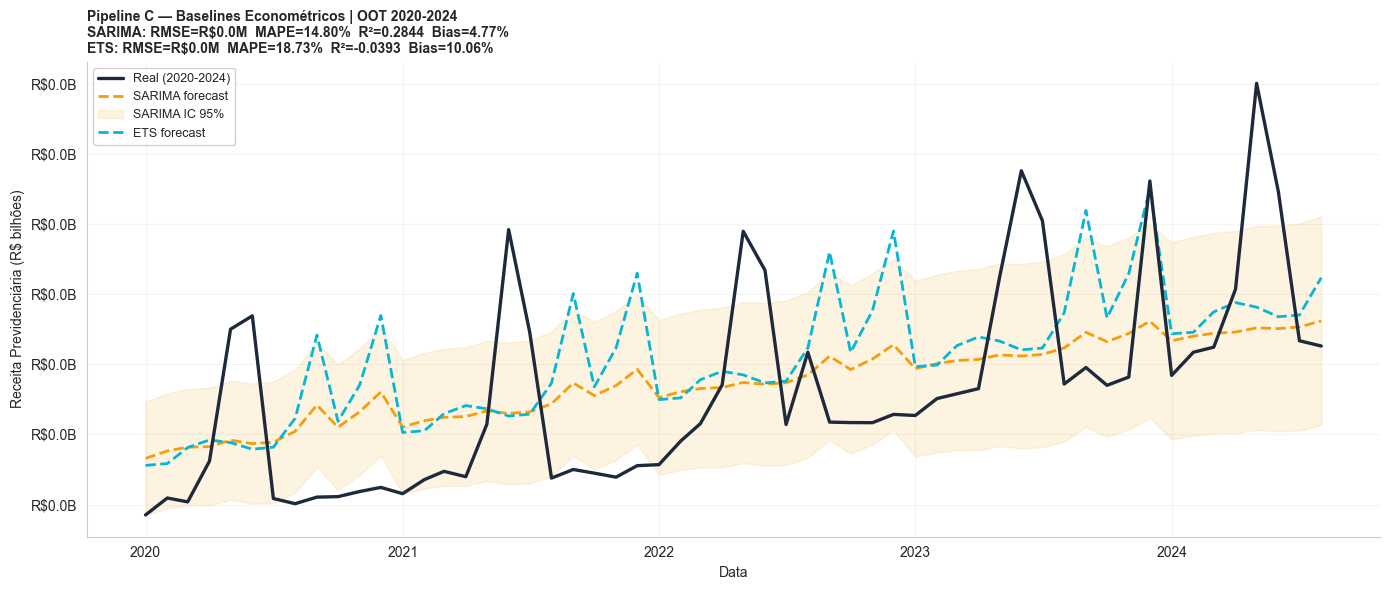

[SAVED] master_results/pC_baselines_oot_2020_2024.png


In [52]:
# === Nova Célula: C-3 — Visualização Pipeline C ===
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  PIPELINE C — Gráfico Comparativo OOT (2020-2024)                  ║
# ╚══════════════════════════════════════════════════════════════════════╝

def plot_pipeline_c(df: pd.DataFrame, results: dict):
    """
    Plota: valores reais 2020-2024 vs SARIMA vs ETS.
    Métricas RMSE / MAPE / R² / Bias inseridas no título.
    Intervalo de confiança 95% exibido para SARIMA (quando disponível).
    """
    if not results or not results.get("results"):
        print("[SKIP] Sem resultados de Pipeline C para plotar.")
        return

    inner = results["results"]
    if not inner:
        print("[SKIP] Dicionário de resultados vazio.")
        return

    ref_key   = next(iter(inner))
    dates_oot = inner[ref_key]["dates_oot"].reset_index(drop=True)
    real_oot  = inner[ref_key]["real_oot"]

    COLORS = {"SARIMA": "#f59e0b", "ETS": "#06b6d4"}
    fig, ax = plt.subplots(figsize=(14, 6))

    # ── Série real ───────────────────────────────────────────────────
    ax.plot(dates_oot, real_oot / 1e9, color="#1e293b", linewidth=2.4,
            label="Real (2020-2024)", zorder=5)

    metric_lines = []
    for name, r in inner.items():
        color = COLORS.get(name, "#a855f7")
        pred  = r["pred_oot"]
        ax.plot(dates_oot, pred / 1e9, color=color, linewidth=2.0,
                linestyle="--", label=f"{name} forecast", zorder=4)

        # IC 95% apenas para SARIMA
        if name == "SARIMA" and "conf_int_oot" in r:
            ci = r["conf_int_oot"]
            ax.fill_between(dates_oot,
                            ci[:, 0] / 1e9,
                            ci[:, 1] / 1e9,
                            color=color, alpha=0.12, label="SARIMA IC 95%")

        m = r["metrics_oot"]
        metric_lines.append(
            f"{name}: RMSE=R${m['RMSE']/1e6:,.1f}M  "
            f"MAPE={m['MAPE_%']:.2f}%  "
            f"R\u00b2={m['R2']:.4f}  "
            f"Bias={m['Bias_%']:.2f}%"
        )

    # ── Formatação ───────────────────────────────────────────────────
    title_body = "\n".join(metric_lines)
    ax.set_title(
        f"Pipeline C — Baselines Econométricos | OOT 2020-2024\n{title_body}",
        fontsize=10, fontweight="bold", loc="left",
    )
    ax.set_xlabel("Data", fontsize=10)
    ax.set_ylabel("Receita Previdenciária (R$ bilhões)", fontsize=10)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"R${x:.1f}B")
    )
    ax.legend(fontsize=9, loc="upper left", framealpha=0.9)
    ax.grid(True, alpha=0.2)
    sns.despine(ax=ax, right=True, top=True)
    plt.tight_layout()

    os.makedirs("master_results", exist_ok=True)
    fname = "master_results/pC_baselines_oot_2020_2024.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {fname}")


if pipeline_c_results:
    plot_pipeline_c(df, pipeline_c_results)


In [53]:
# === Nova Célula: C-4 — Tabela Comparativa Pipeline C ===
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  PIPELINE C — Tabela comparativa (mesmos campos do Cell 22)         ║
# ║  Popula `_pipeline_c_summary_rows` para injeção no Cell 22.         ║
# ╚══════════════════════════════════════════════════════════════════════╝

_pipeline_c_summary_rows = []   # compartilhado com Cell 22

if pipeline_c_results and pipeline_c_results.get("results"):
    rows_c = []
    for name, r in pipeline_c_results["results"].items():
        for split_key, split_label in [
            ("metrics_test", "Teste 2017-2019"),
            ("metrics_oot",  "OOT 2020-2024"),
        ]:
            m = r[split_key]
            rows_c.append({
                "Pipeline":  "C — Baselines",
                "Scaler":    "—",
                "Transform": split_label,
                "Model":     name,
                "R2":        round(m["R2"],     4),
                "RMSE":      round(m["RMSE"],   0),
                "MAE":       round(m["MAE"],    0),
                "MAPE_%":    round(m["MAPE_%"], 2),
                "Bias_%":    round(m["Bias_%"], 2),
            })

    df_c_summary = (
        pd.DataFrame(rows_c)
        .sort_values(["Transform", "R2"], ascending=[True, False])
        .reset_index(drop=True)
    )

    print(f"\n  PIPELINE C — TABELA COMPARATIVA (Teste 2017-2019 + OOT 2020-2024)")
    print(f"  {'─'*95}")
    print(df_c_summary.to_string(index=False))
    print(f"  {'─'*95}")

    # ── Exportar Excel ────────────────────────────────────────────────
    os.makedirs("master_results", exist_ok=True)
    out_path = "master_results/pipeline_c_baselines.xlsx"
    df_c_summary.to_excel(out_path, index=False)
    print(f"[SAVED] {out_path}")

    # ── Registrar para injeção no Cell 22 ────────────────────────────
    # Apenas entradas OOT entram na tabela global (período equivalente
    # ao que pipelines A/B avaliam como out-of-sample).
    _pipeline_c_summary_rows = [r for r in rows_c
                                 if r["Transform"] == "OOT 2020-2024"]
    print(f"[OK] {len(_pipeline_c_summary_rows)} entradas OOT prontas "
          f"para o Cell 22 (_pipeline_c_summary_rows).")
else:
    print("[SKIP] Sem resultados de Pipeline C para tabular.")



  PIPELINE C — TABELA COMPARATIVA (Teste 2017-2019 + OOT 2020-2024)
  ───────────────────────────────────────────────────────────────────────────────────────────────
     Pipeline Scaler       Transform  Model      R2    RMSE     MAE  MAPE_%  Bias_%
C — Baselines      —   OOT 2020-2024 SARIMA  0.2844 12071.0  9998.0   14.80    4.77
C — Baselines      —   OOT 2020-2024    ETS -0.0393 14547.0 12177.0   18.73   10.06
C — Baselines      — Teste 2017-2019    ETS  0.6647  3926.0  3245.0    6.67    5.87
C — Baselines      — Teste 2017-2019 SARIMA  0.5345  4626.0  4078.0    8.31    5.17
  ───────────────────────────────────────────────────────────────────────────────────────────────
[SAVED] master_results/pipeline_c_baselines.xlsx
[OK] 2 entradas OOT prontas para o Cell 22 (_pipeline_c_summary_rows).


---
## Etapa 4

### Ablation Study — Pipeline A

> Varredura sistemática de **27 combinações** (3 transformações × 3 scalers × 3 window sizes).
> Para cada combinação treina o walk-forward do Ensemble (GRU + LSTM + GBRT)
> com splits fixos e coleta métricas OOT 2020-2024.
>
> | Fator         | Níveis                                    |
> |---------------|-------------------------------------------|
> | Transformação | sazonal_lag12, log_retorno, fracdiff      |
> | Scaler        | MinMaxScaler, StandardScaler, RobustScaler |
> | Window Size   | 6, 12, 18                                 |
>
> `epochs_max=80`, `patience=10` para execução mais rápida.



██████████████████████████████████████████████████████████████████████
  ABLATION STUDY — Pipeline A (Ensemble: GRU + LSTM + GBRT)
  27 combinações: 3 transforms × 3 scalers × 3 windows
  epochs_max=80  patience=10  (modo rápido)
  Métrica alvo: OOT Ensemble 2020-2024 (1-step real feedback)
██████████████████████████████████████████████████████████████████████


Ablation:   0%|                                             | 0/27 [00:00<?, ?combo/s, Seasonal Lag | MinMaxScal | w=6]


  [Seasonal Lag-12]  val_end=2016-12  test_end=2019-12  oot_end=2024-08  window=6  scaler=MinMaxScaler
  [OK] Initial fit on 161 months (through 2016-12)
  Test (2017-2019):  Ens  R²=0.8566  MAPE=4.58%  RMSE=R$2,568
  ↺ OOT-1s refit at 2021-01  (step 12)
  ↺ OOT-1s refit at 2022-01  (step 24)
  ↺ OOT-1s refit at 2023-01  (step 36)
  ↺ OOT-1s refit at 2024-01  (step 48)
  OOT 1-step (2020-2024):  Ens  R²=0.3504  MAPE=11.63%
  [OK] Multi-step fit on 197 months (through 2019-12)


Ablation:   4%|█▏                               | 1/27 [05:26<2:21:16, 326.04s/combo, Seasonal Lag | MinMaxScal | w=12]

  OOT multi-step: Ens  R²=-0.1014  MAPE=16.93%
  ✓ Seasonal Lag | MinMaxScal | w=6  R²=0.3504  MAPE=11.63%  (5.4 min)

  [Seasonal Lag-12]  val_end=2016-12  test_end=2019-12  oot_end=2024-08  window=12  scaler=MinMaxScaler
  [OK] Initial fit on 161 months (through 2016-12)
  Test (2017-2019):  Ens  R²=0.8791  MAPE=4.17%  RMSE=R$2,358
  ↺ OOT-1s refit at 2021-01  (step 12)
  ↺ OOT-1s refit at 2022-01  (step 24)
  ↺ OOT-1s refit at 2023-01  (step 36)
  ↺ OOT-1s refit at 2024-01  (step 48)
  OOT 1-step (2020-2024):  Ens  R²=0.3832  MAPE=11.52%
  [OK] Multi-step fit on 197 months (through 2019-12)


...

  OOT multi-step: Ens  R²=0.3430  MAPE=14.63%
  ✓ Frac-Diff (d | RobustScal | w=6  R²=0.2695  MAPE=11.20%  (119.3 min)

  [Frac-Diff (d=0.4)]  val_end=2016-12  test_end=2019-12  oot_end=2024-08  window=12  scaler=RobustScaler
  [OK] Initial fit on 161 months (through 2016-12)
  Test (2017-2019):  Ens  R²=0.3904  MAPE=7.47%  RMSE=R$5,294
  ↺ OOT-1s refit at 2021-01  (step 12)
  ↺ OOT-1s refit at 2022-01  (step 24)
  ↺ OOT-1s refit at 2023-01  (step 36)
  ↺ OOT-1s refit at 2024-01  (step 48)
  OOT 1-step (2020-2024):  Ens  R²=0.3822  MAPE=9.87%
  [OK] Multi-step fit on 197 months (through 2019-12)


Ablation:  96%|██████████████████████████████▊ | 26/27 [2:05:15<05:52, 352.15s/combo, Frac-Diff (d | RobustScal | w=18]

  OOT multi-step: Ens  R²=-0.0891  MAPE=13.07%
  ✓ Frac-Diff (d | RobustScal | w=12  R²=0.3822  MAPE=9.87%  (125.3 min)

  [Frac-Diff (d=0.4)]  val_end=2016-12  test_end=2019-12  oot_end=2024-08  window=18  scaler=RobustScaler
  [OK] Initial fit on 161 months (through 2016-12)
  Test (2017-2019):  Ens  R²=0.3096  MAPE=8.22%  RMSE=R$5,634
  ↺ OOT-1s refit at 2021-01  (step 12)
  ↺ OOT-1s refit at 2022-01  (step 24)
  ↺ OOT-1s refit at 2023-01  (step 36)
  ↺ OOT-1s refit at 2024-01  (step 48)
  OOT 1-step (2020-2024):  Ens  R²=0.3882  MAPE=9.87%
  [OK] Multi-step fit on 197 months (through 2019-12)


Ablation: 100%|████████████████████████████████| 27/27 [2:11:18<00:00, 291.81s/combo, Frac-Diff (d | RobustScal | w=18]

  OOT multi-step: Ens  R²=0.2298  MAPE=16.15%
  ✓ Frac-Diff (d | RobustScal | w=18  R²=0.3882  MAPE=9.87%  (131.3 min)

  [RESTORED] SCALER_TYPE='MinMaxScaler'  WINDOW_SIZE=12  TRANSFORMATIONS=['sazonal_lag12', 'log_retorno', 'fracdiff']

  [DONE] 27/27 combinações OK em 131.3 min (7879s)
  ⏱  Ablation Study — Pipeline A: 7879.0s (131.32 min)
[SAVED] master_results/ablation_study.csv  (27 rows)


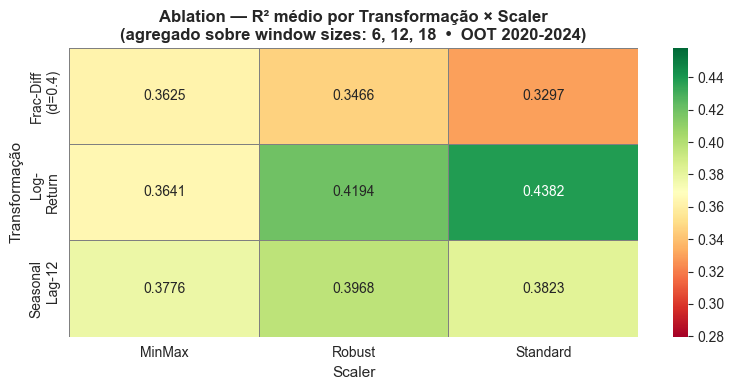

[SAVED] master_results/ablation_heatmap_r2.png


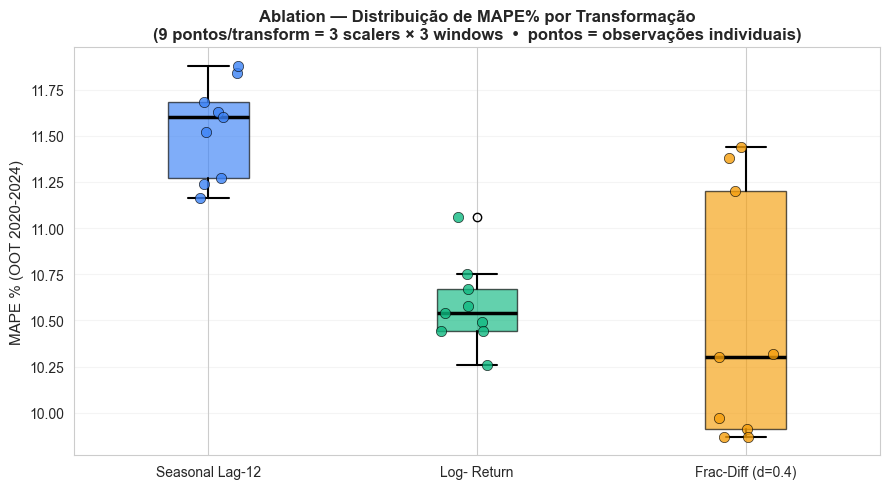

[SAVED] master_results/ablation_boxplot_mape.png

════════════════════════════════════════════════════════════════════════
  ABLATION — TOP 5 COMBINAÇÕES (por R²  •  OOT 2020-2024)
════════════════════════════════════════════════════════════════════════
 Rank       Transform         scaler  window     R2    RMSE    MAE  MAPE
    1     Log- Return StandardScaler      18 0.4884 10206.0 7487.0 10.54
    2     Log- Return   RobustScaler      18 0.4733 10356.0 7331.0 10.44
    3 Seasonal Lag-12   RobustScaler      18 0.4255 10816.0 7631.0 11.16
    4     Log- Return StandardScaler       6 0.4237 10833.0 7540.0 10.49
    5     Log- Return   RobustScaler       6 0.4229 10840.0 7690.0 10.75

════════════════════════════════════════════════════════════════════════
  ABLATION — BOTTOM 5 COMBINAÇÕES (por R²)
════════════════════════════════════════════════════════════════════════
 Rank         Transform         scaler  window     R2    RMSE    MAE  MAPE
   23   Seasonal Lag-12   MinMaxScaler     

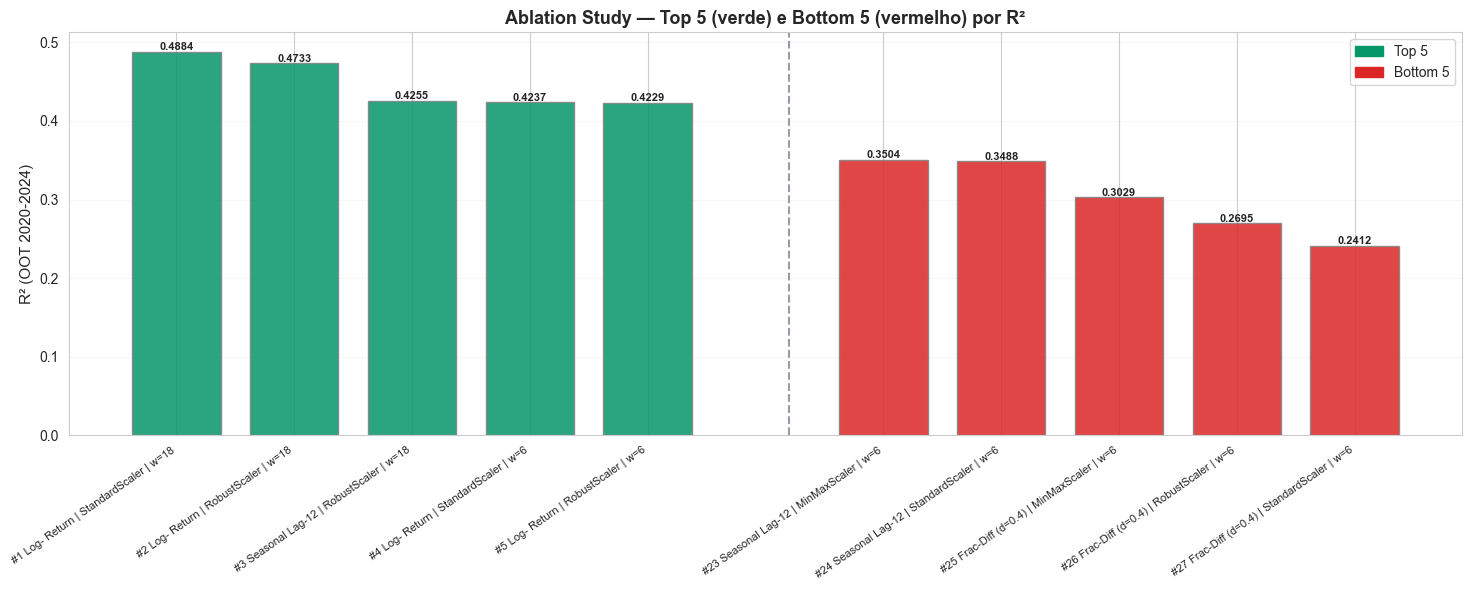

[SAVED] master_results/ablation_top_bottom5.png

────────────────────────────────────────────────────────────────────────
  MELHOR CONFIGURAÇÃO  →  Log- Return | StandardScaler | window=18
  R²=0.4884   MAPE=10.54%   RMSE=R$10,206
────────────────────────────────────────────────────────────────────────
  Para usar como padrão, edite Cell 2:
    SCALER_TYPE     = "StandardScaler"
    WINDOW_SIZE     = 18
    TRANSFORMATIONS = ["log_retorno"]


In [54]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  ABLATION STUDY — Pipeline A                                         ║
# ║  27 combos: 3 transforms × 3 scalers × 3 window sizes               ║
# ╚══════════════════════════════════════════════════════════════════════╝

import itertools, time
try:
    from tqdm.auto import tqdm as _tqdm
except ImportError:
    def _tqdm(it, **kw): return it   # silent fallback if tqdm not installed

_ABLATION_TRANSFORMS = ["sazonal_lag12", "log_retorno", "fracdiff"]
_ABLATION_SCALERS    = ["MinMaxScaler", "StandardScaler", "RobustScaler"]
_ABLATION_WINDOWS    = [6, 12, 18]

_ABLATION_TRANSFORM_LABELS = {
    "sazonal_lag12": "Seasonal\nLag-12",
    "log_retorno":   "Log-\nReturn",
    "fracdiff":      f"Frac-Diff\n(d={FRAC_DIFF_D})",
}
_ABLATION_SCALER_LABELS = {
    "MinMaxScaler":   "MinMax",
    "StandardScaler": "Standard",
    "RobustScaler":   "Robust",
}


def run_ablation(df_raw: pd.DataFrame) -> pd.DataFrame:
    # Run 27-combo ablation study for Pipeline A.
    #
    # Temporarily overrides SCALER_TYPE, WINDOW_SIZE, TRANSFORMATIONS, and
    # TRAIN_CONFIG in the global namespace for each combination, then
    # restores them all in a finally block — globals are never permanently
    # modified.
    #
    # For speed: epochs_max=80, patience=10 (vs. normal 150/15).
    #
    # Returns pd.DataFrame with columns:
    #   transform, scaler, window, R2, RMSE, MAE, MAPE
    global SCALER_TYPE, WINDOW_SIZE, TRANSFORMATIONS, TRAIN_CONFIG

    if not TF_AVAILABLE:
        print("[SKIP] TensorFlow not available — ablation requires Pipeline A.")
        return pd.DataFrame()

    # ── Save all globals that will be modified ────────────────────────
    _orig_scaler     = SCALER_TYPE
    _orig_window     = WINDOW_SIZE
    _orig_transforms = list(TRANSFORMATIONS)
    _orig_train_cfg  = dict(TRAIN_CONFIG)

    combos = list(itertools.product(
        _ABLATION_TRANSFORMS, _ABLATION_SCALERS, _ABLATION_WINDOWS))

    print(f"\n{'█'*70}")
    print(f"  ABLATION STUDY — Pipeline A (Ensemble: GRU + LSTM + GBRT)")
    print(f"  {len(combos)} combinações: "
          f"{len(_ABLATION_TRANSFORMS)} transforms × "
          f"{len(_ABLATION_SCALERS)} scalers × "
          f"{len(_ABLATION_WINDOWS)} windows")
    print(f"  epochs_max=80  patience=10  (modo rápido)")
    print(f"  Métrica alvo: OOT Ensemble 2020-2024 (1-step real feedback)")
    print(f"{'█'*70}")

    rows  = []
    fails = 0
    t0    = time.time()

    try:
        # Reduce training budget globally for all combos
        TRAIN_CONFIG = {**_orig_train_cfg, "epochs_max": 80, "patience": 10}

        pbar = _tqdm(combos, desc="Ablation", unit="combo")
        for transform, scaler, window in pbar:
            combo_label = (
                f"{_LABEL_MAP.get(transform, transform)[:12]:12s} | "
                f"{scaler[:10]:10s} | w={window}"
            )
            try:
                pbar.set_postfix_str(combo_label)
            except Exception:
                pass

            # ── Override globals for this combination ─────────────────
            SCALER_TYPE     = scaler
            WINDOW_SIZE     = window
            TRANSFORMATIONS = [transform]

            try:
                res   = walk_forward_fixed(df_raw, transform)
                oot_m = res.get("oot_1s_metrics", {}).get("Ensemble", {})
                if not oot_m:
                    oot_m = res.get("test_metrics", {}).get("Ensemble", {})

                row = dict(
                    transform=transform,
                    scaler=scaler,
                    window=window,
                    R2=round(oot_m.get("R2",      float("nan")), 4),
                    RMSE=round(oot_m.get("RMSE",   float("nan")), 0),
                    MAE=round(oot_m.get("MAE",     float("nan")), 0),
                    MAPE=round(oot_m.get("MAPE_%", float("nan")), 2),
                )
                elapsed = time.time() - t0
                print(f"  ✓ {combo_label}  "
                      f"R²={row['R2']:.4f}  "
                      f"MAPE={row['MAPE']:.2f}%  "
                      f"({elapsed/60:.1f} min)")

            except Exception as exc:
                fails += 1
                print(f"  ✗ {combo_label}  [FAIL] {exc}")
                row = dict(
                    transform=transform, scaler=scaler, window=window,
                    R2=float("nan"), RMSE=float("nan"),
                    MAE=float("nan"), MAPE=float("nan"),
                )

            rows.append(row)

    finally:
        # ── Always restore globals, even after exception ───────────────
        SCALER_TYPE     = _orig_scaler
        WINDOW_SIZE     = _orig_window
        TRANSFORMATIONS = _orig_transforms
        TRAIN_CONFIG    = _orig_train_cfg
        print(f"\n  [RESTORED] SCALER_TYPE={SCALER_TYPE!r}  "
              f"WINDOW_SIZE={WINDOW_SIZE}  "
              f"TRANSFORMATIONS={TRANSFORMATIONS}")

    total = time.time() - t0
    ok_n  = len(rows) - fails
    print(f"\n  [DONE] {ok_n}/{len(rows)} combinações OK em "
          f"{total/60:.1f} min ({total:.0f}s)")
    if fails:
        print(f"  [WARN] {fails} combinações falharam — veja logs acima.")

    return pd.DataFrame(rows)


# ── RUN ───────────────────────────────────────────────────────────────
with _pipeline_timer("Ablation Study — Pipeline A"):
    df_ablation = run_ablation(df)

# ── EXPORT ────────────────────────────────────────────────────────────
if len(df_ablation) > 0:
    import os; os.makedirs("master_results", exist_ok=True)
    df_ablation.to_csv("master_results/ablation_study.csv", index=False)
    print(f"[SAVED] master_results/ablation_study.csv  ({len(df_ablation)} rows)")


# ══════════════════════════════════════════════════════════════════════
#  VISUALIZAÇÕES
# ══════════════════════════════════════════════════════════════════════
if len(df_ablation) > 0 and df_ablation["R2"].notna().any():
    import os; os.makedirs("master_results", exist_ok=True)

    # ── (a) Heatmap: R² médio por (transformação × scaler) ───────────
    pivot_r2 = (
        df_ablation
        .groupby(["transform", "scaler"])["R2"]
        .mean()
        .unstack(level="scaler")
    )
    pivot_r2.index   = [_ABLATION_TRANSFORM_LABELS.get(t, t)
                        for t in pivot_r2.index]
    pivot_r2.columns = [_ABLATION_SCALER_LABELS.get(s, s)
                        for s in pivot_r2.columns]

    _valid_vals = pivot_r2.values[~np.isnan(pivot_r2.values)]
    _vmin = float(_valid_vals.min()) - 0.05 if len(_valid_vals) else 0.0
    _vmax = min(1.0, float(_valid_vals.max()) + 0.02) if len(_valid_vals) else 1.0

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(
        pivot_r2, annot=True, fmt=".4f", cmap="RdYlGn",
        linewidths=0.5, linecolor="gray",
        vmin=_vmin, vmax=_vmax,
        annot_kws={"size": 10}, ax=ax,
    )
    ax.set_title(
        "Ablation — R² médio por Transformação × Scaler\n"
        "(agregado sobre window sizes: 6, 12, 18  •  OOT 2020-2024)",
        fontsize=12, fontweight="bold",
    )
    ax.set_xlabel("Scaler", fontsize=11)
    ax.set_ylabel("Transformação", fontsize=11)
    plt.tight_layout()
    _fname_hm = "master_results/ablation_heatmap_r2.png"
    plt.savefig(_fname_hm, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {_fname_hm}")

    # ── (b) Boxplot: MAPE% por transformação ─────────────────────────
    _bp_data   = [
        df_ablation.loc[df_ablation["transform"] == t, "MAPE"].dropna().values
        for t in _ABLATION_TRANSFORMS
    ]
    _bp_labels = [
        _ABLATION_TRANSFORM_LABELS[t].replace("\n", " ")
        for t in _ABLATION_TRANSFORMS
    ]
    _bp_colors = ["#3B82F6", "#10B981", "#F59E0B"]

    fig, ax = plt.subplots(figsize=(9, 5))
    bp = ax.boxplot(
        _bp_data, labels=_bp_labels, patch_artist=True,
        medianprops=dict(color="black", lw=2.5),
        whiskerprops=dict(lw=1.5),
        capprops=dict(lw=1.5),
    )
    for patch, color in zip(bp["boxes"], _bp_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    # Overlay individual points with jitter
    np.random.seed(SEED)
    for i, (t, color) in enumerate(zip(_ABLATION_TRANSFORMS, _bp_colors)):
        vals = df_ablation.loc[df_ablation["transform"] == t, "MAPE"].dropna().values
        if len(vals):
            jitter = np.random.normal(0, 0.07, size=len(vals))
            ax.scatter(i + 1 + jitter, vals,
                       color=color, edgecolors="black", linewidths=0.5,
                       s=55, zorder=4, alpha=0.8)

    ax.set_ylabel("MAPE % (OOT 2020-2024)", fontsize=11)
    ax.set_title(
        "Ablation — Distribuição de MAPE% por Transformação\n"
        "(9 pontos/transform = 3 scalers × 3 windows  •  pontos = observações individuais)",
        fontsize=12, fontweight="bold",
    )
    ax.grid(True, alpha=0.2, axis="y")
    plt.tight_layout()
    _fname_bp = "master_results/ablation_boxplot_mape.png"
    plt.savefig(_fname_bp, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {_fname_bp}")

    # ── (c) Top 5 / Bottom 5 rankeados por R² ────────────────────────
    df_ranked = (
        df_ablation.dropna(subset=["R2"])
        .sort_values("R2", ascending=False)
        .reset_index(drop=True)
    )
    df_ranked["Rank"]      = df_ranked.index + 1
    df_ranked["Transform"] = (
        df_ranked["transform"]
        .map(_ABLATION_TRANSFORM_LABELS)
        .str.replace("\n", " ")
    )

    top5    = df_ranked.head(5).copy()
    bottom5 = df_ranked.tail(5).copy()
    _dcols  = ["Rank", "Transform", "scaler", "window", "R2", "RMSE", "MAE", "MAPE"]

    print("\n" + "═"*72)
    print("  ABLATION — TOP 5 COMBINAÇÕES (por R²  •  OOT 2020-2024)")
    print("═"*72)
    print(top5[_dcols].to_string(index=False))

    print("\n" + "═"*72)
    print("  ABLATION — BOTTOM 5 COMBINAÇÕES (por R²)")
    print("═"*72)
    print(bottom5[_dcols].to_string(index=False))

    # Combined bar chart (top5 green + bottom5 red, divider in between)
    _top_lbl = [
        f"#{r['Rank']} {r['Transform'].strip()} | {r['scaler']} | w={r['window']}"
        for _, r in top5.iterrows()
    ]
    _bot_lbl = [
        f"#{r['Rank']} {r['Transform'].strip()} | {r['scaler']} | w={r['window']}"
        for _, r in bottom5.iterrows()
    ]

    # Build x-positions with a visual gap between top5 and bottom5
    _xs, _hs, _cs, _xlabels = [], [], [], []
    for i, (lbl, val) in enumerate(zip(_top_lbl, top5["R2"])):
        _xs.append(i); _hs.append(val); _cs.append("#059669"); _xlabels.append(lbl)
    for i, (lbl, val) in enumerate(zip(_bot_lbl, bottom5["R2"])):
        _xs.append(6 + i); _hs.append(val); _cs.append("#DC2626"); _xlabels.append(lbl)

    fig, ax = plt.subplots(figsize=(15, 6))
    bars = ax.bar(_xs, _hs, color=_cs, edgecolor="gray", alpha=0.85, width=0.75)
    ax.axvline(5.2, color="#6B7280", lw=1.5, ls="--", alpha=0.7)
    ax.set_xticks(_xs)
    ax.set_xticklabels(_xlabels, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("R² (OOT 2020-2024)", fontsize=11)
    ax.set_title("Ablation Study — Top 5 (verde) e Bottom 5 (vermelho) por R²",
                 fontsize=13, fontweight="bold")
    ax.grid(True, alpha=0.15, axis="y")
    for bar, val in zip(bars, _hs):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.002,
                    f"{val:.4f}", ha="center", fontsize=8, fontweight="bold")
    ax.legend(handles=[
        mpatches.Patch(color="#059669", label="Top 5"),
        mpatches.Patch(color="#DC2626", label="Bottom 5"),
    ], fontsize=10)
    plt.tight_layout()
    _fname_rank = "master_results/ablation_top_bottom5.png"
    plt.savefig(_fname_rank, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {_fname_rank}")

    # ── Best configuration hint ───────────────────────────────────────
    _best = df_ranked.iloc[0]
    print(f"\n{'─'*72}")
    print(f"  MELHOR CONFIGURAÇÃO  →  {_best['Transform'].strip()} | "
          f"{_best['scaler']} | window={int(_best['window'])}")
    print(f"  R²={_best['R2']:.4f}   MAPE={_best['MAPE']:.2f}%   "
          f"RMSE=R${_best['RMSE']:,.0f}")
    print(f"{'─'*72}")
    print(f"  Para usar como padrão, edite Cell 2:")
    print(f"    SCALER_TYPE     = \"{_best['scaler']}\"")
    print(f"    WINDOW_SIZE     = {int(_best['window'])}")
    print(f"    TRANSFORMATIONS = [\"{_best['transform']}\"]")

else:
    print("[INFO] df_ablation vazio ou sem resultados válidos.")


---
## Etapa 5

### Comparative Analysis
> **Workflow:** Run all cells with `SCALER_TYPE = "MinMaxScaler"`, export results.
> Then change to `SCALER_TYPE = "StandardScaler"` and re-run. Compare the two summary tables below.



  COMPARATIVE SUMMARY  [Scaler = MinMaxScaler]
     Pipeline       Scaler                          Transform     Model      R2    RMSE     MAE  MAPE_%  Bias_%
 A — Ensemble MinMaxScaler        Log-Return [Test 2017-2019]      GBRT  0.8795  2354.0  1875.0    3.86   -0.25
 A — Ensemble MinMaxScaler   Seasonal Lag-12 [Test 2017-2019]  Ensemble  0.8388  2723.0  2408.0    4.96    4.21
 A — Ensemble MinMaxScaler   Seasonal Lag-12 [Test 2017-2019]      LSTM  0.8370  2737.0  2389.0    4.87    4.40
 A — Ensemble MinMaxScaler   Seasonal Lag-12 [Test 2017-2019]      GBRT  0.7993  3038.0  2582.0    5.36    3.11
 A — Ensemble MinMaxScaler   Seasonal Lag-12 [Test 2017-2019]       GRU  0.7968  3057.0  2720.0    5.53    5.12
 A — Ensemble MinMaxScaler Frac-Diff (d=0.4) [Test 2017-2019]      GBRT  0.6943  3749.0  2611.0    4.89   -1.47
 A — Ensemble MinMaxScaler        Log-Return [Test 2017-2019]  Ensemble  0.4415  5067.0  3980.0    7.90    1.00
 A — Ensemble MinMaxScaler    Seasonal Lag-12 [OOT 2020-

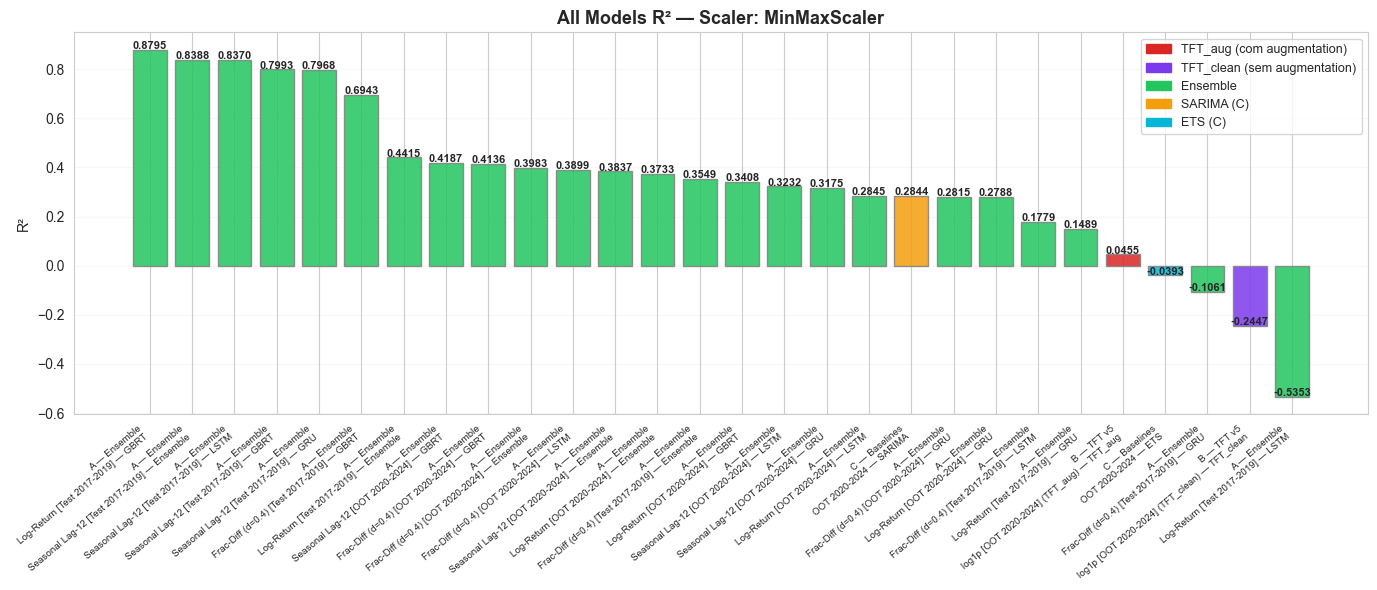

[SAVED] master_results/comparative_r2_MinMaxScaler.png


In [55]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  COMPARATIVE ANALYSIS — Unified Summary Table                       ║
# ╚══════════════════════════════════════════════════════════════════════╝

summary_rows = []

# ── Pipeline A entries ────────────────────────────────────────────────
if pipeline_a_results:
    for period_key, metrics_dict in [
        ("Test 2017-2019",  pipeline_a_results.get("metrics", {})),
        ("OOT 2020-2024",   pipeline_a_results.get("oot_metrics", {})),
    ]:
        for key, m in metrics_dict.items():
            parts = key.rsplit("_", 1)
            modo_label = _LABEL_MAP.get(parts[0], parts[0])
            summary_rows.append({
                "Pipeline":   "A — Ensemble",
                "Scaler":     SCALER_TYPE,
                "Transform":  f"{modo_label} [{period_key}]",
                "Model":      parts[1] if len(parts) > 1 else "—",
                "R2":         round(m["R2"], 4),
                "RMSE":       round(m["RMSE"], 0),
                "MAE":        round(m["MAE"], 0),
                "MAPE_%":     round(m["MAPE_%"], 2),
                "Bias_%":     round(m["Bias_%"], 2),
            })

# ── Pipeline B entries — both augmentation variants ───────────────────
_tft_variant_labels = {
    "with_aug":    "TFT_aug",
    "without_aug": "TFT_clean",
}
for variant_key, variant_label in _tft_variant_labels.items():
    variant_res = pipeline_b_results.get(variant_key, {}) if pipeline_b_results else {}
    if not variant_res:
        continue
    m = variant_res.get("final_metrics", {})
    if not m:
        continue
    summary_rows.append({
        "Pipeline":   "B — TFT v5",
        "Scaler":     SCALER_TYPE,
        "Transform":  f"log1p [OOT 2020-2024] ({variant_label})",
        "Model":      variant_label,
        "R2":         round(m["R2"], 4),
        "RMSE":       round(m["RMSE"], 0),
        "MAE":        round(m["MAE"], 0),
        "MAPE_%":     round(m["MAPE_%"], 2),
        "Bias_%":     round(m.get("Bias_%", float("nan")), 2),
    })

# ── Pipeline C entries (baselines SARIMA / ETS) ───────────────────────
if _pipeline_c_summary_rows:
    for _row_c in _pipeline_c_summary_rows:
        summary_rows.append(_row_c)

if summary_rows:
    df_summary = pd.DataFrame(summary_rows)
    df_summary = df_summary.sort_values("R2", ascending=False).reset_index(drop=True)
    print(f"\n  COMPARATIVE SUMMARY  [Scaler = {SCALER_TYPE}]")
    print(df_summary.to_string(index=False))

    # Save to Excel for cross-run comparison
    out_excel = f"master_results/comparative_{SCALER_TYPE}.xlsx"
    import os; os.makedirs("master_results", exist_ok=True)
    df_summary.to_excel(out_excel, index=False)
    print(f"\n[SAVED] {out_excel}")

    # Bar chart — R² comparison
    fig, ax = plt.subplots(figsize=(14, 6))
    labels = [f"{r['Pipeline']}\n{r['Transform']} — {r['Model']}"
              for _, r in df_summary.iterrows()]
    r2_vals = df_summary["R2"].values
    bar_colors = [
        "#DC2626" if "TFT_aug"   in l else
        "#7C3AED" if "TFT_clean" in l else
        "#22c55e" if "Ensemble"  in l else
        "#f59e0b" if "SARIMA"    in l else
        "#06b6d4" if "ETS"       in l else
        "#64748b" for l in labels
    ]
    bars = ax.bar(range(len(labels)), r2_vals, color=bar_colors,
                  edgecolor="gray", alpha=0.85)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=7, rotation=40, ha="right")
    ax.set_ylabel("R²")
    ax.set_title(f"All Models R² — Scaler: {SCALER_TYPE}",
                 fontsize=13, fontweight="bold")
    ax.grid(True, alpha=0.15, axis="y")
    for bar, val in zip(bars, r2_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.4f}", ha="center", fontsize=8, fontweight="bold")
    legend_elements = [
        mpatches.Patch(color="#DC2626", label="TFT_aug (com augmentation)"),
        mpatches.Patch(color="#7C3AED", label="TFT_clean (sem augmentation)"),
        mpatches.Patch(color="#22c55e", label="Ensemble"),
        mpatches.Patch(color="#f59e0b", label="SARIMA (C)"),
        mpatches.Patch(color="#06b6d4", label="ETS (C)"),
    ]
    ax.legend(handles=legend_elements, fontsize=9)
    plt.tight_layout()
    fname_cmp = f"master_results/comparative_r2_{SCALER_TYPE}.png"
    plt.savefig(fname_cmp, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {fname_cmp}")
else:
    print("No pipeline results available — check PIPELINES_TO_RUN.")


### Testes de Superioridade Preditiva — Diebold-Mariano

Teste formal de igualdade de poder preditivo entre todos os modelos do pipeline.  
Implementação do zero seguindo Diebold & Mariano (1995) com correção de amostra  
pequena de Harvey, Leybourne & Newbold (1997).

> **Referências:** Diebold & Mariano (1995, JBES); Harvey, Leybourne & Newbold (1997, IJF)



══════════════════════════════════════════════════════════════════════
  TESTES DE SUPERIORIDADE PREDITIVA — DIEBOLD-MARIANO
══════════════════════════════════════════════════════════════════════

  Agregando previsões OOT...
  [PA] 56 obs  |  modo=sazonal_lag12  |  ['GRU', 'LSTM', 'GBRT', 'Ensemble']
  [PC] 56 obs  |  SARIMA
  [PC] 56 obs  |  ETS

  Período OOT: Jan/2020 → Aug/2024  (56 observações)
  Modelos disponíveis: GRU, LSTM, GBRT, Ensemble, SARIMA, ETS

  9 pares — loss=MSE, h=1, HLN 1997

  ✗  Ensemble e SARIMA sem diferença significativa (DM=-0.637, p=0.5268)
  ✔  Ensemble supera ETS a 5%  (DM=-2.255, p=0.0281) **
  ✗  GRU e LSTM sem diferença significativa (DM=+0.430, p=0.6691)
  ✗  GRU e SARIMA sem diferença significativa (DM=-0.209, p=0.8355)
  ✗  LSTM e SARIMA sem diferença significativa (DM=-0.239, p=0.8123)
  ✗  GBRT e SARIMA sem diferença significativa (DM=-0.804, p=0.4246)
  ✔  GRU supera ETS a 10% (DM=-1.823, p=0.0737) *
  ✔  LSTM supera ETS a 10% (DM=-1.817, p=0.0

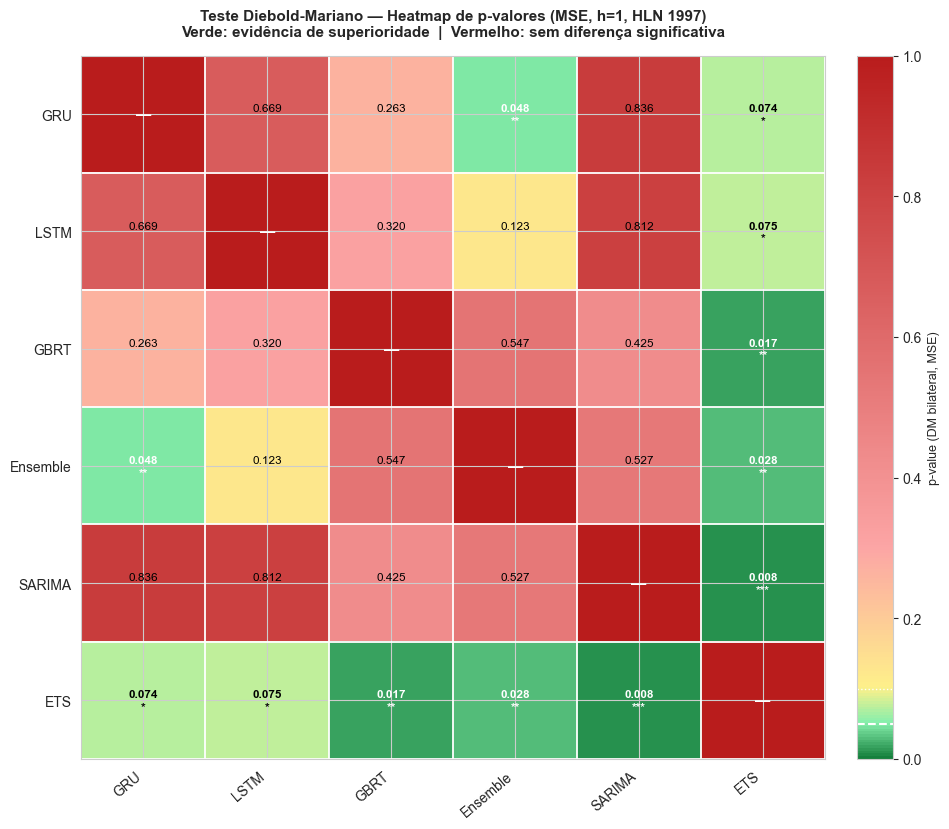

[SAVED] master_results/dm_heatmap.png

──────────────────────────────────────────────────────────────────────────────────────────
  ROBUSTEZ — DM por função de perda (pares centrais do artigo)
  Resultados consistentes entre MSE, MAE e MAPE reforçam a confiabilidade.
──────────────────────────────────────────────────────────────────────────────────────────
               Par DM(MSE)   p(MSE) DM(MAE)    p(MAE) DM(MAPE)   p(MAPE)
   Ensemble vs ETS  -2.255 0.0281**  -3.018 0.0038***   -3.381 0.0013***
Ensemble vs SARIMA  -0.637 0.5268ns  -1.912   0.0610*   -1.966   0.0543*
──────────────────────────────────────────────────────────────────────────────────────────
  Nota: *** p<0.01  ** p<0.05  * p<0.10  ns = não significativo
[SAVED] master_results/diebold_mariano_robustez.xlsx

[OK] Testes DM concluídos.  Arquivos em master_results/


In [56]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  TESTES DE SUPERIORIDADE PREDITIVA — Diebold-Mariano (DM, 1995)     ║
# ║  + Correção Harvey-Leybourne-Newbold (HLN, 1997) para N pequeno     ║
# ╚══════════════════════════════════════════════════════════════════════╝

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats


# ══════════════════════════════════════════════════════════════════════
# 1. FUNÇÃO GENÉRICA: diebold_mariano_test()
# ══════════════════════════════════════════════════════════════════════

def diebold_mariano_test(
    e1: np.ndarray,
    e2: np.ndarray,
    h: int = 1,
    loss: str = "MSE",
    y_real: np.ndarray = None,
) -> dict:
    """
    Teste Diebold-Mariano (1995) com correção Harvey-Leybourne-Newbold (1997).

    INTUIÇÃO PARA LEITORES NÃO-ESTATÍSTICOS:
    ─────────────────────────────────────────
    Para cada período t calcula-se a "perda" (custo do erro) de cada modelo.
    A série d_t = L(e1_t) − L(e2_t) mede quem errou mais a cada mês.
    Se d̄ = média(d_t) for significativamente ≠ 0 pelo teste-t, há evidência
    de que um modelo é sistematicamente superior ao outro.
    A variância de d̄ é estimada via Newey-West para acomodar autocorrelação
    induzida por previsões de horizonte h > 1.

    Parameters
    ----------
    e1, e2  : arrays de erros (real − predito) dos modelos 1 e 2, alinhados.
    h       : horizonte de previsão.
              h = 1  → 1-step-ahead (sem autocorrelação nos erros sob H0).
              h > 1  → multi-step; correção Newey-West de ordem h-1 aplicada.
    loss    : "MSE"  → L = e²
              "MAE"  → L = |e|
              "MAPE" → L = |e / y_real| × 100  (requer y_real)
    y_real  : valores reais (obrigatório apenas para loss="MAPE").

    Returns
    -------
    dict:
        "DM_stat"      — estatística DM (HLN-corrigida). Negativo → M1 melhor.
        "p_value"      — p-valor bilateral via t(N−1).
        "better_model" — "M1", "M2" ou "Empate estatístico".
        "n"            — número de observações usadas.
        "d_bar"        — diferença média de perda (sem normalizar).

    Hipóteses:
        H0: E[d_t] = 0  →  modelos igualmente precisos.
        H1: E[d_t] ≠ 0  →  um modelo é estatisticamente superior (bilateral).
    """
    e1 = np.asarray(e1, dtype=np.float64).flatten()
    e2 = np.asarray(e2, dtype=np.float64).flatten()
    n  = min(len(e1), len(e2))
    e1, e2 = e1[:n], e2[:n]

    # Remove observações com NaN/Inf em qualquer série
    mask = np.isfinite(e1) & np.isfinite(e2)
    yr_arr = None
    if y_real is not None:
        yr_arr = np.asarray(y_real, dtype=np.float64).flatten()[:n]
        mask  &= np.isfinite(yr_arr)
    e1, e2 = e1[mask], e2[mask]
    n = len(e1)

    _nan = {"DM_stat": np.nan, "p_value": np.nan,
            "better_model": "N/A", "n": n, "d_bar": np.nan}
    if n < 4:
        return _nan

    # ── Séries de perda ───────────────────────────────────────────────
    if loss == "MSE":
        L1, L2 = e1 ** 2, e2 ** 2
    elif loss == "MAE":
        L1, L2 = np.abs(e1), np.abs(e2)
    elif loss == "MAPE":
        if y_real is None:
            raise ValueError("loss='MAPE' requer o parâmetro y_real.")
        yr = yr_arr[mask]
        L1 = np.abs(e1 / (yr + 1e-10)) * 100
        L2 = np.abs(e2 / (yr + 1e-10)) * 100
    else:
        raise ValueError(f"loss deve ser 'MSE', 'MAE' ou 'MAPE'; recebeu {loss!r}.")

    # ── Série de diferenças de perda ──────────────────────────────────
    # d_t > 0 → M1 pior no período t  |  d_t < 0 → M1 melhor no período t
    d     = L1 - L2
    d_bar = float(np.mean(d))

    # ── Variância de d̄ via Newey-West (pesos de Bartlett) ────────────
    # Sob H0 com h-step-ahead, erros têm autocorrelação MA(h-1).
    # Truncamento em h-1 e pesos de Bartlett garantem estimador positivo.
    centered = d - d_bar
    gamma_0  = float(np.mean(centered ** 2))
    nw_sum   = 0.0
    for lag in range(1, h):
        weight  = 1.0 - lag / h          # peso de Bartlett
        gamma_k = float(np.mean(centered[lag:] * centered[:-lag]))
        nw_sum += weight * gamma_k
    var_d_bar = (gamma_0 + 2.0 * nw_sum) / n

    if var_d_bar <= 0.0:
        return _nan

    # ── Estatística DM bruta ──────────────────────────────────────────
    dm_raw = d_bar / np.sqrt(var_d_bar)

    # ── Correção HLN (Harvey, Leybourne & Newbold 1997, eq. 3) ───────
    # Fator: sqrt((N + 1 − 2h + h(h−1)/N) / N)
    # Ajusta a distribuição de dm_raw para uma t(N−1) em amostras finitas.
    hlb = np.sqrt(max((n + 1 - 2 * h + h * (h - 1) / n) / n, 1e-12))
    dm_stat = float(dm_raw * hlb)

    # ── p-valor bilateral via t(N−1) ──────────────────────────────────
    p_value = float(2.0 * stats.t.sf(abs(dm_stat), df=n - 1))

    # ── Determinação do modelo superior ──────────────────────────────
    if p_value < 0.10:
        better_model = "M1" if dm_stat < 0 else "M2"
    else:
        better_model = "Empate estatístico"

    return {
        "DM_stat":      dm_stat,
        "p_value":      p_value,
        "better_model": better_model,
        "n":            n,
        "d_bar":        d_bar,
    }


# ══════════════════════════════════════════════════════════════════════
# 2. EXTRAIR PREVISÕES OOT ALINHADAS POR DATA
# ══════════════════════════════════════════════════════════════════════

def _extract_oot_preds() -> pd.DataFrame:
    """
    Agrega previsões OOT de todos os pipelines em um DataFrame único,
    alinhado por data (inner-join). Usa globals().get() para não falhar
    se um pipeline não tiver sido executado.

    Colunas resultantes: data, real, [GRU, LSTM, GBRT, Ensemble], [TFT], [SARIMA, ETS]
    """
    _pa = globals().get("pipeline_a_results") or {}
    _pb = globals().get("pipeline_b_results") or {}
    _pc = globals().get("pipeline_c_results") or {}

    frames = []

    # Pipeline A — usa best_mode
    if _pa:
        best_mode = _pa.get("best_mode")
        if best_mode and "mode_results" in _pa:
            df_oot_a = _pa["mode_results"][best_mode].get("df_oot", pd.DataFrame())
            if len(df_oot_a) > 0:
                df_tmp = df_oot_a[["data", "real"]].copy()
                df_tmp["data"] = pd.to_datetime(df_tmp["data"])
                for src_col, name in [
                    ("pred_GRU",      "GRU"),
                    ("pred_LSTM",     "LSTM"),
                    ("pred_GBRT",     "GBRT"),
                    ("pred_Ensemble", "Ensemble"),
                ]:
                    if src_col in df_oot_a.columns:
                        df_tmp[name] = df_oot_a[src_col].values
                frames.append(df_tmp)
                cols_a = [c for c in df_tmp.columns if c not in ("data", "real")]
                print(f"  [PA] {len(df_oot_a)} obs  |  modo={best_mode}  |  {cols_a}")

    # Pipeline B — TFT
    if _pb:
        df_oot_b = _pb.get("df_oot", pd.DataFrame())
        if len(df_oot_b) > 0:
            df_tmp = df_oot_b[["data", "real"]].copy()
            df_tmp["data"] = pd.to_datetime(df_tmp["data"])
            if "pred_TFT" in df_oot_b.columns:
                df_tmp["TFT"] = df_oot_b["pred_TFT"].values
            frames.append(df_tmp)
            print(f"  [PB] {len(df_oot_b)} obs  |  TFT")

    # Pipeline C — SARIMA + ETS
    if _pc and _pc.get("results"):
        for mname in ("SARIMA", "ETS"):
            r = _pc["results"].get(mname)
            if r is None:
                continue
            dates = r.get("dates_oot")
            real_ = r.get("real_oot")
            pred_ = r.get("pred_oot")
            if dates is None or real_ is None or pred_ is None:
                continue
            df_tmp = pd.DataFrame({
                "data":  pd.to_datetime(dates),
                "real":  np.asarray(real_, dtype=np.float64),
                mname:   np.asarray(pred_, dtype=np.float64),
            })
            frames.append(df_tmp)
            print(f"  [PC] {len(df_tmp)} obs  |  {mname}")

    if not frames:
        return pd.DataFrame()

    df_out = frames[0].copy()
    for df_next in frames[1:]:
        extra_cols = [c for c in df_next.columns if c not in ("data", "real")]
        df_out = df_out.merge(df_next[["data"] + extra_cols], on="data", how="inner")

    return df_out.sort_values("data").reset_index(drop=True)


print(f"\n{'═'*70}")
print(f"  TESTES DE SUPERIORIDADE PREDITIVA — DIEBOLD-MARIANO")
print(f"{'═'*70}")
print("\n  Agregando previsões OOT...")

df_oot_all = _extract_oot_preds()

if len(df_oot_all) == 0:
    print("\n[SKIP] Nenhuma previsão OOT disponível.")
    print("       Execute os Pipelines A, B e C antes desta célula.")

else:
    real_arr       = df_oot_all["real"].values.astype(np.float64)
    available_mods = [c for c in df_oot_all.columns if c not in ("data", "real")]
    N              = len(df_oot_all)

    print(f"\n  Período OOT: {df_oot_all['data'].iloc[0]:%b/%Y} → "
          f"{df_oot_all['data'].iloc[-1]:%b/%Y}  ({N} observações)")
    print(f"  Modelos disponíveis: {', '.join(available_mods)}")

    # ════════════════════════════════════════════════════════════════
    # 3. PARES E EXECUÇÃO DOS TESTES
    # ════════════════════════════════════════════════════════════════

    _ALL_PAIRS = [
        ("Ensemble", "SARIMA",  "Teste central — ML vs econométrico"),
        ("TFT",      "SARIMA",  "ML vs econométrico"),
        ("Ensemble", "TFT",     "Paradigma ML: ensemble vs DL puro"),
        ("Ensemble", "ETS",     "ML vs econométrico"),
        ("GRU",      "LSTM",    "Componentes individuais"),
        ("GRU",      "SARIMA",  "Individual vs baseline"),
        ("LSTM",     "SARIMA",  "Individual vs baseline"),
        ("GBRT",     "SARIMA",  "Individual vs baseline"),
        ("TFT",      "ETS",     "ML vs baseline"),
        ("GRU",      "ETS",     "Individual vs baseline"),
        ("LSTM",     "ETS",     "Individual vs baseline"),
        ("GBRT",     "ETS",     "Individual vs baseline"),
    ]
    PAIRS = [(m1, m2, rel) for m1, m2, rel in _ALL_PAIRS
             if m1 in available_mods and m2 in available_mods]

    print(f"\n  {len(PAIRS)} pares — loss=MSE, h=1, HLN 1997\n")

    dm_rows = []
    for m1, m2, relevance in PAIRS:
        e1 = real_arr - df_oot_all[m1].values.astype(np.float64)
        e2 = real_arr - df_oot_all[m2].values.astype(np.float64)
        r  = diebold_mariano_test(e1, e2, h=1, loss="MSE")

        p      = r["p_value"]
        dm_v   = r["DM_stat"]
        better = (m1 if r["better_model"] == "M1" else
                  m2 if r["better_model"] == "M2" else "—")
        other  = m2 if better == m1 else m1

        sig = ("***" if p < 0.01 else
               "**"  if p < 0.05 else
               "*"   if p < 0.10 else "")

        dm_rows.append({
            "Par (M1 vs M2)":  f"{m1} vs {m2}",
            "Relevância":       relevance,
            "DM Stat":          round(dm_v, 4) if np.isfinite(dm_v) else np.nan,
            "p-value":          round(p,    4) if np.isfinite(p)    else np.nan,
            "Modelo Superior":  better,
            "Significância":    sig,
            "_m1": m1, "_m2": m2, "_p_raw": p,
        })

        # Interpretação textual automática
        if not np.isfinite(dm_v):
            msg = f"  ⚠  {m1} vs {m2}: dados insuficientes."
        elif sig == "***":
            msg = (f"  ✔  {better} supera {other} "
                   f"a 1%  (DM={dm_v:+.3f}, p={p:.4f}) ***")
        elif sig == "**":
            msg = (f"  ✔  {better} supera {other} "
                   f"a 5%  (DM={dm_v:+.3f}, p={p:.4f}) **")
        elif sig == "*":
            msg = (f"  ✔  {better} supera {other} "
                   f"a 10% (DM={dm_v:+.3f}, p={p:.4f}) *")
        else:
            msg = (f"  ✗  {m1} e {m2} sem diferença significativa "
                   f"(DM={dm_v:+.3f}, p={p:.4f})")
        print(msg)

    # ════════════════════════════════════════════════════════════════
    # 4. TABELA PARA PUBLICAÇÃO
    # ════════════════════════════════════════════════════════════════

    df_dm    = pd.DataFrame(dm_rows)
    PUB_COLS = ["Par (M1 vs M2)", "DM Stat", "p-value", "Modelo Superior", "Significância"]

    print(f"\n{'─'*90}")
    print(f"  TABELA — Teste Diebold-Mariano Bilateral (MSE, h=1)")
    print(f"  Correção HLN 1997 | t(N−1) bilateral | N = {N} obs OOT (2020-2024)")
    print(f"  *** p<0.01   ** p<0.05   * p<0.10")
    print(f"{'─'*90}")
    print(df_dm[PUB_COLS].to_string(index=False))
    print(f"{'─'*90}")
    print(f"  Nota: DM_stat < 0 → M1 melhor  |  DM_stat > 0 → M2 melhor.")

    os.makedirs("master_results", exist_ok=True)
    df_dm[PUB_COLS].to_excel("master_results/diebold_mariano_MSE.xlsx", index=False)
    print(f"[SAVED] master_results/diebold_mariano_MSE.xlsx")

    # ════════════════════════════════════════════════════════════════
    # 5. HEATMAP DE p-VALORES
    # ════════════════════════════════════════════════════════════════

    n_m  = len(available_mods)
    pmat = np.full((n_m, n_m), np.nan)

    for i, mi in enumerate(available_mods):
        pmat[i, i] = 1.0
        for j in range(i + 1, n_m):
            mj = available_mods[j]
            ei = real_arr - df_oot_all[mi].values.astype(np.float64)
            ej = real_arr - df_oot_all[mj].values.astype(np.float64)
            rv = diebold_mariano_test(ei, ej, h=1, loss="MSE")
            pmat[i, j] = pmat[j, i] = rv["p_value"]

    # Colormap: verde (significativo) → amarelo (limiar 10%) → vermelho (não sig.)
    cmap_dm = mcolors.LinearSegmentedColormap.from_list(
        "dm_cmap",
        [
            (0.00, "#15803d"),  # p ≈ 0 → verde escuro
            (0.05, "#86efac"),  # p = 0.05 → verde claro
            (0.10, "#fef08a"),  # p = 0.10 → amarelo
            (0.30, "#fca5a5"),  # p = 0.30 → salmão
            (1.00, "#b91c1c"),  # p = 1.0 → vermelho escuro
        ],
    )

    fig, ax = plt.subplots(figsize=(max(7, n_m * 1.6), max(5.5, n_m * 1.4)))
    im = ax.imshow(pmat, cmap=cmap_dm, vmin=0, vmax=1, aspect="auto")

    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("p-value (DM bilateral, MSE)", fontsize=9)
    cb.ax.axhline(0.05, color="white", lw=1.5, ls="--")
    cb.ax.axhline(0.10, color="white", lw=1.0, ls=":")

    ax.set_xticks(range(n_m))
    ax.set_yticks(range(n_m))
    ax.set_xticklabels(available_mods, rotation=40, ha="right", fontsize=10)
    ax.set_yticklabels(available_mods, fontsize=10)

    for i in range(n_m):
        for j in range(n_m):
            v = pmat[i, j]
            if i == j:
                ax.text(j, i, "—", ha="center", va="center",
                        color="white", fontsize=11, fontweight="bold")
                continue
            if not np.isfinite(v):
                ax.text(j, i, "N/A", ha="center", va="center",
                        color="gray", fontsize=8)
                continue
            stars = ("***" if v < 0.01 else
                     "**"  if v < 0.05 else
                     "*"   if v < 0.10 else "")
            ax.text(j, i, f"{v:.3f}\n{stars}",
                    ha="center", va="center", fontsize=8.5,
                    color="white" if v < 0.05 else "black",
                    fontweight="bold" if stars else "normal")

    for k in np.arange(-0.5, n_m, 1):
        ax.axhline(k, color="white", lw=1.3)
        ax.axvline(k, color="white", lw=1.3)

    ax.set_title(
        "Teste Diebold-Mariano — Heatmap de p-valores (MSE, h=1, HLN 1997)\n"
        "Verde: evidência de superioridade  |  Vermelho: sem diferença significativa",
        fontsize=11, fontweight="bold", pad=14,
    )
    plt.tight_layout()
    fname_hm = "master_results/dm_heatmap.png"
    plt.savefig(fname_hm, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {fname_hm}")

    # ════════════════════════════════════════════════════════════════
    # 6. ROBUSTEZ — DM por função de perda (pares centrais)
    # ════════════════════════════════════════════════════════════════

    _CORE = [
        ("Ensemble", "SARIMA"),
        ("TFT",      "SARIMA"),
        ("Ensemble", "TFT"),
        ("Ensemble", "ETS"),
    ]
    CORE_PAIRS = [(m1, m2) for m1, m2 in _CORE
                  if m1 in available_mods and m2 in available_mods]

    if CORE_PAIRS:
        rob_rows = []
        for loss_fn in ("MSE", "MAE", "MAPE"):
            for m1, m2 in CORE_PAIRS:
                e1 = real_arr - df_oot_all[m1].values.astype(np.float64)
                e2 = real_arr - df_oot_all[m2].values.astype(np.float64)
                rv = diebold_mariano_test(
                    e1, e2, h=1, loss=loss_fn,
                    y_real=real_arr if loss_fn == "MAPE" else None,
                )
                p   = rv["p_value"]
                sig = ("***" if p < 0.01 else
                       "**"  if p < 0.05 else
                       "*"   if p < 0.10 else "ns")
                rob_rows.append({
                    "Perda": loss_fn,
                    "Par":   f"{m1} vs {m2}",
                    "DM":    f"{rv['DM_stat']:+.3f}" if np.isfinite(rv["DM_stat"]) else "N/A",
                    "p":     f"{p:.4f}{sig}"         if np.isfinite(p)             else "N/A",
                })

        df_rob  = pd.DataFrame(rob_rows)
        df_wide = df_rob.pivot_table(
            index="Par", columns="Perda", values=["DM", "p"], aggfunc="first",
        )
        df_wide.columns = [f"{v}({c})" for v, c in df_wide.columns]
        df_wide = df_wide.reset_index()
        ordered = ["Par"] + [
            col for fn in ("MSE", "MAE", "MAPE")
            for col in [f"DM({fn})", f"p({fn})"]
            if col in df_wide.columns
        ]
        df_wide = df_wide[[c for c in ordered if c in df_wide.columns]]

        print(f"\n{'─'*90}")
        print(f"  ROBUSTEZ — DM por função de perda (pares centrais do artigo)")
        print(f"  Resultados consistentes entre MSE, MAE e MAPE reforçam a confiabilidade.")
        print(f"{'─'*90}")
        print(df_wide.to_string(index=False))
        print(f"{'─'*90}")
        print(f"  Nota: *** p<0.01  ** p<0.05  * p<0.10  ns = não significativo")

        df_wide.to_excel("master_results/diebold_mariano_robustez.xlsx", index=False)
        print(f"[SAVED] master_results/diebold_mariano_robustez.xlsx")

    print(f"\n[OK] Testes DM concluídos.  Arquivos em master_results/")


### Análise de Erro por Subperíodo — Regimes Econômicos 2020-2024

Decompõe o desempenho de cada modelo nos quatro regimes econômicos distintos do período OOT:

| Subperíodo | Meses | Rótulo |
|---|---|---|
| Jan–Fev 2020 | 2 | Pré-choque |
| Mar–Dez 2020 | 10 | Choque COVID |
| Jan 2021–Dez 2022 | 24 | Recuperação |
| Jan 2023–Dez 2024 | 24 | Estabilização |

**Erro de regime** = MAPE no subperíodo − MAPE global: positivo indica que o modelo performa *pior* naquele regime; negativo indica *melhor*.



══════════════════════════════════════════════════════════════════════
  ANÁLISE POR SUBPERÍODO — Regimes Econômicos 2020-2024
══════════════════════════════════════════════════════════════════════

  Observações OOT: 56
  Modelos: GRU, LSTM, GBRT, Ensemble, SARIMA, ETS

────────────────────────────────────────────────────────────────────────────────
  TABELA PIVOT — MAPE% (↓ melhor)
  Erro de regime em parênteses (pp vs MAPE global): + pior, − melhor
────────────────────────────────────────────────────────────────────────────────
  Modelo        Pré-choque  Choque COVID  Recuperação  Estabilização  Global OOT
  ────────────  ──────────  ────────────  ───────────  ─────────────  ─────────
  SARIMA        14.9% (+0.1)  19.3% (+4.5)  15.7% (+0.9)   11.4% (-3.4)  14.80%
  ETS           12.1% (-6.6)  24.8% (+6.1)  21.1% (+2.4)   13.5% (-5.2)  18.73%
  GRU           5.5% (-6.3)  22.9% (+11.2)  9.2% (-2.5)    9.8% (-1.9)  11.75%
  LSTM          4.6% (-7.0)  22.5% (+10.8)  8.9% (-2.7)   10.1

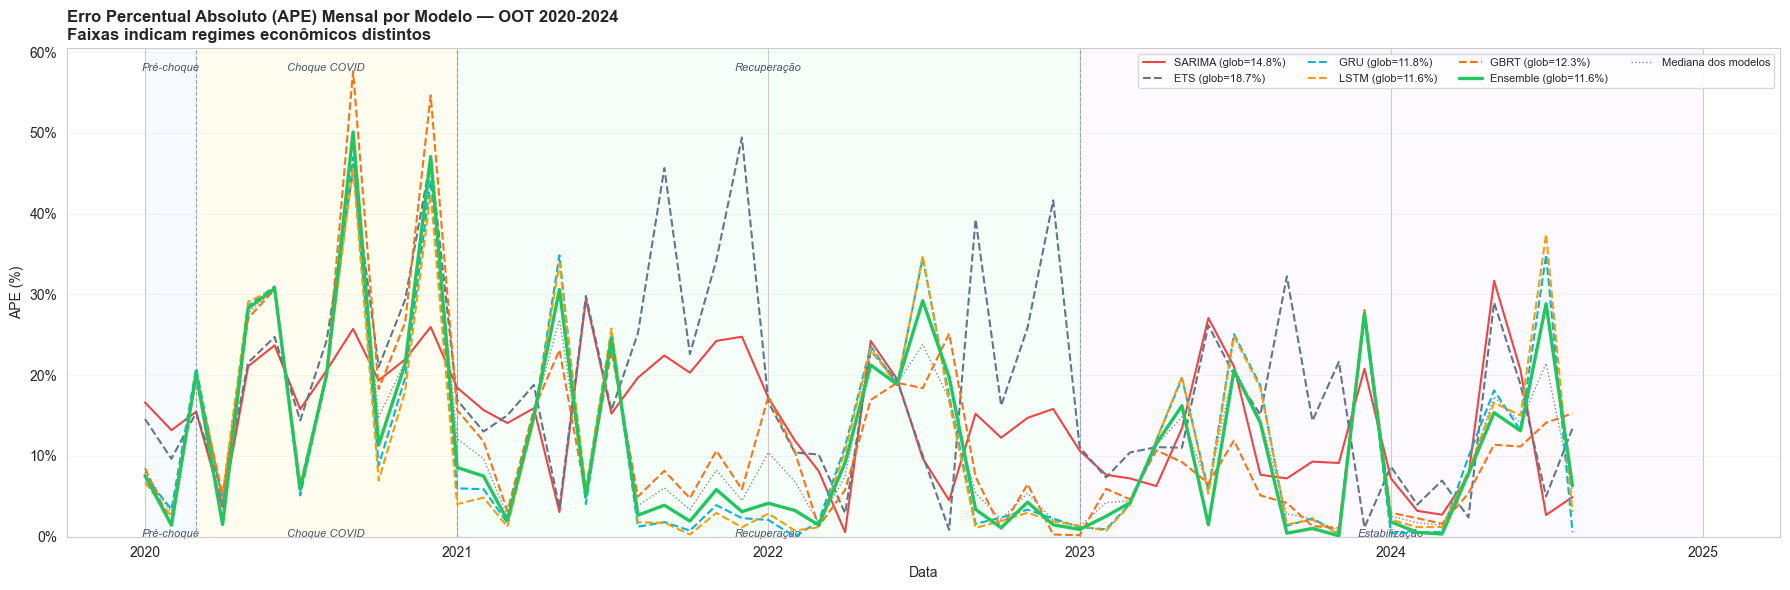

[SAVED] master_results/subperiod_ape_series.png


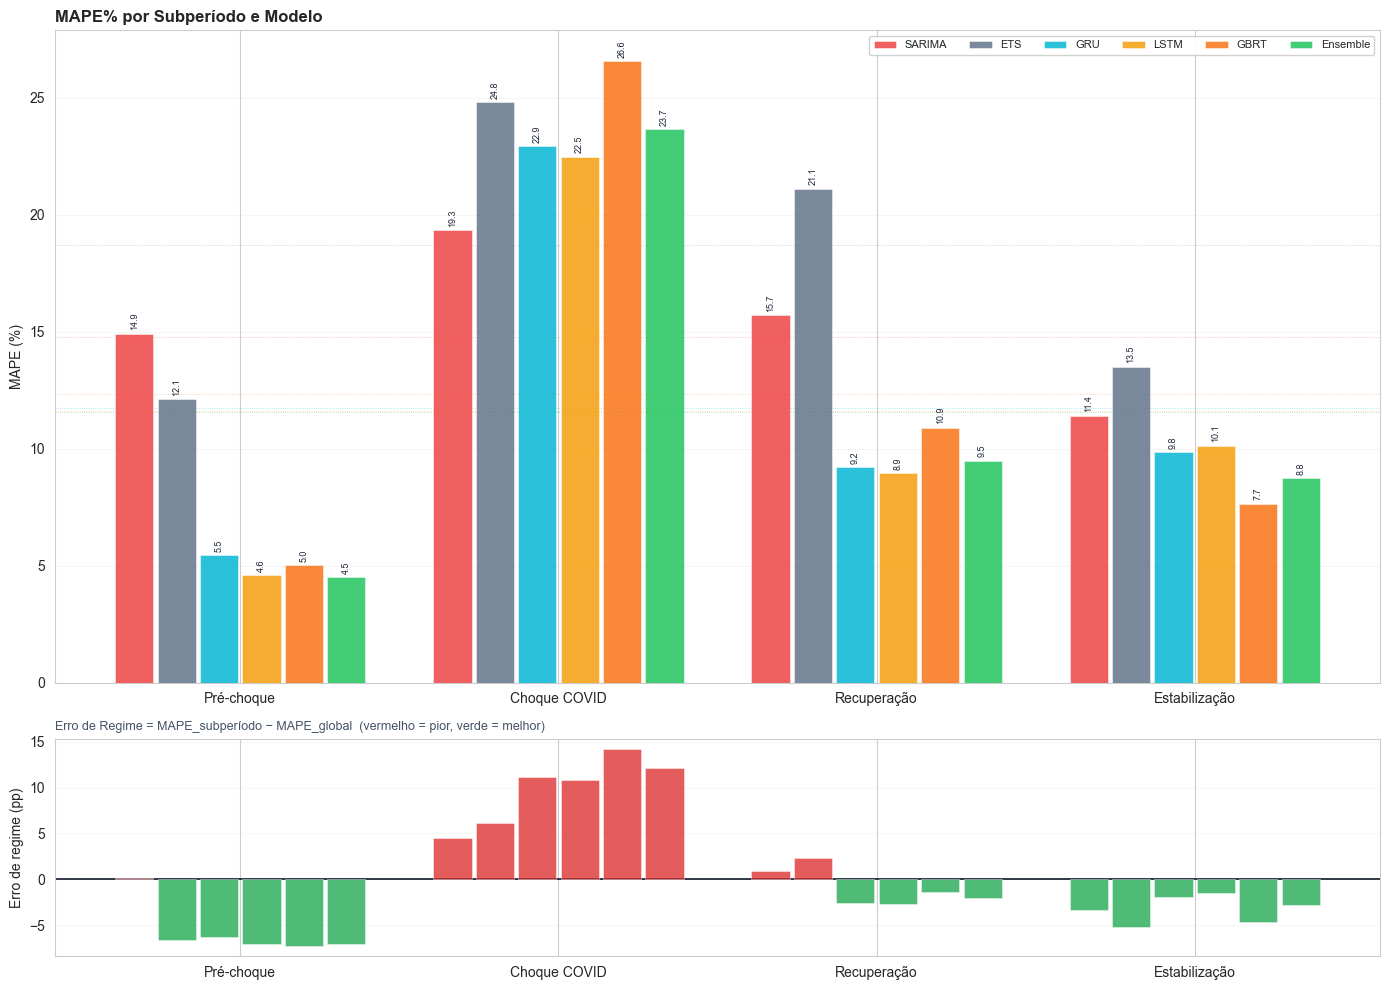

[SAVED] master_results/subperiod_barras.png


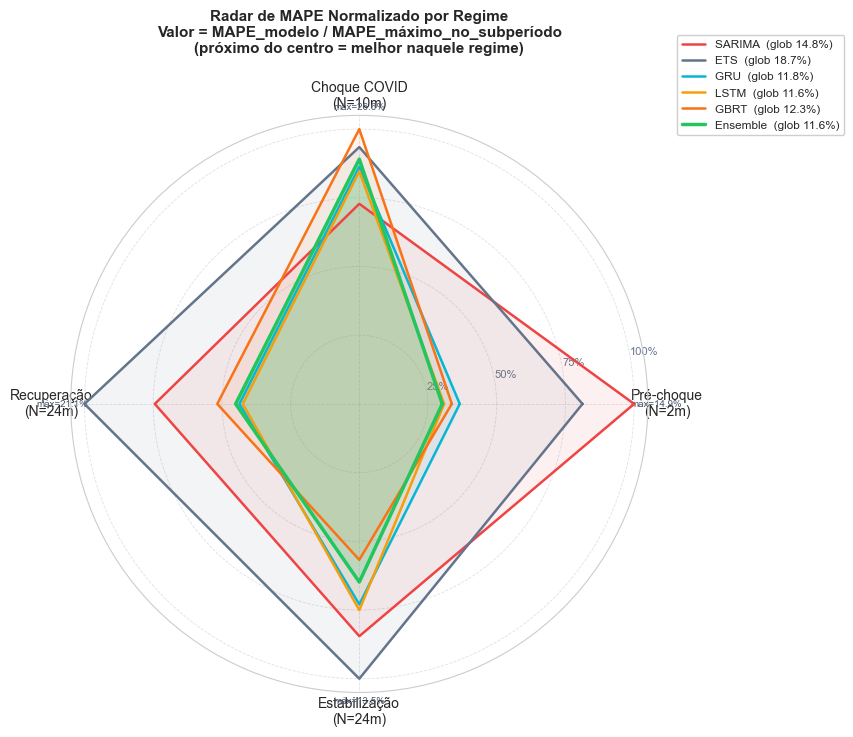

[SAVED] master_results/subperiod_radar.png

══════════════════════════════════════════════════════════════════════
  SUMÁRIO INTERPRETATIVO
══════════════════════════════════════════════════════════════════════

  [Pré-choque]
    Melhor:  Ensemble     MAPE=4.50%  Regime=-7.1pp
    Pior:    SARIMA       MAPE=14.91%  Regime=+0.1pp

  [Choque COVID]
    Melhor:  SARIMA       MAPE=19.34%  Regime=+4.5pp
    Pior:    GBRT         MAPE=26.56%  Regime=+14.2pp
    Maior degradação: GBRT (+14.2pp acima do global)

  [Recuperação]
    Melhor:  LSTM         MAPE=8.95%  Regime=-2.7pp
    Pior:    ETS          MAPE=21.11%  Regime=+2.4pp
    Maior degradação: ETS (+2.4pp acima do global)

  [Estabilização]
    Melhor:  GBRT         MAPE=7.66%  Regime=-4.7pp
    Pior:    ETS          MAPE=13.50%  Regime=-5.2pp

[OK] Análise por subperíodo concluída.
     3 gráficos + 2 CSVs salvos em master_results/


In [57]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  ANÁLISE DE ERRO POR SUBPERÍODO — Regimes Econômicos 2020-2024      ║
# ╚══════════════════════════════════════════════════════════════════════╝

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

os.makedirs("master_results", exist_ok=True)

# ══════════════════════════════════════════════════════════════════════
# CONFIGURAÇÕES GLOBAIS
# ══════════════════════════════════════════════════════════════════════

# Paleta consistente com o notebook (Cell 17)
MODEL_COLORS = {
    "GRU":      "#06b6d4",
    "LSTM":     "#f59e0b",
    "GBRT":     "#f97316",
    "Ensemble": "#22c55e",
    "TFT":      "#8b5cf6",
    "SARIMA":   "#ef4444",
    "ETS":      "#64748b",
}
MODEL_ORDER = ["SARIMA", "ETS", "GRU", "LSTM", "GBRT", "TFT", "Ensemble"]

# Definição dos subperíodos
SUBPERIODS = [
    {"label": "Pré-choque",    "start": "2020-01", "end": "2020-02",
     "shade": "#bfdbfe", "months": 2},
    {"label": "Choque COVID",  "start": "2020-03", "end": "2020-12",
     "shade": "#fef08a", "months": 10},
    {"label": "Recuperação",   "start": "2021-01", "end": "2022-12",
     "shade": "#bbf7d0", "months": 24},
    {"label": "Estabilização", "start": "2023-01", "end": "2024-12",
     "shade": "#e9d5ff", "months": 24},
]
SP_LABELS = [sp["label"] for sp in SUBPERIODS]


# ══════════════════════════════════════════════════════════════════════
# 1. COLETA E ALINHAMENTO DAS PREVISÕES OOT
# ══════════════════════════════════════════════════════════════════════

def _collect_oot_predictions() -> pd.DataFrame:
    """
    Agrega previsões OOT de todos os pipelines em um único DataFrame
    alinhado por data. Usa globals().get() para resiliência.

    Colunas: data, real, [GRU, LSTM, GBRT, Ensemble], [TFT], [SARIMA, ETS]
    """
    _pa = globals().get("pipeline_a_results") or {}
    _pb = globals().get("pipeline_b_results") or {}
    _pc = globals().get("pipeline_c_results") or {}
    frames = []

    # Pipeline A — usa o best_mode
    if _pa and _pa.get("best_mode") and "mode_results" in _pa:
        bm       = _pa["best_mode"]
        df_oot_a = _pa["mode_results"][bm].get("df_oot", pd.DataFrame())
        if len(df_oot_a) > 0:
            tmp = df_oot_a[["data", "real"]].copy()
            tmp["data"] = pd.to_datetime(tmp["data"])
            for src, dst in [("pred_GRU",      "GRU"),
                              ("pred_LSTM",     "LSTM"),
                              ("pred_GBRT",     "GBRT"),
                              ("pred_Ensemble", "Ensemble")]:
                if src in df_oot_a.columns:
                    tmp[dst] = df_oot_a[src].values
            frames.append(tmp)

    # Pipeline B — TFT
    if _pb:
        df_oot_b = _pb.get("df_oot", pd.DataFrame())
        if len(df_oot_b) > 0 and "pred_TFT" in df_oot_b.columns:
            tmp = df_oot_b[["data", "real"]].copy()
            tmp["data"] = pd.to_datetime(tmp["data"])
            tmp["TFT"]  = df_oot_b["pred_TFT"].values
            frames.append(tmp)

    # Pipeline C — SARIMA + ETS
    if _pc and _pc.get("results"):
        for mname in ("SARIMA", "ETS"):
            r = _pc["results"].get(mname)
            if r is None:
                continue
            tmp = pd.DataFrame({
                "data":  pd.to_datetime(r["dates_oot"]),
                "real":  np.asarray(r["real_oot"],  dtype=np.float64),
                mname:   np.asarray(r["pred_oot"],  dtype=np.float64),
            })
            frames.append(tmp)

    if not frames:
        return pd.DataFrame()

    merged = frames[0].copy()
    for nxt in frames[1:]:
        extra = [c for c in nxt.columns if c not in ("data", "real")]
        merged = merged.merge(nxt[["data"] + extra], on="data", how="inner")
    return merged.sort_values("data").reset_index(drop=True)


# ══════════════════════════════════════════════════════════════════════
# 2. FUNÇÃO PRINCIPAL: analyze_subperiods()
# ══════════════════════════════════════════════════════════════════════

def analyze_subperiods(df_aligned: pd.DataFrame) -> dict:
    """
    Calcula MAPE%, MAE (R$), viés% e erro de regime para cada modelo
    e cada subperíodo.

    Parameters
    ----------
    df_aligned : DataFrame com colunas 'data' (datetime), 'real' e uma
                 coluna por modelo com as previsões OOT.

    Returns
    -------
    dict com:
        'long'          — DataFrame formato longo (modelo × subperíodo)
        'pivot_mape'    — pivot: linhas=modelo, colunas=subperíodo + Global
        'pivot_bias'    — mesmo formato para viés%
        'pivot_regime'  — pivot do erro de regime (pp vs global)
        'global_mape'   — {modelo: MAPE_global_%}
        'ape_monthly'   — {modelo: array APE mensal alinhado com df_aligned}
        'models'        — lista de modelos disponíveis
    """
    df   = df_aligned.copy()
    df["data"] = pd.to_datetime(df["data"])
    mods = [c for c in df.columns if c not in ("data", "real")]

    # ── MAPE global (período OOT completo) ───────────────────────────
    global_mape = {}
    ape_monthly  = {}
    rl_all = df["real"].values.astype(np.float64)

    for m in mods:
        pred = df[m].values.astype(np.float64)
        ok   = np.isfinite(pred) & np.isfinite(rl_all) & (rl_all != 0)
        ape_arr = np.where(ok, np.abs((rl_all - pred) / rl_all) * 100, np.nan)
        ape_monthly[m]  = ape_arr
        global_mape[m]  = float(np.nanmean(ape_arr))

    # ── Métricas por subperíodo ──────────────────────────────────────
    long_rows = []
    for sp in SUBPERIODS:
        t0 = pd.Timestamp(f"{sp['start']}-01")
        t1 = (pd.Timestamp(f"{sp['end']}-01")
               + pd.offsets.MonthEnd(0))
        mask_sp = (df["data"] >= t0) & (df["data"] <= t1)
        df_sp   = df[mask_sp]
        rl_sp   = df_sp["real"].values.astype(np.float64)

        for m in mods:
            pred_sp = df_sp[m].values.astype(np.float64)
            ok_sp   = (np.isfinite(pred_sp) & np.isfinite(rl_sp)
                       & (rl_sp != 0))
            n       = int(ok_sp.sum())

            if n == 0:
                mape = mae = bias = regime_err = np.nan
                direction = "N/A"
            else:
                err  = rl_sp[ok_sp] - pred_sp[ok_sp]
                ape  = np.abs(err / rl_sp[ok_sp]) * 100
                mape = float(np.mean(ape))
                mae  = float(np.mean(np.abs(err)))
                bias = float(np.mean(
                    (pred_sp[ok_sp] - rl_sp[ok_sp]) / rl_sp[ok_sp]
                ) * 100)
                regime_err = mape - global_mape.get(m, np.nan)
                direction  = ("superestima" if bias >  0.5 else
                              "subestima"   if bias < -0.5 else
                              "neutro")

            long_rows.append({
                "Modelo":          m,
                "Subperíodo":      sp["label"],
                "N_meses":         n,
                "MAPE_%":          round(mape, 2) if np.isfinite(mape) else np.nan,
                "MAE_bi":          round(mae / 1e9, 3) if np.isfinite(mae) else np.nan,
                "Vies_%":          round(bias, 2) if np.isfinite(bias) else np.nan,
                "Direcao":         direction,
                "Erro_regime_pp":  round(regime_err, 2) if np.isfinite(regime_err) else np.nan,
            })

    df_long = pd.DataFrame(long_rows)

    # ── Pivot tables ─────────────────────────────────────────────────
    mod_order_avail = [m for m in MODEL_ORDER if m in mods] + \
                      [m for m in mods if m not in MODEL_ORDER]

    def _pivot(value_col):
        piv = df_long.pivot_table(
            index="Modelo", columns="Subperíodo",
            values=value_col, aggfunc="first",
        )
        piv = piv[[sp for sp in SP_LABELS if sp in piv.columns]]
        piv = piv.reindex([m for m in mod_order_avail if m in piv.index])
        return piv.round(2)

    pivot_mape   = _pivot("MAPE_%")
    pivot_bias   = _pivot("Vies_%")
    pivot_regime = _pivot("Erro_regime_pp")

    # Add global column
    pivot_mape["Global OOT"] = [
        round(global_mape.get(m, np.nan), 2) for m in pivot_mape.index
    ]

    return {
        "long":         df_long,
        "pivot_mape":   pivot_mape,
        "pivot_bias":   pivot_bias,
        "pivot_regime": pivot_regime,
        "global_mape":  global_mape,
        "ape_monthly":  ape_monthly,
        "models":       mods,
    }


# ── Executar ──────────────────────────────────────────────────────────

print(f"\n{'═'*70}")
print(f"  ANÁLISE POR SUBPERÍODO — Regimes Econômicos 2020-2024")
print(f"{'═'*70}")

df_oot = _collect_oot_predictions()

if len(df_oot) == 0:
    print("\n[SKIP] Nenhuma previsão OOT disponível. Execute os pipelines primeiro.")
else:
    analysis = analyze_subperiods(df_oot)
    models_avail = analysis["models"]

    print(f"\n  Observações OOT: {len(df_oot)}")
    print(f"  Modelos: {', '.join(models_avail)}")

    # ══════════════════════════════════════════════════════════════════
    # 3. TABELA PIVOT — MAPE% por modelo × subperíodo
    # ══════════════════════════════════════════════════════════════════

    piv = analysis["pivot_mape"]
    prg = analysis["pivot_regime"]

    print(f"\n{'─'*80}")
    print(f"  TABELA PIVOT — MAPE% (↓ melhor)")
    print(f"  Erro de regime em parênteses (pp vs MAPE global): + pior, − melhor")
    print(f"{'─'*80}")

    # Cabeçalho
    sp_cols   = [sp for sp in SP_LABELS if sp in piv.columns]
    col_widths = {c: max(len(c), 7) for c in sp_cols + ["Global OOT"]}
    header = f"  {'Modelo':<12}" + "".join(f"  {c:>{col_widths[c]}}" for c in sp_cols) + \
             f"  {'Global OOT':>10}"
    print(header)
    print(f"  {'─'*12}" + "".join(f"  {'─'*col_widths[c]}" for c in sp_cols) + "  ─────────")

    for model in piv.index:
        row_str = f"  {model:<12}"
        for sp_col in sp_cols:
            mape_v   = piv.loc[model, sp_col]   if sp_col in piv.columns   else np.nan
            regime_v = prg.loc[model, sp_col]   if sp_col in prg.columns   else np.nan
            if np.isnan(mape_v):
                cell = "N/A"
            else:
                sign = "+" if (np.isfinite(regime_v) and regime_v > 0) else ""
                reg_str = f"({sign}{regime_v:.1f})" if np.isfinite(regime_v) else ""
                cell = f"{mape_v:.1f}% {reg_str}"
            row_str += f"  {cell:>{col_widths[sp_col]}}"
        glob_v = piv.loc[model, "Global OOT"] if "Global OOT" in piv.columns else np.nan
        row_str += f"  {glob_v:.2f}%" if np.isfinite(glob_v) else "  N/A"
        print(row_str)

    print(f"{'─'*80}")

    # Print detalhado por subperíodo
    df_long = analysis["long"]
    print(f"\n{'─'*80}")
    print(f"  DETALHAMENTO POR SUBPERÍODO")
    print(f"{'─'*80}")
    for sp_label in SP_LABELS:
        df_sp = df_long[df_long["Subperíodo"] == sp_label].copy()
        if len(df_sp) == 0:
            continue
        df_sp = df_sp.sort_values("MAPE_%")
        n_meses = df_sp["N_meses"].iloc[0] if len(df_sp) > 0 else 0
        print(f"\n  [{sp_label}]  ({n_meses} meses)")
        print(f"  {'Modelo':<12}  {'MAPE%':>7}  {'MAE(R$Bi)':>10}  "
              f"{'Viés%':>7}  {'Direção':<12}  {'Regime(pp)':>10}")
        for _, row in df_sp.iterrows():
            mape = f"{row['MAPE_%']:.2f}%" if pd.notna(row['MAPE_%']) else "N/A"
            mae  = f"{row['MAE_bi']:.3f}"  if pd.notna(row['MAE_bi']) else "N/A"
            bias = f"{row['Vies_%']:+.1f}%"if pd.notna(row['Vies_%']) else "N/A"
            reg  = (f"{row['Erro_regime_pp']:+.2f}" if pd.notna(row['Erro_regime_pp']) else "N/A")
            print(f"  {row['Modelo']:<12}  {mape:>7}  {mae:>10}  "
                  f"  {bias:>7}  {row['Direcao']:<12}  {reg:>10}")

    # Exportar
    df_long.to_csv("master_results/subperiod_analysis.csv", index=False, encoding="utf-8")
    piv.to_csv("master_results/subperiod_pivot_mape.csv", encoding="utf-8")
    print(f"\n[SAVED] master_results/subperiod_analysis.csv")
    print(f"[SAVED] master_results/subperiod_pivot_mape.csv")

    # ══════════════════════════════════════════════════════════════════
    # 4. GRÁFICO 1 — Série temporal de erro percentual absoluto (APE)
    # ══════════════════════════════════════════════════════════════════

    ape_mon   = analysis["ape_monthly"]
    dates_arr = pd.to_datetime(df_oot["data"].values)

    fig1, ax1 = plt.subplots(figsize=(18, 6))

    # Faixas de subperíodo
    for sp in SUBPERIODS:
        t0 = pd.Timestamp(f"{sp['start']}-01")
        t1 = pd.Timestamp(f"{sp['end']}-01") + pd.offsets.MonthEnd(0)
        ax1.axvspan(t0, t1, alpha=0.12, color=sp["shade"], zorder=0)
        mid_t = t0 + (t1 - t0) / 2
        ax1.text(mid_t, ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0 else 30,
                 sp["label"], ha="center", va="top", fontsize=8,
                 color="#475569", style="italic", zorder=1)

    # Linhas de APE por modelo
    mod_plot_order = [m for m in MODEL_ORDER if m in ape_mon]
    for m in mod_plot_order:
        ape_arr = ape_mon[m]
        col     = MODEL_COLORS.get(m, "#94a3b8")
        lw      = 2.4 if m == "Ensemble" else 1.5
        ls      = "-"  if m in ("Ensemble", "SARIMA") else "--"
        ax1.plot(dates_arr, ape_arr, color=col, lw=lw, ls=ls,
                 label=f"{m} (glob={analysis['global_mape'].get(m, np.nan):.1f}%)",
                 zorder=3)

    # Mediana geral
    all_ape = np.nanmedian(
        np.stack([ape_mon[m] for m in mod_plot_order], axis=1), axis=1
    )
    ax1.plot(dates_arr, all_ape, color="#0f172a", lw=1.0, ls=":",
             alpha=0.5, label="Mediana dos modelos", zorder=2)

    # Linhas divisórias dos subperíodos
    for sp in SUBPERIODS[1:]:
        t0 = pd.Timestamp(f"{sp['start']}-01")
        ax1.axvline(t0, color="#94a3b8", lw=0.8, ls="--", zorder=1)

    ax1.set_title(
        "Erro Percentual Absoluto (APE) Mensal por Modelo — OOT 2020-2024\n"
        "Faixas indicam regimes econômicos distintos",
        fontsize=12, fontweight="bold", loc="left",
    )
    ax1.set_ylabel("APE (%)", fontsize=10)
    ax1.set_xlabel("Data", fontsize=10)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax1.set_ylim(bottom=0)
    ax1.legend(fontsize=8, ncol=4, loc="upper right",
               framealpha=0.9, edgecolor="#d1d5db")
    ax1.grid(axis="y", alpha=0.18)

    # Adicionar labels de subperíodo APÓS definir ylim
    y_top = ax1.get_ylim()[1]
    for sp in SUBPERIODS:
        t0 = pd.Timestamp(f"{sp['start']}-01")
        t1 = pd.Timestamp(f"{sp['end']}-01") + pd.offsets.MonthEnd(0)
        mid_t = t0 + (t1 - t0) / 2
        ax1.text(mid_t, y_top * 0.97, sp["label"],
                 ha="center", va="top", fontsize=8,
                 color="#475569", style="italic", zorder=5)

    plt.tight_layout()
    fig1.savefig("master_results/subperiod_ape_series.png", dpi=150,
                 bbox_inches="tight")
    plt.show()
    print("[SAVED] master_results/subperiod_ape_series.png")

    # ══════════════════════════════════════════════════════════════════
    # 5. GRÁFICO 2 — Barras agrupadas: MAPE% por subperíodo × modelo
    # ══════════════════════════════════════════════════════════════════

    mod_plot   = [m for m in MODEL_ORDER if m in models_avail]
    n_mods     = len(mod_plot)
    n_sp       = len(SUBPERIODS)
    bar_width  = 0.8 / n_mods
    x_centers  = np.arange(n_sp)

    fig2, (ax2a, ax2b) = plt.subplots(2, 1, figsize=(14, 10),
                                       gridspec_kw={"height_ratios": [3, 1]})

    # Painel superior: MAPE% absoluto
    for k, m in enumerate(mod_plot):
        offsets  = x_centers + (k - n_mods / 2 + 0.5) * bar_width
        mape_vals = []
        for sp_label in SP_LABELS:
            row = df_long[(df_long["Modelo"] == m) &
                          (df_long["Subperíodo"] == sp_label)]
            mape_vals.append(float(row["MAPE_%"].values[0])
                             if len(row) > 0 and pd.notna(row["MAPE_%"].values[0])
                             else np.nan)
        col  = MODEL_COLORS.get(m, "#94a3b8")
        bars = ax2a.bar(offsets, mape_vals, width=bar_width * 0.9,
                        color=col, alpha=0.85, label=m, zorder=3,
                        edgecolor="white", linewidth=0.4)
        # Rótulo no topo de cada barra
        for bar, v in zip(bars, mape_vals):
            if np.isfinite(v):
                ax2a.text(bar.get_x() + bar.get_width() / 2,
                          bar.get_height() + 0.15,
                          f"{v:.1f}", ha="center", va="bottom",
                          fontsize=6.5, color="#1e293b", rotation=90)

    ax2a.set_xticks(x_centers)
    ax2a.set_xticklabels(SP_LABELS, fontsize=10)
    ax2a.set_ylabel("MAPE (%)", fontsize=10)
    ax2a.set_title("MAPE% por Subperíodo e Modelo",
                   fontsize=12, fontweight="bold", loc="left")
    ax2a.legend(fontsize=8, ncol=n_mods, loc="upper right",
                framealpha=0.9)
    ax2a.grid(axis="y", alpha=0.18)
    ax2a.set_ylim(bottom=0)

    # Linhas de MAPE global por modelo
    for m in mod_plot:
        g_mape = analysis["global_mape"].get(m, np.nan)
        if np.isfinite(g_mape):
            ax2a.axhline(g_mape, color=MODEL_COLORS.get(m, "#94a3b8"),
                         lw=0.6, ls=":", alpha=0.4)

    # Painel inferior: erro de regime (pp)
    for k, m in enumerate(mod_plot):
        offsets = x_centers + (k - n_mods / 2 + 0.5) * bar_width
        reg_vals = []
        for sp_label in SP_LABELS:
            row = df_long[(df_long["Modelo"] == m) &
                          (df_long["Subperíodo"] == sp_label)]
            reg_vals.append(float(row["Erro_regime_pp"].values[0])
                            if len(row) > 0 and pd.notna(row["Erro_regime_pp"].values[0])
                            else np.nan)
        col  = MODEL_COLORS.get(m, "#94a3b8")
        col_bars = [("#dc2626" if v > 0 else "#16a34a") if np.isfinite(v)
                    else "#94a3b8" for v in reg_vals]
        ax2b.bar(offsets, reg_vals, width=bar_width * 0.9,
                 color=col_bars, alpha=0.75, edgecolor="white",
                 linewidth=0.4, zorder=3)

    ax2b.axhline(0, color="#0f172a", lw=1.2)
    ax2b.set_xticks(x_centers)
    ax2b.set_xticklabels(SP_LABELS, fontsize=10)
    ax2b.set_ylabel("Erro de regime (pp)", fontsize=10)
    ax2b.set_title("Erro de Regime = MAPE_subperíodo − MAPE_global  "
                   "(vermelho = pior, verde = melhor)",
                   fontsize=9, loc="left", color="#475569")
    ax2b.grid(axis="y", alpha=0.15)

    plt.tight_layout()
    fig2.savefig("master_results/subperiod_barras.png", dpi=150,
                 bbox_inches="tight")
    plt.show()
    print("[SAVED] master_results/subperiod_barras.png")

    # ══════════════════════════════════════════════════════════════════
    # 6. GRÁFICO 3 — Radar/Spider: MAPE normalizado por subperíodo
    # ══════════════════════════════════════════════════════════════════
    #
    # Cada eixo = um subperíodo.
    # Valor em cada eixo = MAPE_modelo / MAPE_max_modelos no subperíodo
    # → modelo ideal = (0, 0, 0, 0) no centro
    # → pior modelo em cada eixo = 1.0

    n_sp    = len(SUBPERIODS)
    angles  = np.linspace(0, 2 * np.pi, n_sp, endpoint=False).tolist()
    angles += angles[:1]  # fechar o polígono

    fig3, ax3 = plt.subplots(figsize=(9, 9),
                              subplot_kw=dict(polar=True))

    # Coletar MAPE normalizado por subperíodo
    sp_max = {}
    for sp_label in SP_LABELS:
        vals = []
        for m in mod_plot:
            row = df_long[(df_long["Modelo"] == m) &
                          (df_long["Subperíodo"] == sp_label)]
            v = float(row["MAPE_%"].values[0]) if (
                len(row) > 0 and pd.notna(row["MAPE_%"].values[0])
            ) else np.nan
            vals.append(v)
        sp_max[sp_label] = max((v for v in vals if np.isfinite(v)), default=1.0)

    for m in mod_plot:
        norm_vals = []
        for sp_label in SP_LABELS:
            row = df_long[(df_long["Modelo"] == m) &
                          (df_long["Subperíodo"] == sp_label)]
            v = float(row["MAPE_%"].values[0]) if (
                len(row) > 0 and pd.notna(row["MAPE_%"].values[0])
            ) else np.nan
            norm = v / sp_max[sp_label] if np.isfinite(v) and sp_max[sp_label] > 0 else np.nan
            norm_vals.append(norm if np.isfinite(norm) else 0.0)
        norm_vals += norm_vals[:1]  # fechar
        col   = MODEL_COLORS.get(m, "#94a3b8")
        lw    = 2.5 if m == "Ensemble" else 1.8
        alpha = 0.18 if m == "Ensemble" else 0.08
        g_mape = analysis["global_mape"].get(m, np.nan)
        label  = f"{m}  (glob {g_mape:.1f}%)" if np.isfinite(g_mape) else m
        ax3.plot(angles, norm_vals, color=col, lw=lw, label=label, zorder=4)
        ax3.fill(angles, norm_vals, color=col, alpha=alpha)

    # Eixos e rótulos
    ax3.set_xticks(angles[:-1])
    ax3.set_xticklabels(
        [f"{sp['label']}\n(N={sp['months']}m)" for sp in SUBPERIODS],
        fontsize=10,
    )
    ax3.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax3.set_yticklabels(["25%", "50%", "75%", "100%"],
                         fontsize=8, color="#64748b")
    ax3.set_ylim(0, 1.05)
    ax3.set_rlabel_position(10)
    ax3.grid(color="#d1d5db", linestyle="--", linewidth=0.6, alpha=0.7)

    # Adicionar MAPE máximo de referência por eixo
    for ang, sp_label in zip(angles[:-1], SP_LABELS):
        ax3.text(ang, 1.08,
                 f"máx={sp_max[sp_label]:.1f}%",
                 ha="center", va="center",
                 fontsize=7, color="#475569")

    ax3.set_title(
        "Radar de MAPE Normalizado por Regime\n"
        "Valor = MAPE_modelo / MAPE_máximo_no_subperíodo\n"
        "(próximo do centro = melhor naquele regime)",
        fontsize=11, fontweight="bold", pad=20,
    )
    ax3.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15),
               fontsize=8.5, framealpha=0.95)

    plt.tight_layout()
    fig3.savefig("master_results/subperiod_radar.png", dpi=150,
                 bbox_inches="tight")
    plt.show()
    print("[SAVED] master_results/subperiod_radar.png")

    # ══════════════════════════════════════════════════════════════════
    # 7. SUMÁRIO INTERPRETATIVO
    # ══════════════════════════════════════════════════════════════════

    print(f"\n{'═'*70}")
    print(f"  SUMÁRIO INTERPRETATIVO")
    print(f"{'═'*70}")
    for sp_label in SP_LABELS:
        df_sp = df_long[df_long["Subperíodo"] == sp_label].dropna(subset=["MAPE_%"])
        if len(df_sp) == 0:
            continue
        best_row  = df_sp.loc[df_sp["MAPE_%"].idxmin()]
        worst_row = df_sp.loc[df_sp["MAPE_%"].idxmax()]
        print(f"\n  [{sp_label}]")
        print(f"    Melhor:  {best_row['Modelo']:<12} "
              f"MAPE={best_row['MAPE_%']:.2f}%  "
              f"Regime={best_row['Erro_regime_pp']:+.1f}pp")
        print(f"    Pior:    {worst_row['Modelo']:<12} "
              f"MAPE={worst_row['MAPE_%']:.2f}%  "
              f"Regime={worst_row['Erro_regime_pp']:+.1f}pp")

        # Qual modelo tem pior degradação de regime (mais pp positivos)?
        models_degraded = df_sp[df_sp["Erro_regime_pp"] > 2].sort_values(
            "Erro_regime_pp", ascending=False
        )
        if len(models_degraded) > 0:
            worst_deg = models_degraded.iloc[0]
            print(f"    Maior degradação: {worst_deg['Modelo']} "
                  f"(+{worst_deg['Erro_regime_pp']:.1f}pp acima do global)")

    print(f"\n[OK] Análise por subperíodo concluída.")
    print(f"     3 gráficos + 2 CSVs salvos em master_results/")


### Quantificação de Incerteza — Bootstrap (Ensemble) e Quantis (TFT)

Substitui as bandas ad hoc por intervalos com interpretação estatística rigorosa.

- **Ensemble (Pipeline A):** Block bootstrap dos resíduos de teste (2017-2019), blocos de 3 meses.
- **TFT (Pipeline B):** Quantis nativos da QuantileLoss (q02/q10/q25/q50/q75/q90/q98), convertidos de log para R$.
- **Coverage rate:** % dos valores reais dentro das bandas — diagnóstico de calibração.



  Bootstrap Ensemble [sazonal_lag12]
  Resíduos de teste: 36 obs  σ=0M  bias=-0M
  1-step bootstrap OK  (B=1000, bloco=3, phi_AR(1) não aplicado)
  Multi-step bootstrap OK  (phi_hat=0.150)
[SKIP] pipeline_b_results indisponível.


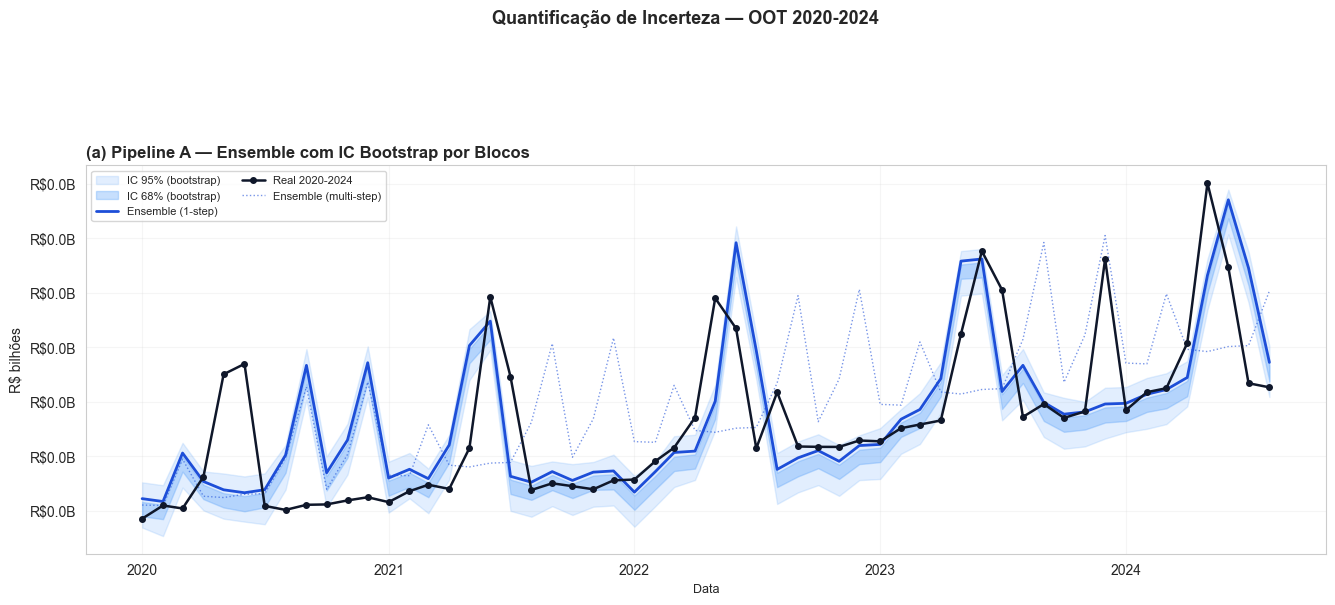


[SAVED] master_results/uncertainty_bands.png

════════════════════════════════════════════════════════════════════════════════
  TABELA DE COVERAGE RATE — Calibração dos Intervalos de Confiança
  Coverage ideal ≈ nominal. Desvio >8pp indica má calibração.
════════════════════════════════════════════════════════════════════════════════
             Modelo / Método  IC Nominal (%)  Coverage Real (%)  Desvio (pp)          Calibração
    Ensemble 1-step — IC 68%            68.0               21.4        -46.6 Subestima incerteza
    Ensemble 1-step — IC 95%            95.0               53.6        -41.4 Subestima incerteza
Ensemble multi-step — IC 68%            68.0               10.7        -57.3 Subestima incerteza
Ensemble multi-step — IC 95%            95.0               32.1        -62.9 Subestima incerteza
════════════════════════════════════════════════════════════════════════════════

  Interpretação:
    Coverage < nominal → IC estreito → modelo subestima incerteza
    Coverage

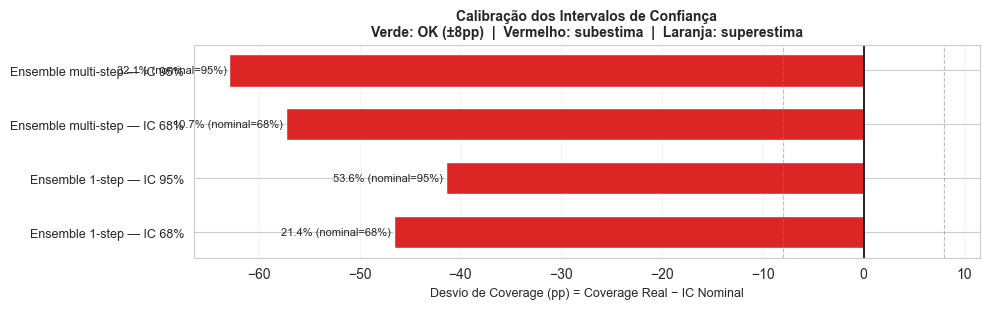

[SAVED] master_results/coverage_calibration.png

[OK] Quantificacao de incerteza concluida.


In [58]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  QUANTIFICAÇÃO DE INCERTEZA                                          ║
# ║  (A) Block Bootstrap — Ensemble   (B) Quantis Nativos — TFT         ║
# ╚══════════════════════════════════════════════════════════════════════╝

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ══════════════════════════════════════════════════════════════════════
# 1. BLOCK BOOTSTRAP CI — Ensemble (Pipeline A)
# ══════════════════════════════════════════════════════════════════════

def block_bootstrap_ci(
    residuals: np.ndarray,
    predictions_oot: np.ndarray,
    B: int = 1000,
    block_size: int = 3,
    quantiles: tuple = (0.025, 0.16, 0.84, 0.975),
    seed: int = 42,
) -> dict:
    """
    Block bootstrap confidence intervals for multi-step OOT predictions.

    INTUIÇÃO:
    Em vez de assumir uma distribuição paramétrica para os erros, reamostramos
    diretamente os resíduos empíricos do período de teste. Blocos de 3 meses
    preservam a autocorrelação serial presente em erros de previsão mensais.

    Parâmetros
    ----------
    residuals        : erros de 1-step do período de teste  (real − previsto).
    predictions_oot  : previsões pontuais do período OOT.
    B                : número de trajectórias bootstrap (recomendado ≥ 1000).
    block_size       : comprimento de cada bloco temporal (3 = trimestre).
    quantiles        : percentis a extrair  →  (2.5%, 16%, 84%, 97.5%).
    seed             : semente para reprodutibilidade.

    Retorna
    -------
    dict com arrays "q025", "q16", "q84", "q975" (mesmo comprimento que
    predictions_oot) e "boot_matrix" [B × N_OOT].
    """
    rng   = np.random.default_rng(seed)
    n_res = len(residuals)
    n_oot = len(predictions_oot)

    # Blocos sobrepostos maximizam o uso da amostra pequena de resíduos
    blocks     = [residuals[i: i + block_size]
                  for i in range(n_res - block_size + 1)]
    n_blk      = len(blocks)
    n_blk_need = int(np.ceil(n_oot / block_size))

    boot_matrix = np.empty((B, n_oot), dtype=np.float64)
    for b in range(B):
        idx      = rng.integers(0, n_blk, size=n_blk_need)
        boot_res = np.concatenate([blocks[k] for k in idx])[:n_oot]
        boot_matrix[b] = predictions_oot + boot_res

    pcts = np.array(quantiles) * 100
    q    = np.percentile(boot_matrix, pcts, axis=0)

    return {
        'q025':         q[0],
        'q16':          q[1],
        'q84':          q[2],
        'q975':         q[3],
        'boot_matrix':  boot_matrix,
    }


def propagated_block_bootstrap_ci(
    residuals: np.ndarray,
    predictions_ms: np.ndarray,
    B: int = 1000,
    block_size: int = 3,
    quantiles: tuple = (0.025, 0.16, 0.84, 0.975),
    seed: int = 42,
) -> dict:
    """
    Block bootstrap com propagação de incerteza cumulativa para previsões
    multi-step (variant b: sem dado real retroalimentado).

    MECÂNICA DE PROPAGAÇÃO:
    Para uma previsão de H passos à frente, o erro no passo t contamina
    todos os passos t+1,...,H (pois a previsão em t vira input de t+1).
    Modelamos isso via AR(1) empírico nos resíduos do período de teste:
        erro_acum[t] = boot_res[t] + phi_hat × erro_acum[t-1]
    onde phi_hat é estimado como a autocorrelação de lag-1 dos resíduos.
    """
    rng      = np.random.default_rng(seed)
    n_res    = len(residuals)
    n_oot    = len(predictions_ms)

    # Estima coeficiente AR(1) dos resíduos de teste
    if n_res >= 3:
        phi_hat = float(np.corrcoef(residuals[:-1], residuals[1:])[0, 1])
        phi_hat = float(np.clip(phi_hat, 0.0, 0.98))
    else:
        phi_hat = 0.0

    blocks     = [residuals[i: i + block_size]
                  for i in range(n_res - block_size + 1)]
    n_blk      = len(blocks)
    n_blk_need = int(np.ceil(n_oot / block_size))

    boot_matrix = np.empty((B, n_oot), dtype=np.float64)
    for b in range(B):
        idx      = rng.integers(0, n_blk, size=n_blk_need)
        boot_res = np.concatenate([blocks[k] for k in idx])[:n_oot]
        # Propagação AR(1): erro em t contamina t+1, t+2, ...
        acc = np.empty(n_oot)
        acc[0] = boot_res[0]
        for t in range(1, n_oot):
            acc[t] = boot_res[t] + phi_hat * acc[t - 1]
        boot_matrix[b] = predictions_ms + acc

    pcts = np.array(quantiles) * 100
    q    = np.percentile(boot_matrix, pcts, axis=0)

    return {
        'q025':         q[0],
        'q16':          q[1],
        'q84':          q[2],
        'q975':         q[3],
        'boot_matrix':  boot_matrix,
        'phi_hat':      phi_hat,
    }


# ── Executar bootstrap para o Ensemble ───────────────────────────────

_pa = globals().get('pipeline_a_results') or {}
_pb = globals().get('pipeline_b_results') or {}
df  = globals().get('df', pd.DataFrame())   # raw data

ensemble_ci_1s = {}   # 1-step bootstrap CI
ensemble_ci_ms = {}   # multi-step propagated bootstrap CI

if _pa and _pa.get('mode_results') and _pa.get('best_mode'):
    best_mode  = _pa['best_mode']
    mode_res   = _pa['mode_results'][best_mode]
    df_test_a  = mode_res.get('df_test', pd.DataFrame())
    df_oot_a   = mode_res.get('df_oot',  pd.DataFrame())

    if len(df_test_a) > 0 and len(df_oot_a) > 0:
        # ── Resíduos do período de teste ─────────────────────────────
        res_ens = (df_test_a['real'].values.astype(np.float64)
                   - df_test_a['pred_Ensemble'].values.astype(np.float64))
        mask_finite = np.isfinite(res_ens)
        res_ens = res_ens[mask_finite]

        print(f'\n  Bootstrap Ensemble [{best_mode}]')
        print(f'  Resíduos de teste: {len(res_ens)} obs  '
              f'σ={np.std(res_ens)/1e6:,.0f}M  '
              f'bias={np.mean(res_ens)/1e6:+,.0f}M')

        # ── 1-step CI (variant a) ─────────────────────────────────────
        if 'pred_Ensemble' in df_oot_a.columns:
            pred_1s = df_oot_a['pred_Ensemble'].values.astype(np.float64)
            real_1s = df_oot_a['real'].values.astype(np.float64)
            ensemble_ci_1s = block_bootstrap_ci(
                res_ens, pred_1s, B=1000, block_size=3, seed=42,
            )
            ensemble_ci_1s['dates']   = pd.to_datetime(df_oot_a['data'].values)
            ensemble_ci_1s['real']    = real_1s
            ensemble_ci_1s['pred']    = pred_1s
            print(f'  1-step bootstrap OK  '
                  f'(B=1000, bloco=3, phi_AR(1) não aplicado)')

        # ── Multi-step CI (variant b) com propagação AR(1) ───────────
        if 'pred_Ensemble_ms' in df_oot_a.columns:
            pred_ms = df_oot_a['pred_Ensemble_ms'].values.astype(np.float64)
            ensemble_ci_ms = propagated_block_bootstrap_ci(
                res_ens, pred_ms, B=1000, block_size=3, seed=42,
            )
            ensemble_ci_ms['dates'] = pd.to_datetime(df_oot_a['data'].values)
            ensemble_ci_ms['real']  = df_oot_a['real'].values.astype(np.float64)
            ensemble_ci_ms['pred']  = pred_ms
            print(f'  Multi-step bootstrap OK  '
                  f'(phi_hat={ensemble_ci_ms["phi_hat"]:.3f})')
    else:
        print('[SKIP] Ensemble: df_test ou df_oot vazio.')
else:
    print('[SKIP] pipeline_a_results indisponível.')


# ══════════════════════════════════════════════════════════════════════
# 2. QUANTIS NATIVOS DO TFT (Pipeline B)
# ══════════════════════════════════════════════════════════════════════
#
# QuantileLoss() padrão do pytorch_forecasting usa:
# idx  0     1     2     3(mid) 4     5     6
# q   0.02  0.10  0.25  0.50  0.75  0.90  0.98
#
# Banda 80%: q10 (baixo) / q90 (alto)
# Banda 96%: q02 (baixo) / q98 (alto)

TFT_QUANTILE_COLS = {
    'tft_q02': 0.02, 'tft_q10': 0.10, 'tft_q25': 0.25, 'tft_q50': 0.50,
    'tft_q75': 0.75, 'tft_q90': 0.90, 'tft_q98': 0.98,
}

tft_ci = {}
if _pb and len(_pb.get('df_oot', pd.DataFrame())) > 0:
    df_oot_b = _pb['df_oot']
    q_cols_present = [c for c in TFT_QUANTILE_COLS if c in df_oot_b.columns]

    if q_cols_present:
        tft_ci = {
            'dates':  pd.to_datetime(df_oot_b['data'].values),
            'real':   df_oot_b['real'].values.astype(np.float64),
            'pred':   df_oot_b['pred_TFT'].values.astype(np.float64),
        }
        for col in q_cols_present:
            tft_ci[col] = df_oot_b[col].values.astype(np.float64)
        print(f'\n  TFT quantis extraídos: {q_cols_present}')
    else:
        # Fallback: re-run OOT não possível sem reexecutar Cell 19.
        print('\n  [WARN] TFT: colunas de quantis ausentes em df_oot.')
        print('         Re-execute Cell 19 (run_tft_pipeline) para gerar tft_q02...q98.')
else:
    print('[SKIP] pipeline_b_results indisponível.')


# ══════════════════════════════════════════════════════════════════════
# 3. VISUALIZAÇÃO — 3 painéis verticais
# ══════════════════════════════════════════════════════════════════════

_BLUES  = {'dark': '#1d4ed8', 'mid': '#60a5fa', 'light': '#bfdbfe'}
_GREENS = {'dark': '#15803d', 'mid': '#4ade80', 'light': '#bbf7d0'}
_GRAY   = '#94a3b8'

def _fmt_billions(x, _):
    return f'R${x:.1f}B'

has_ens = bool(ensemble_ci_1s)
has_tft = bool(tft_ci) and 'tft_q02' in tft_ci

if has_ens or has_tft:
    n_panels = 2 + (1 if has_ens and has_tft else 0)
    fig = plt.figure(figsize=(16, 6 * n_panels))
    gs  = GridSpec(n_panels, 1, figure=fig, hspace=0.38)

    panel_idx = 0

    # ── Painel (a): Ensemble + bootstrap CI ──────────────────────────
    if has_ens:
        ax = fig.add_subplot(gs[panel_idx])
        panel_idx += 1

        ci  = ensemble_ci_1s
        dt  = ci['dates']
        rl  = ci['real']  / 1e9
        pr  = ci['pred']  / 1e9
        lo95 = ci['q025'] / 1e9
        hi95 = ci['q975'] / 1e9
        lo68 = ci['q16']  / 1e9
        hi68 = ci['q84']  / 1e9

        ax.fill_between(dt, lo95, hi95, alpha=0.18, color=_BLUES['mid'],
                         label='IC 95% (bootstrap)')
        ax.fill_between(dt, lo68, hi68, alpha=0.35, color=_BLUES['mid'],
                         label='IC 68% (bootstrap)')
        ax.plot(dt, pr, color=_BLUES['dark'], lw=2.0,
                 label='Ensemble (1-step)', zorder=4)
        ax.plot(dt, rl, 'o-', color='#0f172a', lw=1.8, ms=4,
                 label='Real 2020-2024', zorder=5)

        # Adicionar CI multi-step se disponível
        if ensemble_ci_ms:
            ci_ms = ensemble_ci_ms
            ax.plot(ci_ms['dates'], ci_ms['pred'] / 1e9,
                     color=_BLUES['dark'], lw=1.0, ls=':', alpha=0.6,
                     label='Ensemble (multi-step)')

        ax.set_title('(a) Pipeline A — Ensemble com IC Bootstrap por Blocos',
                      fontsize=12, fontweight='bold', loc='left')
        ax.set_ylabel('R$ bilhões', fontsize=10)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(_fmt_billions))
        ax.legend(fontsize=8, ncol=2, loc='upper left')
        ax.grid(True, alpha=0.18)

    # ── Painel (b): TFT + quantis ─────────────────────────────────────
    if has_tft:
        ax = fig.add_subplot(gs[panel_idx])
        panel_idx += 1

        ci  = tft_ci
        dt  = ci['dates']
        rl  = ci['real'] / 1e9
        pr  = ci['pred'] / 1e9

        q02 = ci.get('tft_q02', np.full_like(pr, np.nan)) / 1e9
        q10 = ci.get('tft_q10', np.full_like(pr, np.nan)) / 1e9
        q90 = ci.get('tft_q90', np.full_like(pr, np.nan)) / 1e9
        q98 = ci.get('tft_q98', np.full_like(pr, np.nan)) / 1e9
        q25 = ci.get('tft_q25', np.full_like(pr, np.nan)) / 1e9
        q75 = ci.get('tft_q75', np.full_like(pr, np.nan)) / 1e9

        ax.fill_between(dt, q02, q98, alpha=0.15, color=_GREENS['mid'],
                         label='IC 96% (q02-q98)')
        ax.fill_between(dt, q10, q90, alpha=0.25, color=_GREENS['mid'],
                         label='IC 80% (q10-q90)')
        ax.fill_between(dt, q25, q75, alpha=0.40, color=_GREENS['mid'],
                         label='IC 50% (q25-q75)')
        ax.plot(dt, pr, color=_GREENS['dark'], lw=2.0,
                 label='TFT mediana (q50)', zorder=4)
        ax.plot(dt, rl, 'o-', color='#0f172a', lw=1.8, ms=4,
                 label='Real 2020-2024', zorder=5)

        ax.set_title('(b) Pipeline B — TFT com Quantis Nativos (QuantileLoss)',
                      fontsize=12, fontweight='bold', loc='left')
        ax.set_ylabel('R$ bilhões', fontsize=10)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(_fmt_billions))
        ax.legend(fontsize=8, ncol=3, loc='upper left')
        ax.grid(True, alpha=0.18)

    # ── Painel (c): Sobreposição Ensemble vs TFT ──────────────────────
    if has_ens and has_tft:
        ax = fig.add_subplot(gs[panel_idx])
        panel_idx += 1

        ci_a = ensemble_ci_1s
        ci_b = tft_ci

        ax.fill_between(ci_a['dates'],
                         ci_a['q025'] / 1e9, ci_a['q975'] / 1e9,
                         alpha=0.15, color=_BLUES['mid'], label='Ensemble IC 95%')
        ax.fill_between(ci_b['dates'],
                         ci_b.get('tft_q02', np.nan * ci_b['pred']) / 1e9,
                         ci_b.get('tft_q98', np.nan * ci_b['pred']) / 1e9,
                         alpha=0.15, color=_GREENS['mid'], label='TFT IC 96%')

        ax.plot(ci_a['dates'], ci_a['pred'] / 1e9, color=_BLUES['dark'],
                 lw=2.0, label='Ensemble (1-step)', zorder=4)
        ax.plot(ci_b['dates'], ci_b['pred'] / 1e9, color=_GREENS['dark'],
                 lw=2.0, ls='--', label='TFT (q50)', zorder=4)
        ax.plot(ci_a['dates'], ci_a['real'] / 1e9, 'o-', color='#0f172a',
                 lw=1.8, ms=4, label='Real 2020-2024', zorder=5)

        ax.set_title('(c) Comparativo: Ensemble vs TFT com Bandas de Incerteza',
                      fontsize=12, fontweight='bold', loc='left')
        ax.set_ylabel('R$ bilhões', fontsize=10)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(_fmt_billions))
        ax.legend(fontsize=8, ncol=3, loc='upper left')
        ax.grid(True, alpha=0.18)

    for ax in fig.get_axes():
        ax.set_xlabel('Data', fontsize=9)

    plt.suptitle('Quantificação de Incerteza — OOT 2020-2024',
                  fontsize=13, fontweight='bold', y=1.01)

    os.makedirs('master_results', exist_ok=True)
    fig.savefig('master_results/uncertainty_bands.png', dpi=150,
                bbox_inches='tight')
    plt.show()
    print('\n[SAVED] master_results/uncertainty_bands.png')
else:
    print('[SKIP] Sem dados suficientes para visualização de IC.')


# ══════════════════════════════════════════════════════════════════════
# 4. TABELA DE COVERAGE RATE
# ══════════════════════════════════════════════════════════════════════
#
# Coverage rate: % dos valores reais dentro do IC.
# Interpretação:
#   ≈ 95% → modelo bem calibrado
#   < 95% → subestima incerteza (IC muito estreito)
#   > 95% → superestima incerteza (IC muito largo)

def coverage_rate(real: np.ndarray, lo: np.ndarray, hi: np.ndarray) -> float:
    """Retorna a fração de obs. reais dentro do intervalo [lo, hi]."""
    mask = np.isfinite(real) & np.isfinite(lo) & np.isfinite(hi)
    if mask.sum() == 0:
        return np.nan
    inside = (real[mask] >= lo[mask]) & (real[mask] <= hi[mask])
    return float(inside.mean()) * 100.0


cov_rows = []

if ensemble_ci_1s:
    rl = ensemble_ci_1s['real']
    for label, lo_key, hi_key, nominal in [
        ('Ensemble 1-step — IC 68%',  'q16',  'q84',  68.0),
        ('Ensemble 1-step — IC 95%',  'q025', 'q975', 95.0),
    ]:
        lo = ensemble_ci_1s[lo_key]
        hi = ensemble_ci_1s[hi_key]
        cov = coverage_rate(rl, lo, hi)
        diff = cov - nominal
        status = ('OK' if abs(diff) <= 8 else
                  'Subestima incerteza' if diff < 0 else 'Superestima incerteza')
        cov_rows.append({
            'Modelo / Método':  label,
            'IC Nominal (%)':   nominal,
            'Coverage Real (%)': round(cov, 1) if np.isfinite(cov) else np.nan,
            'Desvio (pp)':      round(diff, 1) if np.isfinite(cov) else np.nan,
            'Calibração':       status,
        })

if ensemble_ci_ms:
    rl = ensemble_ci_ms['real']
    for label, lo_key, hi_key, nominal in [
        ('Ensemble multi-step — IC 68%',  'q16',  'q84',  68.0),
        ('Ensemble multi-step — IC 95%',  'q025', 'q975', 95.0),
    ]:
        lo = ensemble_ci_ms[lo_key]
        hi = ensemble_ci_ms[hi_key]
        cov = coverage_rate(rl, lo, hi)
        diff = cov - nominal
        status = ('OK' if abs(diff) <= 8 else
                  'Subestima incerteza' if diff < 0 else 'Superestima incerteza')
        cov_rows.append({
            'Modelo / Método':  label,
            'IC Nominal (%)':   nominal,
            'Coverage Real (%)': round(cov, 1) if np.isfinite(cov) else np.nan,
            'Desvio (pp)':      round(diff, 1) if np.isfinite(cov) else np.nan,
            'Calibração':       status,
        })

if tft_ci and 'tft_q02' in tft_ci:
    rl = tft_ci['real']
    for label, lo_key, hi_key, nominal in [
        ('TFT — IC 50% (q25-q75)', 'tft_q25', 'tft_q75', 50.0),
        ('TFT — IC 80% (q10-q90)', 'tft_q10', 'tft_q90', 80.0),
        ('TFT — IC 96% (q02-q98)', 'tft_q02', 'tft_q98', 96.0),
    ]:
        if lo_key not in tft_ci or hi_key not in tft_ci:
            continue
        lo = tft_ci[lo_key]
        hi = tft_ci[hi_key]
        cov = coverage_rate(rl, lo, hi)
        diff = cov - nominal
        status = ('OK' if abs(diff) <= 8 else
                  'Subestima incerteza' if diff < 0 else 'Superestima incerteza')
        cov_rows.append({
            'Modelo / Método':  label,
            'IC Nominal (%)':   nominal,
            'Coverage Real (%)': round(cov, 1) if np.isfinite(cov) else np.nan,
            'Desvio (pp)':      round(diff, 1) if np.isfinite(cov) else np.nan,
            'Calibração':       status,
        })

if cov_rows:
    df_cov = pd.DataFrame(cov_rows)
    print(f"\n{'═'*80}")
    print(f"  TABELA DE COVERAGE RATE — Calibração dos Intervalos de Confiança")
    print(f"  Coverage ideal ≈ nominal. Desvio >8pp indica má calibração.")
    print(f"{'═'*80}")
    print(df_cov.to_string(index=False))
    print(f"{'═'*80}")
    print(f'\n  Interpretação:')
    print(f'    Coverage < nominal → IC estreito → modelo subestima incerteza')
    print(f'    Coverage > nominal → IC largo   → modelo superestima incerteza')

    os.makedirs('master_results', exist_ok=True)
    df_cov.to_excel('master_results/coverage_rate.xlsx', index=False)
    print(f'\n[SAVED] master_results/coverage_rate.xlsx')

    # ── Mini heatmap de calibração ────────────────────────────────────
    fig_cov, ax_cov = plt.subplots(figsize=(10, max(2.5, len(cov_rows) * 0.55 + 1)))

    desvios  = df_cov['Desvio (pp)'].fillna(0).values.astype(float)
    labels   = df_cov['Modelo / Método'].values
    nom_vals = df_cov['IC Nominal (%)'].values
    cov_vals = df_cov['Coverage Real (%)'].fillna(0).values.astype(float)

    colors = ['#15803d' if abs(d) <= 8 else ('#dc2626' if d < 0 else '#f59e0b')
              for d in desvios]
    bars = ax_cov.barh(range(len(labels)), desvios, color=colors, height=0.6)
    ax_cov.axvline(0, color='black', lw=1.2)
    ax_cov.axvline(-8, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax_cov.axvline(+8, color='gray', lw=0.8, ls='--', alpha=0.5)

    for i, (d, cv, nv) in enumerate(zip(desvios, cov_vals, nom_vals)):
        ax_cov.text(d + (0.3 if d >= 0 else -0.3), i,
                    f'{cv:.1f}% (nominal={nv:.0f}%)',
                    va='center', ha='left' if d >= 0 else 'right', fontsize=8)

    ax_cov.set_yticks(range(len(labels)))
    ax_cov.set_yticklabels(labels, fontsize=9)
    ax_cov.set_xlabel('Desvio de Coverage (pp) = Coverage Real − IC Nominal', fontsize=9)
    ax_cov.set_title('Calibração dos Intervalos de Confiança\n'
                      'Verde: OK (±8pp)  |  Vermelho: subestima  |  Laranja: superestima',
                      fontsize=10, fontweight='bold')
    ax_cov.grid(axis='x', alpha=0.2)

    plt.tight_layout()
    fig_cov.savefig('master_results/coverage_calibration.png', dpi=150,
                    bbox_inches='tight')
    plt.show()
    print(f'[SAVED] master_results/coverage_calibration.png')

else:
    print('[SKIP] Sem dados de coverage para tabular.')

print(f'\n[OK] Quantificacao de incerteza concluida.')


---
## Etapa 6

### Verificação de Integridade e Resumo da Sessão

> Valida se todos os arquivos de saída foram gerados em `master_results/`,
> exibe o tempo de execução de cada pipeline e as informações de hardware.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  VERIFICAÇÃO DE INTEGRIDADE E RESUMO DA SESSÃO                      ║
# ╚══════════════════════════════════════════════════════════════════════╝

import os, platform
import pandas as pd

os.makedirs("master_results", exist_ok=True)

# ── 1. Verificação de arquivos de saída esperados ─────────────────────
_OUTPUTS_ESPERADOS = {
    # Ablation Study
    "master_results/ablation_study.csv":           "Ablation — tabela de resultados",
    "master_results/ablation_heatmap_r2.png":      "Ablation — heatmap R²",
    "master_results/ablation_boxplot_mape.png":    "Ablation — boxplot MAPE%",
    "master_results/ablation_top_bottom5.png":     "Ablation — top/bottom 5",
    # Política Pública
    "master_results/pp_monetary_errors.csv":       "Política — erros monetários",
    "master_results/pp_subperiod_mape.csv":        "Política — MAPE por subperíodo",
    "master_results/pp_covid_impact.png":          "Política — impacto COVID",
    # Pipeline C
    "master_results/pipeline_c_baselines.xlsx":    "Pipeline C — baselines",
}

print("═" * 68)
print("  VERIFICAÇÃO DE INTEGRIDADE — ARQUIVOS DE SAÍDA")
print("═" * 68)
_n_ok = _n_fail = 0
for fpath, descricao in _OUTPUTS_ESPERADOS.items():
    existe = os.path.isfile(fpath)
    status = "✓ OK    " if existe else "✗ FALTA "
    tamanho = f"{os.path.getsize(fpath) / 1024:.1f} KB" if existe else "—"
    print(f"  {status}  {tamanho:>8}  {descricao}")
    if existe:
        _n_ok += 1
    else:
        _n_fail += 1

# Comparativo (nome dinâmico)
_comp_files = [f for f in os.listdir("master_results")
               if f.startswith("comparative_") and f.endswith(".xlsx")]
for cf in _comp_files:
    fpath = f"master_results/{cf}"
    tam   = f"{os.path.getsize(fpath) / 1024:.1f} KB"
    print(f"  ✓ OK       {tam:>8}  Análise comparativa — {cf}")
    _n_ok += 1

print("═" * 68)
print(f"  Resultado: {_n_ok} arquivo(s) presente(s), {_n_fail} ausente(s).")
if _n_fail == 0:
    print("  [OK] Todos os arquivos esperados foram gerados.")
else:
    print(f"  [AVISO] {_n_fail} arquivo(s) em falta — verifique se os pipelines "
          "correspondentes foram executados.")
print()

# ── 2. Tabela de tempos de execução ──────────────────────────────────
print("═" * 68)
print("  TEMPOS DE EXECUÇÃO POR PIPELINE")
print("═" * 68)
if not _EXECUTION_TIMES:
    print("  Nenhum tempo registrado — execute os pipelines para cronometrar.")
else:
    print(f"  {'Pipeline':<35} {'Tempo (s)':>10} {'Tempo (min)':>12}")
    print(f"  {'─'*35} {'─'*10} {'─'*12}")
    _total_s = 0.0
    for label, secs in _EXECUTION_TIMES.items():
        print(f"  {label:<35} {secs:>10.1f} {secs/60:>12.2f}")
        _total_s += secs
    print(f"  {'─'*35} {'─'*10} {'─'*12}")
    print(f"  {'TOTAL':<35} {_total_s:>10.1f} {_total_s/60:>12.2f}")
    # Exporta CSV de tempos
    _df_tempos = pd.DataFrame(
        [{"pipeline": k, "tempo_s": round(v, 1), "tempo_min": round(v / 60, 2)}
         for k, v in _EXECUTION_TIMES.items()]
    )
    _df_tempos.to_csv("master_results/execution_times.csv", index=False)
    print(f"\n  [SALVO] master_results/execution_times.csv")
print()

# ── 3. Informações de hardware ────────────────────────────────────────
print("═" * 68)
print("  AMBIENTE DE EXECUÇÃO")
print("═" * 68)
if "_HW_INFO" in globals():
    hw = _HW_INFO
    print(f"  Sistema      : {hw.get('sistema', 'N/D')}")
    print(f"  Processador  : {hw.get('processador', 'N/D')[:60]}")
    print(f"  RAM          : {hw.get('ram_gb', 'N/D')} GB")
    print(f"  GPU          : {hw.get('gpu', 'N/D')}")
    print(f"  Python       : {hw.get('python', 'N/D')}")
else:
    print(f"  Sistema      : {platform.system()}")
    print(f"  Python       : {platform.python_version()}")

try:
    import numpy as np, pandas as pd, sklearn
    import matplotlib
    print(f"  NumPy        : {np.__version__}")
    print(f"  Pandas       : {pd.__version__}")
    print(f"  scikit-learn : {sklearn.__version__}")
    print(f"  Matplotlib   : {matplotlib.__version__}")
except Exception:
    pass
print("═" * 68)
print(f"  Notebook concluído em: {__import__('datetime').datetime.now():%d/%m/%Y %H:%M:%S}")
print("═" * 68)
